# HistoRAG: Designing a Methodologically Informed Retrieval-Augmented Generation System for Historical Research — Demonstrated through a Case Study of Der Spiegel (1950–1979) and the Computerisation of the Early Federal Republic

 ### Noah J. Kim-Baumann [![orcid](./media/image.png)](https://orcid.org/0009-0004-6368-3061) 
Humboldt-Universität zu Berlin

### Torsten Hiltmann [![orcid](./media/image.png)](https://orcid.org/0000-0002-6757-6210) 
Humboldt-Universität zu Berlin

©Noah J. Kim-Baumann, Torsten Hiltmann. Published by De Gruyter in cooperation with the University of Luxembourg Centre for Contemporary and Digital History. This is an Open Access article distributed under the terms of the [Creative Commons Attribution License CC-BY](https://creativecommons.org/licenses/by/4.0/){:target="_blank"}


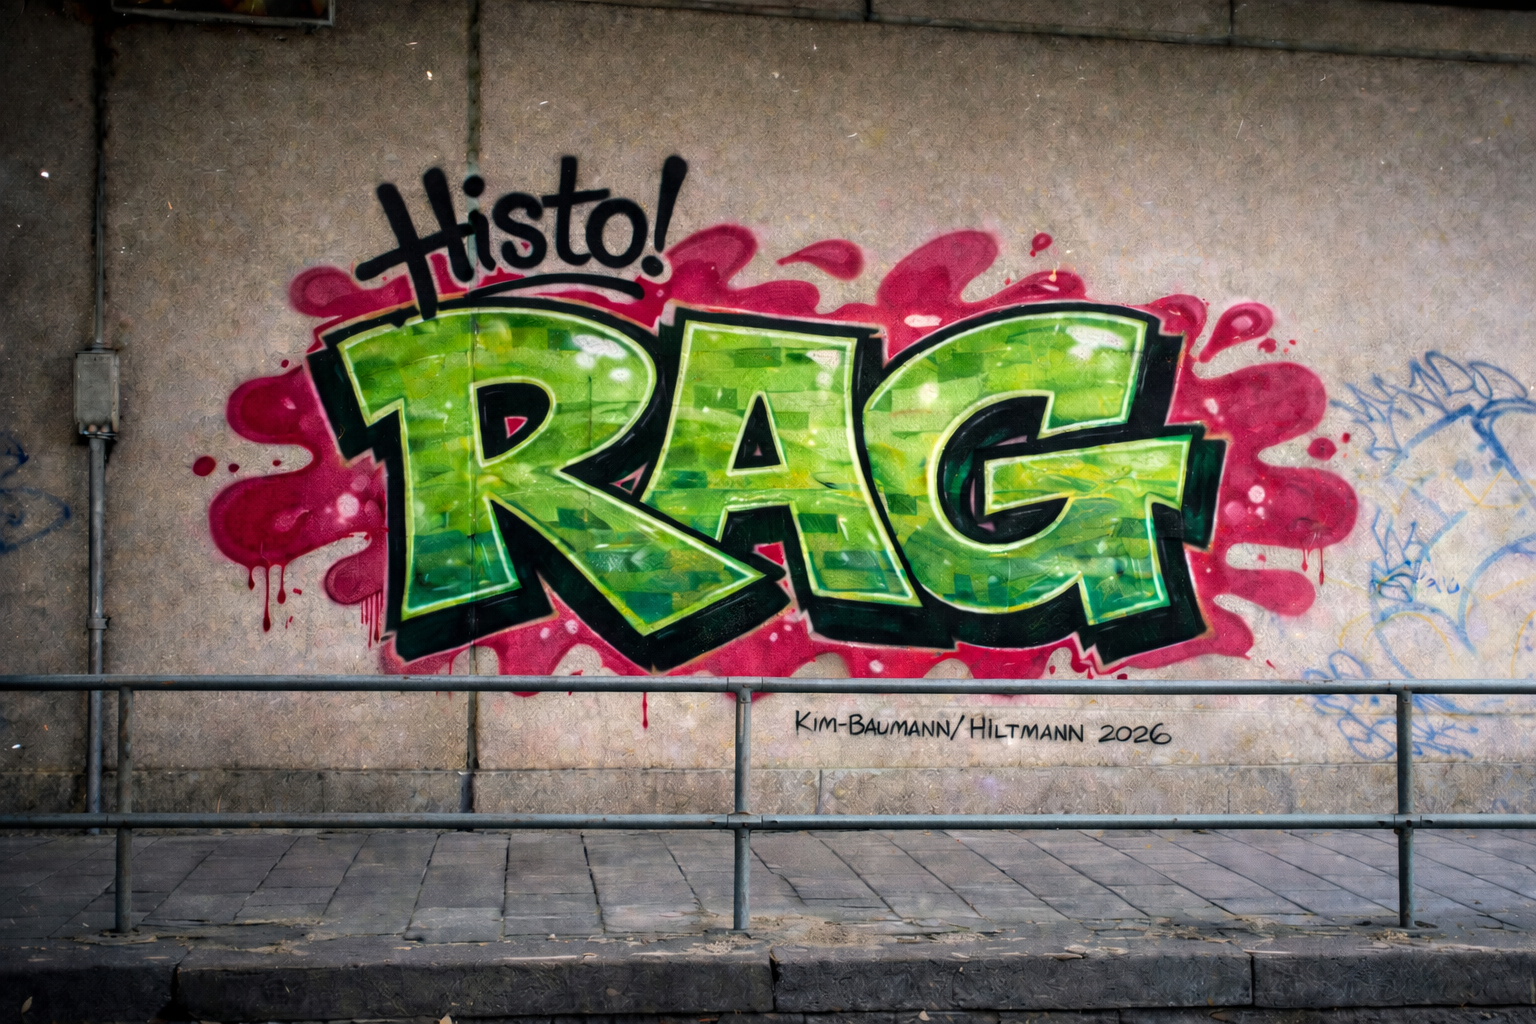

In [1]:
from IPython.display import Image, display
metadata={
    "jdh": {
        "module": "object",
        "object": {
            "type":"image",
            "source": [
                "Cover image: HistoRAG - Reconceptualising RAG Through Historical Methodology"
            ]
        }
    }
}
display(Image("./media/titlepic.png"), metadata=metadata)

 (optional) This article was originally published (...)

RAG, Digital History, LLM, Historical Methodology, Der Spiegel, Discourse Analysis, Critical Technical Practice

This article introduces HistoRAG, a framework for redesigning Retrieval-Augmented Generation (RAG) to support historical research methodology. Standard RAG systems are built for factual question-answering, treating retrieval and generation as a seamless pipeline optimised for speed and accuracy. Historical scholarship, by contrast, demands source sovereignty, interpretive transparency, and temporal sensitivity, values that standard architectures not only fail to support but actively undermine. Drawing on Agre's Critical Technical Practice, we embed these disciplinary commitments into system architecture through three interventions: separated retrieval and generation, which restores the historian's heuristic phase of source evaluation before computational interpretation begins; temporal windowing, which counters the presentist bias of similarity-based retrieval by ensuring proportional representation across the research period; and LLM-as-a-Judge, which introduces transparent, contestable evaluation of source relevance against researcher-defined criteria. We demonstrate the framework through a case study analysing computerisation discourse in Der Spiegel (1950–1979), working with a corpus of 102,189 articles. Empirical evaluation shows that semantic retrieval combined with LLM evaluation surfaces relevant sources that keyword filtering misses, while the LLM-as-a-Judge component proves essential for managing the noise that broadened retrieval introduces. The generation phase produces what we term Zwischentexte (intermediate texts), these are not answers but interpretive proposals that historians can verify, contest, and develop. We argue that the central question for LLMs in digital humanities is not whether machines can "read" but how we design systems that make their interpretive interventions visible and contestable, preserving the scholar's epistemic agency throughout.

# 1. Introduction: The Hermeneutics of DH 2.0

Digital History is currently undergoing a transition that is both fundamental and disruptive. For decades, computational methods have offered historians powerful tools for analysing large corpora. Methods that, as we argue, generally share a focus of operating on sequences of characters, i.e. the level of signs rather than meaning. Large Language Models (LLMs) now promise something fundamentally different. Semantic interpretation at scale. This shift from computing sequences of characters to computing the semantic meaning of those sequences of characters raises urgent questions. How do we preserve historical scholarship's commitment to source criticism, interpretive authority, and transparent argumentation when working with AI systems that can "understand" thousands of documents and generate plausible-sounding analyses? This paper argues that Retrieval-Augmented Generation (RAG), when designed around historical methodology rather than technical optimisation, offers a path forward. But only if we actively shape these systems to embody the epistemological values that define our discipline. 

**From Quellengenres to Computational Methods**

As Welskopp (<cite data-cite="welskopp2008HistorischeErkenntnis"></cite>) argues, the expanding empirical basis of historical research (from textual sources to numerical data, artefacts, images, and audiovisual material) has made methodological pluralism not a weakness of the discipline but a necessity. Among the consequences of this expansion is the growing confrontation with large corpora of sources: vast collections of periodicals, correspondence, administrative records, and other serial sources that extend far beyond the individual documents traditional analogue hermeneutic practices were designed to handle. These corpora demand new analytical approaches that can operate at scale, while still supporting the interpretive work that defines historical research, namely understanding context, evaluating reliability, and constructing plausible arguments about the past. This tension between empirical scale and interpretation has driven the development of computational methods in historical research.

The computational approaches that emerged form what we might retrospectively call DH 1.0. These share a fundamental characteristic in that they operate at the level of sequences of characters rather than semantic meaning. Whether employing topic modelling, stylometry, or text reuse detection, these methods are what Hiltmann et al. (<cite data-cite="hiltmann2021DigitalMethodsPractice"></cite>) describe as "semantically blind." Computers process text as sequences of characters in the "realm of signal" rather than the "realm of meaning" (p. 133). A text reuse tool like TRACER can identify that the word "mirabilia" appears 62 times in the Vulgate, but it cannot understand why a crusade chronicler might invoke this term or what meanings it carries in different contexts (<cite data-cite="hiltmann2021DigitalMethodsPractice"></cite>, p. 132). Topic modelling operates on co-occurrence matrices (statistical patterns of words appearing near each other) which Mohr et al. (<cite data-cite="mohr2015ComputationalHermeneutics"></cite>) aptly describe as a "poor-man's measure of semantic structure" (p. 2). Tools like Voyant, widely used in Digital History, exemplify this approach. They offer powerful ways to visualise word frequencies, identify patterns, and compare texts, but they work entirely through sequence-based operations (<cite data-cite="rockwell2016HermeneuticaComputerassistedInterpretation"></cite>).

This creates a formalisation-interpretation gap. DH 1.0 methods excel at certain tasks, aligned with scaling across massive corpora, identifying formal patterns, ensuring reproducibility through explicit procedures. But they require historians to perform two distinct types of labour. Firstly, translating research questions into the formal operations a computer can execute (what should be encoded? which patterns matter? how should similarity be measured?), and second, interpreting the results back into historical meaning (what do these word frequency lists tell us? why do these documents cluster together? is the parallel use of a given chain of characters in two texts coincidence or is it actually meaningful?). The historian works between quantitative outputs (similarity scores, network graphs, distribution curves) and historical understanding, bridging the gap that sequence-based methods cannot themselves cross. Yet this explicit formalisation also carries a methodological strength, as historians must themselves interpret results against the background of their formalisation, maintaining interpretive authority throughout the process.

**LLMs and the Promise of Semantic Interpretation**

Large Language Models represent a fundamental shift in this landscape. Unlike DH 1.0 methods that operate on character sequences, LLMs work with what Simons, Zichert, and Wüthrich (<cite data-cite="simons2025LargeLanguageModelsa"></cite>) call "contextualised representations". They are computational approximations of meaning that enable both pattern recognition and interpretive generation (p. 2). The computational task moves from counting characters to inferring meaning from context, from identifying that words appear together to understanding how they relate to each other as a network of words. This shift promises to bridge aspects of both traditional historical practice and computational scale. LLMs can engage with contextual nuance, handle ambiguity, and work at the semantic level AND they can process thousands of documents, identifying patterns invisible at scale.

This potential comes with profound dangers. If DH 1.0's sequence-based methods required historians to explicitly formalise their analytical choices and interpret the results of the process on this basis, LLMs risk hiding these choices entirely. When a system can "read" thousands of sources and generate coherent analyses, how do we preserve the interpretive authority that defines historical scholarship? How do we maintain the transparency and contestability that historical methodology demands, precisely because our claims cannot be validated through experimental replication? As Chen et al. (<cite data-cite="chen2025ToolsGenerativeAI"></cite>) argue, this is fundamentally a question of epistemic agency. Of preserving researchers' capacity to make, evaluate, and contest knowledge claims rather than delegating these to computational systems. The risk is not that AI will replace historians but that we will accept interfaces that obscure the critical decisions (source selection, relevance evaluation, interpretive framing) that constitute scholarly practice.

This urgency is underscored by recent workforce studies identifying historians among professions with high "AI applicability scores" (<cite data-cite="tomlinson2025WorkingAIMeasuring"></cite>). While such assessments often miss the interpretive complexity of historical practice (particularly the physicality of archival work), there is truth in recognising that portions of historical labour are "augmentable." But rather than asking how historians should adapt to AI, as some propose (<cite data-cite="grossmann2023AITransformationSocial"></cite>), we must invert the question and ask how computational systems can be designed to preserve and extend historical methodology? If we do not actively shape the tools we use, commercial vendors will design them for us, optimising for efficiency and seamless user experience rather than epistemic transparency, losing the core of academic research (<cite data-cite="chen2025ToolsGenerativeAI"></cite>).

**RAG as Methodological Architecture**

If LLMs are to support historical research without undermining its foundations, we need architectures that preserve source traceability and enable critical evaluation. This is why we argue for Retrieval-Augmented Generation rather than fine-tuning as the appropriate framework for LLM usage in history. This requires first understanding what LLMs fundamentally are, and are not. LLMs are not designed to reproduce facts but to produce language. Built on networks of words and their contextual relationships, they operate in a structuralist sense where the meaning of a word derives from its relations to other words. While this inherently involves factual content, LLMs have no reference system and no truth claim. They are, in essence, language generation systems rather than knowledge retrieval systems (<cite data-cite="weatherby2025LanguageMachinesCultural"></cite>). Fine-tuning (training a model on specific historical corpora) buries whatever knowledge it absorbs within neural network weights, producing outputs that mimic expertise without the ability to cite sources, generating plausible text based on statistical likelihood rather than traceable evidence. This violates a fundamental principle of historical scholarship, historical claims must remain connected to their evidentiary foundations.

RAG preserves the distinction between the reasoner (the LLM) and the archive (the documents), using a given set of texts as the basis for its responses rather than relying solely on the parametric knowledge the model acquired during training (<cite data-cite="lewis2020RetrievalAugmentedGenerationKnowledgeIntensive"></cite>). This approach allows us to trace any generated insight back to specific sources, preserving what German historiography has long emphasised as source traceability. Whether framed through Koselleck's "veto right" the tradition of Quellenbeleg, or more contemporary discussions of Synthese (the active construction of historical meaning through interpretive frameworks; see also Rüsen's systematic treatment of these concepts in <cite data-cite="rusen2019Historik"></cite>). The specific epistemological stance matters less than the shared commitment; historical claims must remain connected to their evidentiary foundations.

RAG brings to the forefront questions around a new division of labour between historian and machine. As LLM capabilities expand, where should historians' work lie? In this paper, we do not prescribe a final answer. Rather, we attempt to demonstrate how RAG systems can be designed to synthesise the complementary strengths of historian and machine — but only if we actively embed historical methodology into system architecture.

To understand these dynamics more concretely, consider how historians would approach the research on a large archival collection of a magazine like *Der Spiegel* in the analogue. Printed Index Volumes exist for *Der Spiegel* which were compiled by editors who categorised articles by topic, person, and theme. These are invaluable resources but they are not neutral or infallible either. They encoded the conceptualisations, interests, and blind spots of their creators, through their usage the historian passes some of their epistemological agency to the creators of these indices. They steer our capacity to understand, evaluate, and contest the decisions that shape their encounter with sources.

Similarly, digital search interfaces also have shared epistemological agency. Database design, algorithm usage, interface design are all ways in which traditional DH 1.0 resources influence the historians process of understanding the corpus. RAG systems intensify this dynamic. Simons et al. (<cite data-cite="simons2025LargeLanguageModelsa"></cite>) identify an "accessibility-literacy tradeoff", they argue as natural language interfaces lower barriers to entry, the interpretive assumptions embedded in retrieval algorithms, similarity metrics, and prompt templates become increasingly obscured. We reframe this as a problem of *affordances* — what systems make easy shapes what users do, often below the threshold of conscious methodological choice. The danger lies not in using computational tools but in losing awareness of the epistemological work these tools perform on our behalf, on where and with whom/what we are sharing our agency.

The mere fact that how we share this agency is changing, and that we might share it with LLMs need not be inherently bad. Cultural techniques (*Kulturtechniken*) and scholarly practices (*Wissenschaftspraktiken*) evolve. We no longer use card catalogues (Zettelkatalog), and this is not inherently problematic. But some transformations carry different risks. The GPS user who blindly follows directions without checking against physical reality can end up driving into a river. The danger is not change itself but losing awareness of what we are doing and why. 

For historical research, this means preserving the tenets of historical work (saubere historische Arbeit), mainly the grounding in source sovereignty (Hoheit der Quelle) and source citation (Quellenbeleg). These principles, though articulated differently across historiographical traditions, reflect a shared commitment to transparent source work that underlies both traditional Quellenkritik and more recent discussions of historical synthesis. Historical claims must remain traceable to their evidentiary foundations. A seamless RAG interface that simply answers questions threatens this foundation by hiding the crucial decisions about which sources matter and why. Our methodological interventions are designed to prevent this loss of awareness, ensuring that computational affordances enhance rather than undermine the practices that define historical scholarship.

**Critical Technical Practice and Three Methodological Interventions**

Our approach draws on what Agre (<cite data-cite="agre1998CriticalTechnicalPractice"></cite>) termed Critical Technical Practice, emphasising the act of not critiquing technology from outside but actively designing technical systems that embody methodological principles. As Fickers and Tatarinov (<cite data-cite="fickers2022DigitalHistoryHermeneutics"></cite>) argue, we need what they call "digital hermeneutics" — critical reflection on how computational infrastructures intervene in research practices across every phase from search through interpretation to publication (p. 8). This means recognising that system architecture itself, i.e. how we chunk texts, rank results, choose and prompt models, makes epistemological choices that must be made visible and contestable rather than hidden in "seamless" interfaces, and that these infrastructures are an integral part of our process of historical knowledge production.

Building on established RAG architecture, we introduce a framework we call HistoRAG, which embeds historical values into system design through three methodological interventions:

-	Separated Retrieval and Generation: We formally decouple corpus construction from analysis, allowing historians to examine and critique sources before any computational "reading" begins, separate from the following phases of analysis and interpretation. This preserves the heuristic phase (finding and evaluating sources) that precedes interpretation.
-	Temporal Windowing: We enforce proportional representation across time periods to counter vector similarity's temporal blindness. Left unchecked, similarity-measures (often cosine similarity is used in RAG systems to retrieve relevant text chunks) retrieve sources from peak coverage years, distorting historical perspective. Our system ensures balanced representation across the research period.
-	LLM-as-Judge: Rather than relying solely on mathematical vector similarity, we use LLMs to evaluate source relevance against explicit, historian-defined criteria. This turns algorithmic selection from a black box into a transparent, argumentative process with preserved justifications that can be reviewed and contested.

Taken together, these interventions transform RAG from a simple task-oriented information retrieval system into a framework capable of supporting historiographical inquiry at a meta-level. Standard RAG systems are designed to answer factual questions, retrieving relevant passages in response to a specific query. Our approach, by contrast, enables historians to pose questions not only about what the sources say, but about how they say it; how topics are framed and narrated across time, what modes of representation (*Darstellungsweisen*) characterise different periods, and how discursive patterns shift within a corpus. It is this capacity for meta-level questioning that makes the system a genuinely historiographical tool rather than merely a search engine.

The outputs of this process are what we call *Zwischentexte* — intermediate texts that serve as hermeneutic aids rather than final historical writing. These new textualities function as explanatory scaffolding. Drawing on Droysen's distinction between *Erklären* (explaining) and *Verstehen* (understanding), we might say that LLMs can provide explanations by identifying patterns, synthesising connections across texts, articulating relationships, but the task of *Verstehen* (a deeper historical understanding that also defines history as a hermeneutic science (<cite data-cite="gadamerWahrheitUndMethode"></cite>), the movement from explanation to grasping meaning in context) this remains with the historian. We ensure that LLMs function as transparent partners in the research process, augmenting our capacity to work with massive corpora without automating away our capacity to interpret and judge.

As a consequence, our approach also liberates historians from dependence on commercial RAG platforms, whose design choice, optimised for efficiency rather than methodological rigour, would otherwise predetermine the epistemic framework of historical inquiry.


**Structure of the Paper**

In the following sections, we operationalise this framework through SPIEGELragged, our implementation of HistoRAG for a case study on computerisation discourse in Der Spiegel (1950–1979). The methodological interventions that constitute HistoRAG are transferable to other corpora and research contexts; [SPIEGELragged](https://scm.cms.hu-berlin.de/digital-history/digital-history-forschung/spiegel_rag/spiegelragged){:target="_blank"} reflects the specific configurations (chunking parameters, embedding models, evaluation criteria, metadata filters) tailored to this particular corpus. Section 2 introduces the research question and corpus. Section 3 outlines RAG fundamentals. Section 4 critiques standard RAG's limitations for historical research. Sections 5-7 detail our three methodological interventions. Finally, we discuss the epistemic status of *Zwischentexte* and the broader implications of this new division of labour between historian and machine through our case study.

# 2. Research Question and Corpus: Tracking Computerisation Discourse in Postwar Germany

The arguments made here are the results of a long period of testing and refining both SPIEGELragged and our broader conceptualisation of what LLMs can mean for the future of historical work. Throughout this period our approach has been to stress test through actual application on historical research questions. We started in a classroom setting where we focused on the representation of decolonisation in German media. In this paper we will be doing the same, however, with the focus on computerisation and automation in West Germany from 1950 to 1979. We will use this research question to display the functionalities, possibilities and limitations of our SPIEGELragged application, thereby introducing and evaluating the DH 2.0 framework.

### **2.1 The Research Question**

How did West German society's understanding of computerisation evolve from the 1950s through the 1970s? We operationalise this through two levels of analysis. First, at the level of terminology: how did the language used to describe computing shift from early anthropomorphising terms ("Elektronenhirn," "Maschinengehirn") through technical designations ("Rechner," "Computer") to bureaucratic abstractions ("EDV," "Datenverarbeitung")? These terms carried distinct connotations. The "Elektronenhirn" evoked both wonder and anxiety about artificial intelligence, while "EDV" suggested bureaucratic rationalisation and workplace transformation. Second, at the level of public sentiment: how did hopes and fears associated with computerisation and automation evolve across three decades?

These questions have been addressed by existing scholarship through methods that face structural limitations our approach aims to overcome. As Schmitt et al. (<cite data-cite="schmitt2016DigitalgeschichteDeutschlandsForschungsbericht"></cite>) observe, computerisation history in Germany consists largely of "Einzelerzählungen" (individual stories about companies, sectors, or technologies that remain disconnected from comprehensive analysis of broader discourse patterns (p. 70)). What is needed, but methodologically difficult to achieve, is systematic engagement with large corpora of sources at a scale that, as Welskopp (<cite data-cite="welskopp2008HistorischeErkenntnis"></cite>, p. 11) argues, demands new methodological approaches beyond classical hermeneutic critique of individual documents.

**The Analogue Approach**

Schuhmann's (2012) work represents a foundational historical treatment of computerisation's social dimensions in West Germany, exemplifying the value of traditional archival research. She traces a narrative arc from early euphoria (scenarios designed to eliminate "die Fehlerquelle Mensch" and promises of "Humanisierung der Arbeit") through to the anxieties of the 1970s (p. 233). Her analysis documents the shift in societal perception, showing how the same technologies initially celebrated for creating the "perfektes Unternehmen" came to be seen as threats to employment and social stability, culminating in the catastrophist rhetoric of 1978 when *Der Spiegel* warned that "winzige elektronische Bausteine bedrohen Millionen von Arbeitsplätzen" (p. 250).

Yet Schuhmann herself points to the necessity of more detailed investigation and the lack thereof. Regarding the ambivalent societal response to technological change in the early 1970s, she notes: "Auch wenn eingehende Untersuchungen dazu noch fehlen" (even though detailed investigations are still lacking) (p. 250). The gap she identifies is not one of interpretation but of coverage. Her methodology necessarily relies on what we might see as easily findable sources, such as the 1978 *Spiegel* issue "Uns steht eine Katastrophe bevor" (A disaster is looming) appears as emblematic precisely because its significance requires no discovery. It announces itself through the title and being placed as the cover story for the issue. Similarly, Bergien's (2017) work on computerisation and the security state builds core arguments from specific *Spiegel* issues easily associated with the topic through their titles (p. 258). These are the articles analogue researchers could locate through traditional archival methods: cover stories, indexed features, sources whose relevance is immediately apparent from metadata.

**The DH 1.0 Approach**

Busch (<cite data-cite="busch2015DiskurslexikologieUndSprachgeschichte"></cite>) addressed the coverage problem through corpus-based discourse lexicology. Analysing computerisation discourse across both parliamentary debate and the popular press (including 216 thematic articles from *Stern*) he systematically tracked the evolution of computerisation vocabulary from early anthropomorphising terms through to contemporary usage. His approach enabled pattern identification, for example mapping when "Elektronengehirn" gave way to "Computer," documenting semantic fields around automation terminology, and tracing the "Entfachsprachlichung" (de-specialisation) of technical vocabulary as it entered popular discourse (p. 215).

Yet even this substantial corpus-linguistic effort confronted capacity constraints. Busch states: "eine lückenlose Vollerhebung des gesamten gemeinsprachlichen Technologiewortschatzes im STERN und im Parlament über vier Jahrzehnte hinweg aus Kapazitätsgründen nicht möglich" (p. 170) (a complete survey of technology vocabulary across four decades proved impossible). More fundamentally, Busch's method still required pre-selecting thematic articles, by choosing texts whose titles, cover stories, or explicit subject matter marked them as relevant. But as Busch himself notes, the popularisation of technology vocabulary occurs precisely through its dispersion into contexts where computerisation is *not* the primary topic, such as a business report mentioning "EDV" in passing, a political commentary assuming reader familiarity with "Automation," or a cultural feature treating computers as unremarkable background (p. 215). These secondary, diffuse mentions may reveal more about discourse normalisation than explicit thematisations.

**The Methodological Gap**

Both approaches, despite their considerable achievements, share a structural limitation as they can only systematically engage with sources whose relevance is *apparent in advance*. Consider the difference between an article titled "Die Computer-Revolution: Fortschritt macht arbeitslos" (The Computer Revolution: Progress Creates Unemployment) (obviously relevant, consistently cited) and one titled "Hüls AG: Neue Produktionsverfahren" (Hüls AG: New Production Methods) that discusses automation extensively in the context of chemical industry restructuring (relevant but invisible to traditional search). The first appears in every study of computerisation discourse; the second does not. It may surface only through methods that search article *content* rather than metadata alone.

This gap matters because discourse normalisation (the process by which novel concepts become unremarkable common sense) occurs precisely through embedded, secondary mentions. When "EDV" appears without explanation in a political commentary, when "Automation" functions as assumed context in a labour dispute article, when "Computer" requires no gloss in a business report — these moments reveal discourse shifts that explicit thematisations may not capture.

Our research questions thus demand working across massive textual corpora in ways that exceed traditional close reading but also require semantic interpretation beyond what DH 1.0 sequence-based methods can provide. When we ask how terminology shifted over thirty years, or how public sentiment evolved from euphoria to anxiety, we are posing what we call *metaquestions*, questions that operate at the level of discourse patterns rather than individual factual claims. Rather than asking "what did *Der Spiegel* say about the IBM System/360 launch?", questioning the sentiments, word choice and frequency, etc., we ask "how did the discourse of automation evolve temporally?" or "in what contexts did 'Computer' replace 'Elektronenhirn'?"

This distinction matters because it diverges from how RAG systems are typically designed and evaluated. Standard RAG systems are built for factual retrieval, and consequentially as are their benchmarks. Given a question like "When was penicillin discovered?" the system should retrieve the passage containing the answer. This paradigm reflects RAG's origins in domains like medicine and law, where users seek specific, verifiable information (a drug interaction, a legal precedent or a technical specification). Success means finding *the* relevant passage. Our metaquestions have no single correct answer. They require synthesis across hundreds of sources, attention to contextual variation, and interpretive judgment about what patterns mean. HistoRAG is designed for this different mode of inquiry — not to answer questions but to support the construction of historically informed arguments about discourse evolution.

## **2.2 Der Spiegel as Corpus: Positioning and Justification**

*Der Spiegel* emerges as an ideal corpus for investigating these discourse patterns for several interrelated reasons. Founded in 1947 as "Diese Woche" and relaunched as *Der Spiegel* in 1948, the magazine positioned itself as West Germany's leading news weekly by the 1950s (<cite data-cite="brawand1995SpiegelStoryWieAlles"></cite>). By 1956, circulation had grown eighteenfold from its 15,000 launch copies (<cite data-cite="enzensberger1962Einzelheiten1BewusstseinsIndustrie"></cite>), reaching approximately 490,000 by 1961 with an estimated readership of two million per issue. Crucially, this readership consisted not of mass audiences but of what Enzensberger termed "meinungsbildende Gruppen", such as teachers, journalists, higher-level employees, student representatives, politicians from city councillors to ministers (p. 63). The magazine's influence thus operated through a multiplier effect by shaping the discourse of those who themselves shaped public opinion.

The publication's temporal span makes it particularly valuable for tracking long-term discourse evolution. Our corpus covers 1950-1979, a clean thirty-year period that captures computerisation's trajectory from early mainframes in specialised business and administrative contexts through to the threshold of personal computing's visibility (<cite data-cite="schmitt2016DigitalgeschichteDeutschlandsForschungsbericht"></cite>). This period encompasses the key phases of West German computerisation, from an initial euphoria and experimentation (1950s) transitioning to widespread adoption in business and administration (1960s), and growing public debate about automation's social consequences (1970s).

Finally, the scale of the digitised archive creates both opportunity and necessity. With 102,189 articles across thirty years, the corpus exceeds what any individual researcher could systematically engage through close reading. 

*Der Spiegel* was at the heart of the German post-war media landscape. It offers a wealth of issues and articles that were widely read by an informed readership directly affected by the issues of automation and computerisation. 

## **2.3 SPIEGEL Critique**

No source is neutral, and any investigation involving *Der Spiegel* demands critical reflection on its composition and standing within the German media landscape. Enzensberger's (1962) contemporary critique identified fundamental tensions in the magazine's approach. He argues, the magazine wrote in the "Story" format, which prioritised narrative effect over straightforward reporting, creating "eine skeptische Allwissenheit" (a skeptical omniscience) that doubted everything except itself (p. 75).

This characteristic enhances rather than diminishes the corpus's value for discourse analysis. Story-framing means coverage extended beyond official pronouncements to include speculation, analysis, and narrative interpretation that reveal how events were understood at the time. As Enzensberger notes, this interpretive mode was readily adopted by the magazine's influential readership, the "meinungsbildenden Gruppen" whose own discourse it shaped.

These limitations do not invalidate *Der Spiegel* as a historical source; they require consciousness about what the corpus can and cannot reveal. The magazine remains what Enzensberger reluctantly conceded: "unentbehrlich" (indispensable, p. 83). It was the only major publication that refused self-censorship, that challenged power regardless of who held it, and that attempted systematic documentation of political and social developments. Its very biases toward narrative drama, its insider access and its skeptical positioning make it valuable for understanding how technological change was interpreted, contested, and made meaningful in postwar Germany.

**Political Evolution and Staff Composition**

The magazine's political positioning shifted significantly over time. Initially aligned with FDP nationalist-liberalism in the 1950s under Augstein's editorship, it gradually attracted a left-liberal readership, particularly after the 1962 Spiegel-Affair when Augstein's imprisonment for alleged treason made him a martyr for press freedom (<cite data-cite="hachmeister2015HeideggersTestamentPhilosoph"></cite>, p. 7). However, the early staff composition complicates simplistic left-liberal narratives: Hachmeister (<cite data-cite="hachmeister2015HeideggersTestamentPhilosoph"></cite>) documents significant employment of former SS officers and Nazi propagandists, particularly in investigative and intelligence-oriented positions — what he terms the "Six-Gruppe" (pp. 89-92). While this reflected broader patterns of postwar German institutional continuity rather than being unique to *Der Spiegel*, it shaped the magazine's approach to authority, secrecy, and power in ways that influenced coverage.

The overwhelmingly male editorial staff (Brawand, 1995; Hachmeister, 2015, p. 84) meant that perspectives on workplace automation, office rationalisation, and technological change filtered through particular gendered assumptions about work and society. This becomes especially relevant for analysing discourse about office automation and "Büroarbeit," where impacts on predominantly female clerical workers were interpreted through male editorial perspectives.

## **2.4 Loading and Examining the Corpus**

We begin by downloading and loading the complete *Der Spiegel* corpus covering 1950-1979. The data is organised as CSV files by year, each containing all articles from that year with metadata including publication date, title, subtitle, keywords, full text, and URL.

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set visualisation style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

extract_dir = 'corpus_data'

# Load all years
data_path = Path(f"{extract_dir}/csv_daten")
years = range(1950, 1980)

dfs = []
for year in years:
    file_path = data_path / f"{year}.csv"
    if file_path.exists():
        df_year = pd.read_csv(file_path)
        dfs.append(df_year)
        print(f"✓ Loaded {year}: {len(df_year):,} articles")
    else:
        print(f"✗ Missing: {year}")

# Combine all dataframes
df = pd.concat(dfs, ignore_index=True)
print(f"\n{'='*50}")
print(f"Total articles loaded: {len(df):,}")
print(f"Years covered: {df['Jahrgang'].min()} - {df['Jahrgang'].max()}")

✓ Loaded 1950: 3,013 articles
✓ Loaded 1951: 2,140 articles
✓ Loaded 1952: 2,192 articles
✓ Loaded 1953: 1,795 articles
✓ Loaded 1954: 1,961 articles
✓ Loaded 1955: 1,564 articles
✓ Loaded 1956: 2,967 articles
✓ Loaded 1957: 2,692 articles
✓ Loaded 1958: 2,756 articles
✓ Loaded 1959: 2,996 articles
✓ Loaded 1960: 2,971 articles
✓ Loaded 1961: 3,172 articles
✓ Loaded 1962: 3,667 articles
✓ Loaded 1963: 3,704 articles
✓ Loaded 1964: 3,619 articles
✓ Loaded 1965: 3,961 articles
✓ Loaded 1966: 3,886 articles
✓ Loaded 1967: 3,337 articles
✓ Loaded 1968: 3,885 articles
✓ Loaded 1969: 4,031 articles
✓ Loaded 1970: 4,365 articles
✓ Loaded 1971: 4,472 articles
✓ Loaded 1972: 4,619 articles
✓ Loaded 1973: 4,175 articles
✓ Loaded 1974: 3,707 articles
✓ Loaded 1975: 3,947 articles
✓ Loaded 1976: 4,000 articles
✓ Loaded 1977: 4,173 articles
✓ Loaded 1978: 4,181 articles
✓ Loaded 1979: 4,241 articles

Total articles loaded: 102,189
Years covered: 1950 - 1979


Our complete corpus comprises 102,189 articles published across 1,558 issues from January 1950 through December 1979. Let's examine the basic structure:

In [3]:
# Parse dates and create temporal variables
df['Datum'] = pd.to_datetime(df['Datum'], errors='coerce')
df['Year'] = df['Jahrgang']
df['Month'] = df['Datum'].dt.month
df['Month_name'] = df['Datum'].dt.strftime('%B')

# Calculate word counts
df['word_count'] = df['Text'].fillna('').str.split().str.len()
df['char_count'] = df['Text'].fillna('').str.len()

# Display dataset structure
print("Dataset Columns and Completeness:")
print("-" * 60)
for col in df.columns:
    non_null = df[col].notna().sum()
    pct = (non_null / len(df)) * 100
    print(f"{col:20} | {non_null:>7,} non-null ({pct:.1f}%)")

# Calculate comprehensive statistics
stats = {
    'Total Issues': df['Ausgabe'].nunique(),
    'Total Articles': len(df),
    'Articles with Text': df['Text'].notna().sum(),
    'First Date': df['Datum'].min().strftime('%Y-%m-%d'),
    'Last Date': df['Datum'].max().strftime('%Y-%m-%d'),
    'Articles 1950s': len(df[df['Year'] < 1960]),
    'Articles 1960s': len(df[(df['Year'] >= 1960) & (df['Year'] < 1970)]),
    'Articles 1970s': len(df[df['Year'] >= 1970]),
    'Total Words': int(df['word_count'].sum()),
    'Total Characters': int(df['char_count'].sum()),
    'Mean Article Length (words)': round(df['word_count'].mean(), 1),
    'Median Article Length (words)': df['word_count'].median()
}

# Display summary
print("\n" + "="*60)
print("CORPUS SUMMARY STATISTICS")
print("="*60)
for metric, value in stats.items():
    if isinstance(value, (int, float)) and value > 1000:
        print(f"{metric:.<40} {value:>15,}")
    else:
        print(f"{metric:.<40} {value:>15}")

Dataset Columns and Completeness:
------------------------------------------------------------
Jahrgang             | 102,189 non-null (100.0%)
Ausgabe              | 102,189 non-null (100.0%)
nr_in_issue          | 102,189 non-null (100.0%)
Datum                | 102,189 non-null (100.0%)
Artikeltitel         | 102,189 non-null (100.0%)
Untertitel           |  28,003 non-null (27.4%)
Schlagworte          |  49,083 non-null (48.0%)
Text                 | 101,933 non-null (99.7%)
URL                  | 102,189 non-null (100.0%)
Autoren              |      15 non-null (0.0%)
Month                | 102,189 non-null (100.0%)
Year                 | 102,189 non-null (100.0%)
Month_name           | 102,189 non-null (100.0%)
word_count           | 102,189 non-null (100.0%)
char_count           | 102,189 non-null (100.0%)

CORPUS SUMMARY STATISTICS
Total Issues............................              53
Total Articles..........................         102,189
Articles with Text................

The corpus totals approximately 70.4 million words with a median article length of 465 words, though with substantial variation (mean: 689 words) reflecting the mixture of brief news items, extended features, and investigative reports characteristic of the magazine's format. To note, 99.7% of articles contain text content, with the small gaps (256 articles) resulting from OCR failures or digitisation issues in the archive. The author field (*Autoren*) is notably sparse (only 15 entries across the entire corpus) reflecting *Der Spiegel*'s institutional editorial practice of publishing most articles without individual bylines.

Now let's visualise the overall corpus structure:

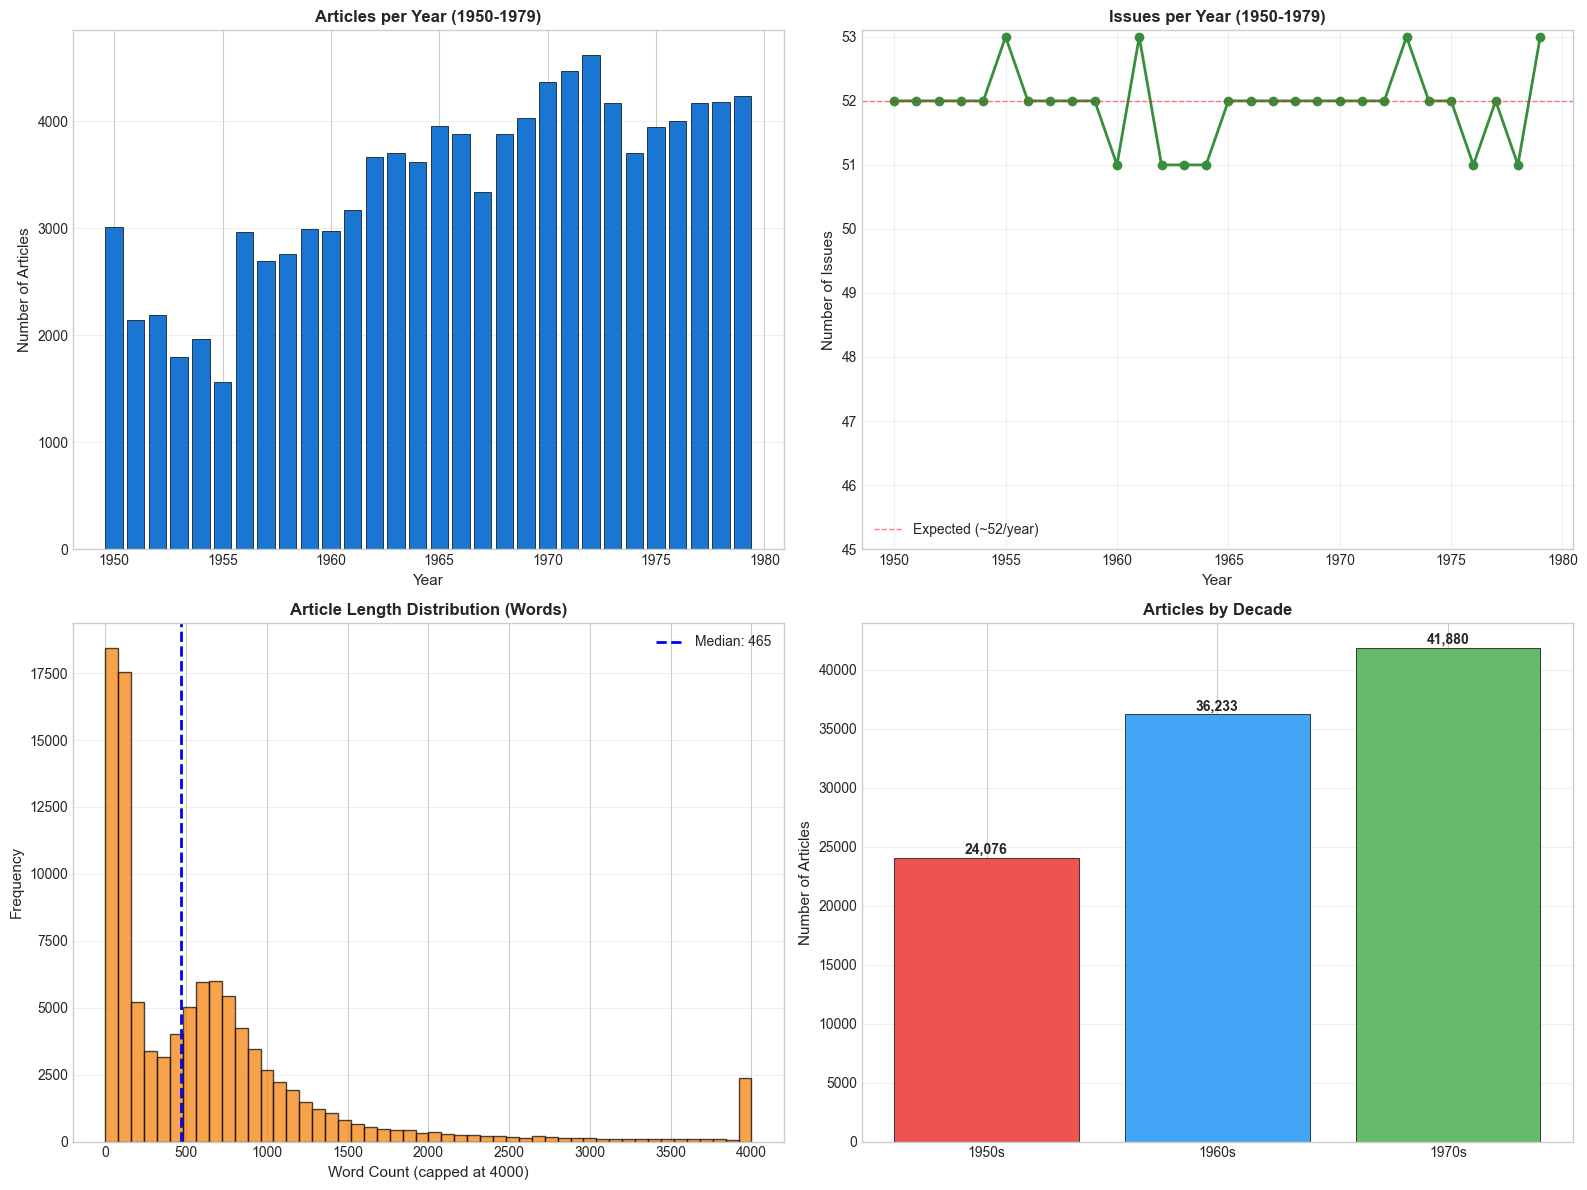

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top-left: Articles per year
articles_per_year = df.groupby('Year').size()
axes[0, 0].bar(articles_per_year.index, articles_per_year.values,
               color='#1976D2', edgecolor='black', linewidth=0.5)
axes[0, 0].set_xlabel('Year', fontsize=11)
axes[0, 0].set_ylabel('Number of Articles', fontsize=11)
axes[0, 0].set_title('Articles per Year (1950-1979)', fontsize=12, fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)

# Top-right: Issues per year (showing publishing irregularities)
issues_per_year = df.groupby('Year')['Ausgabe'].nunique()
axes[0, 1].plot(issues_per_year.index, issues_per_year.values,
                marker='o', linewidth=2, markersize=6, color='#388E3C')
axes[0, 1].axhline(y=52, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Expected (~52/year)')
axes[0, 1].set_ylim(bottom=45)
axes[0, 1].set_xlabel('Year', fontsize=11)
axes[0, 1].set_ylabel('Number of Issues', fontsize=11)
axes[0, 1].set_title('Issues per Year (1950-1979)', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Bottom-left: Article length distribution
axes[1, 0].hist(df['word_count'].clip(upper=4000), bins=50,
                color='#F57C00', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(x=df['word_count'].median(), color='blue',
                   linestyle='--', linewidth=2, label=f'Median: {df["word_count"].median():.0f}')
axes[1, 0].set_xlabel('Word Count (capped at 4000)', fontsize=11)
axes[1, 0].set_ylabel('Frequency', fontsize=11)
axes[1, 0].set_title('Article Length Distribution (Words)', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# Bottom-right: Articles by decade (bar chart)
decade_counts = [stats['Articles 1950s'], stats['Articles 1960s'], stats['Articles 1970s']]
decade_labels = ['1950s', '1960s', '1970s']
colors_bar = ['#EF5350', '#42A5F5', '#66BB6A']
bars = axes[1, 1].bar(decade_labels, decade_counts, color=colors_bar, edgecolor='black', linewidth=0.5)
for bar, count in zip(bars, decade_counts):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                    f'{count:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1, 1].set_ylabel('Number of Articles', fontsize=11)
axes[1, 1].set_title('Articles by Decade', fontsize=12, fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

These visualisations reveal the magazine's growth trajectory across three decades. The 1950s produced 24,076 articles (23.6% of corpus), averaging approximately 2,400 articles per year as the magazine established itself. The 1960s saw expansion to 36,233 articles (35.5%), while the 1970s peaked at 41,880 articles (41.0%), reflecting both increased pagination and expanded coverage. The issues-per-year graph shows consistency, pointing to a steadily growing increase of articles per issue over our three decades. This results in a slight imbalance in our corpus with more later date articles available. This issue will be taken up in our system design discussed in section 5.

There is a bimodal article length distribution. This reveals a potentially characteristic format, a large cluster of brief items (100-300 words) representing news briefs, short reports and letters, and a second cluster (600-1000+ words) representing investigative features and analytical pieces. This dual structure means we must be attentive to article type when analysing discourse patterns. Brief mentions of computerisation in news roundups carry different interpretive weight than extended features.

## **2.5 Identifying Computerisation Content**

Within this broader corpus, we now identify articles with substantive computerisation content. We use a keyword detection approach across multiple fields (title, subtitle, keywords, body text). The keywords themselves were derived from our exploratory engagement with the corpus through word embeddings (see Section 2.6 below), which allowed us to identify the relevant vocabulary of computerisation discourse as it appeared in Der Spiegel. Importantly, our keyword list extends beyond direct technology terms ("Computer," "Elektronenhirn," "Rechenmaschine") to include "Automation," "Automatisierung," and "Kybernetik." This reflects the discursive reality of the period. As Schuhmann (<cite data-cite="schuhmann2012TraumVomPerfekten"></cite>) has shown, terms like "Computer" and "Informatik" were not yet established in the 1950s, and computerisation entered public consciousness primarily through the discourse of Automatisierung and its implications for labour. Similarly, Schmitt et al. (<cite data-cite="schmitt2016DigitalgeschichteDeutschlandsForschungsbericht"></cite>) note that the mainframes of the 1960s and 1970s were understood through the intellectual framework of Kybernetik, which provided the conceptual vocabulary for a broader planning euphoria. Capturing these adjacent discursive fields is essential for tracing how computerisation was discussed before it had a stable name. This DH 1.0 approach helps us capture an initial assessment of the evolving terminology landscape.


In [5]:
# Can take 2-3 minutes to run

# Define computerisation keywords
keywords = [
    'Computer', 'Elektronenhirn', 'Rechner', 'IBM',
    'Datenverarbeitung', 'EDV', 'Automation', 'Automatisierung',
    'Kybernetik', 'Rechenmaschine', 'Elektronenrechner'
]

# Create search pattern (case-insensitive)
pattern = '|'.join(keywords)

# Identify articles with computerisation content in any field
df['has_computerisation'] = (
    df['Artikeltitel'].str.contains(pattern, case=False, na=False) |
    df['Untertitel'].str.contains(pattern, case=False, na=False) |
    df['Schlagworte'].str.contains(pattern, case=False, na=False) |
    df['Text'].str.contains(pattern, case=False, na=False)
)

computerisation_df = df[df['has_computerisation']].copy()

print(f"Found {len(computerisation_df):,} articles with Computerisation content")
print(f"Percentage of total corpus: {(len(computerisation_df)/len(df)*100):.2f}%")

# Identify Leserbriefe within computerisation articles
computerisation_df['is_leserbrief'] = computerisation_df['Artikeltitel'].str.contains(
    'Briefe', case=False, na=False
)
n_leserbriefe = computerisation_df['is_leserbrief'].sum()
print(f"Leserbriefe in Computerisation articles: {n_leserbriefe:,}")

# Also calculate total Leserbriefe in full corpus
df['is_leserbrief'] = df['Artikeltitel'].str.contains('Briefe', case=False, na=False)
total_leserbriefe = df['is_leserbrief'].sum()
print(f"Total Leserbriefe in corpus: {total_leserbriefe:,} ({total_leserbriefe/len(df)*100:.1f}%)")

# Update stats dictionary
stats['Computerisation Articles (total)'] = len(computerisation_df)
stats['Total Leserbriefe'] = total_leserbriefe

Found 4,207 articles with Computerisation content
Percentage of total corpus: 4.12%
Leserbriefe in Computerisation articles: 163
Total Leserbriefe in corpus: 11,286 (11.0%)


We identify 4,207 articles (4.12% of corpus) containing at least one of our computerisation keywords in the body text. It is important to be precise about what this number represents and what it does not. At this stage, we are dealing solely with the occurrence of corresponding character sequences, not with a content-based classification of the articles concerned. A term like "Rechner" could refer to a human calculator rather than an electronic computer; "Automation" might appear in contexts unrelated to computerisation. 

Moreover, our count registers articles with at least one keyword occurrence, regardless of frequency or centrality. An article that mentions "Computer" once in passing is included alongside one devoted entirely to the subject. We deliberately retain this broad, unweighted approach rather than introducing frequency thresholds or weighting schemes, because this keyword corpus serves as a DH 1.0 baseline rather than a refined analytical instrument. The limitation is structural, keyword filtering operates on character sequences and cannot distinguish an article that mentions "Computer" once in passing from one devoted entirely to the subject. Section 6.6 returns to this problem, demonstrating how LLM-based evaluation addresses it by assessing interpretive relevance to the research question rather than lexical occurrence. 

Within the computerisation subset, we identify 163 reader letters (3.9%), a notable underrepresentation given that reader letters constitute 11,286 articles (11%) of the full corpus. This imbalance likely reflects the challenge of identifying relevant reader letters through keywords alone, readers discussing technological change may use everyday vocabulary rather than technical terminology. Additionally, this provides an opportunity to evaluate the capacity of our RAG system to surface sources that this lexical approach misses (see Section 6.6).


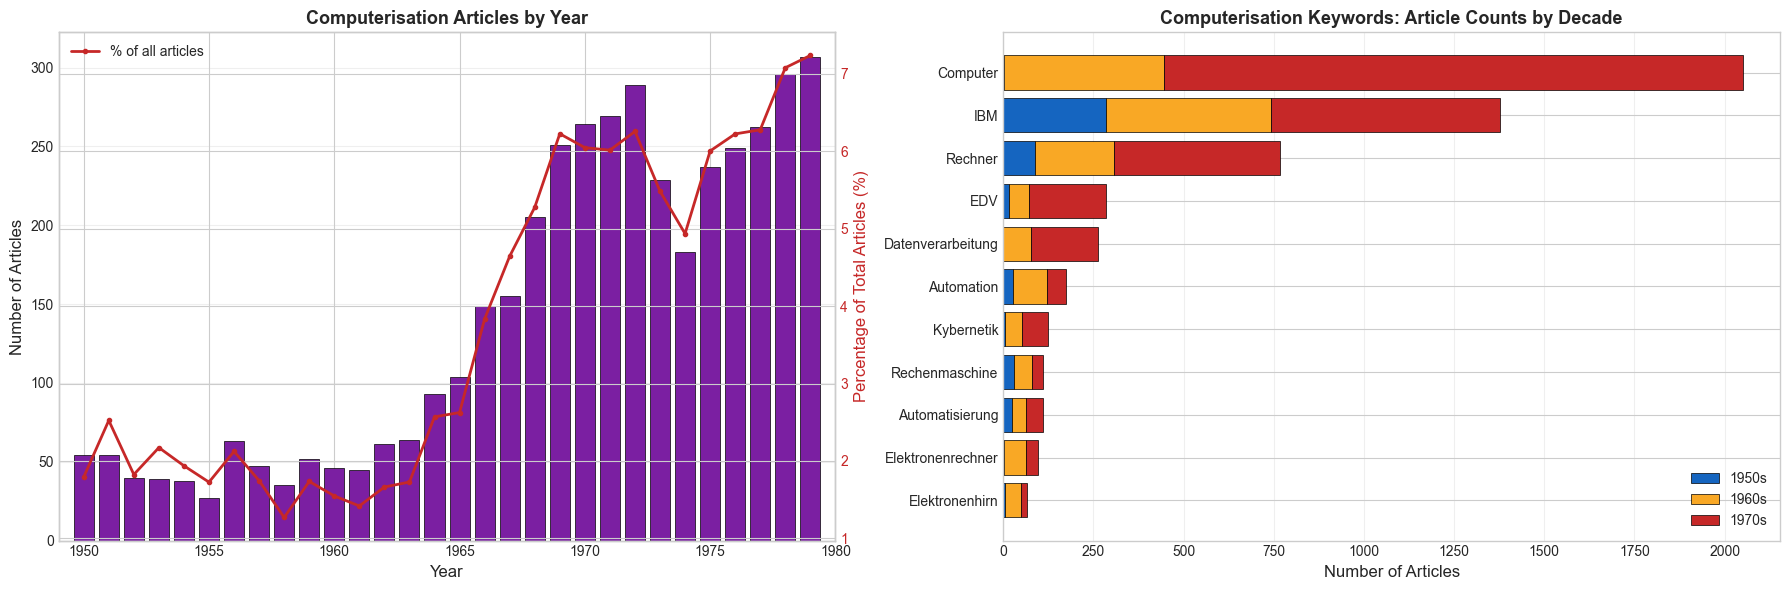

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Left: Computerisation articles by year
comp_by_year = computerisation_df.groupby('Year').size()
axes[0].bar(comp_by_year.index, comp_by_year.values,
            color='#7B1FA2', edgecolor='black', linewidth=0.5)
axes[0].set_xlabel('Year', fontsize=12)
axes[0].set_ylabel('Number of Articles', fontsize=12)
axes[0].set_title('Computerisation Articles by Year', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_xlim(1949, 1980)

# Secondary y-axis with relative frequency
ax2 = axes[0].twinx()
total_per_year = df.groupby('Year').size()
relative_freq = comp_by_year / total_per_year * 100
ax2.plot(relative_freq.index, relative_freq.values, color='#C62828', linewidth=2,
         marker='o', markersize=3, label='% of all articles')
ax2.set_ylabel('Percentage of Total Articles (%)', fontsize=12, color='#C62828')
ax2.tick_params(axis='y', labelcolor='#C62828')
ax2.legend(loc='upper left')

# Right: Keyword frequency broken down by decade
decade_colors = {'1950s': '#1565C0', '1960s': '#F9A825', '1970s': '#C62828'}
decade_bins = [(1950, 1959, '1950s'), (1960, 1969, '1960s'), (1970, 1979, '1970s')]

keyword_decade_counts = {kw: {} for kw in keywords}
for keyword in keywords:
    mask = df['Text'].str.contains(keyword, case=False, na=False)
    matched = df[mask]
    for start, end, label in decade_bins:
        keyword_decade_counts[keyword][label] = matched[
            (matched['Year'] >= start) & (matched['Year'] <= end)
        ].shape[0]

# Sort keywords by total count
totals = {kw: sum(counts.values()) for kw, counts in keyword_decade_counts.items()}
keywords_sorted = sorted(totals.keys(), key=lambda k: totals[k])

# Stacked horizontal bars
left = [0] * len(keywords_sorted)
for _, _, decade_label in decade_bins:
    values = [keyword_decade_counts[kw][decade_label] for kw in keywords_sorted]
    axes[1].barh(keywords_sorted, values, left=left,
                 color=decade_colors[decade_label], edgecolor='black', linewidth=0.5,
                 label=decade_label)
    left = [l + v for l, v in zip(left, values)]

axes[1].set_xlabel('Number of Articles', fontsize=12)
axes[1].set_title('Computerisation Keywords: Article Counts by Decade', fontsize=13, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

The temporal distribution reveals crucial patterns. Computerisation coverage remained sparse through the 1950s, began increasing in the early 1960s (particularly around 1963–1965 with IBM System/360 coverage), and grew substantially in the late 1960s through 1970s. The peak years 1972–1979 reflect the period when automation anxieties became mainstream political discourse, culminating in the 1978 "Computer-Revolution" issue. The relative frequency line confirms that this is not simply a function of corpus growth, we see that computerisation's share of all Spiegel articles rises from roughly 1–2% in the 1950s to over 6-7% by the late 1970s.

The keyword frequency breakdown by decade reveals the terminological shift that structures the entire corpus. "Computer" dominates with over 2,000 articles, overwhelmingly concentrated in the 1970s, it became the standard term only in the late 1960s. "IBM" appears in approximately 1,340 articles across all three decades, reflecting the company's early and sustained presence in West German computing consciousness. The earlier vocabulary tells a more nuanced story than simple obsolescence, "Elektronenhirn" and "Elektronenrechner" are most visible in the 1960s rather than the 1950s. Not altogether unsurprising since the 1950s produced very little computerisation coverage overall in our corpus. Their near-absence in the 1970s marks the point at which anthropomorphising terminology gave way to the now-standard "Computer." "Automation" and "Kybernetik" show presence across the 1950s and 1960s, reflecting the period when computerisation was discussed primarily through its societal implications and intellectual frameworks rather than through the technology itself. "EDV" and "Datenverarbeitung" emerge as bureaucratic-administrative terms predominantly of the 1960s and 1970s. These temporal distributions become the basis for the vocabulary periodisation experiment in Section 5, where we test whether era-specific query terms produce temporally skewed retrieval.

**Word Embeddings for Semantic Understanding**

Having established an initial picture through keyword-based analysis, operating purely at the level of character sequences, we now take a first step toward semantic understanding by integrating FastText word embeddings into our RAG application. We chose FastText specifically because it handles subword information, making it robust for the morphologically rich German language and capable of generating meaningful vectors even for rare compound words common in our corpus, such as terms like "Elektronengehirn" or "Datenverarbeitungsanlage" that other embedding models might struggle with. Word embeddings (<cite data-cite="mikolov2013EfficientEstimationWord"></cite>) represent words as dense vectors in high-dimensional space, positioning them based on the words they typically co-occur with (following the concept that meaning derives from use and context). Semantic relationships thus manifest as geometric proximity. Cosine similarity between vectors (calculated as the angle between them) provides a measure of semantic relatedness. Words used in similar contexts cluster together in the embedding space. With similarity scores ranging from 0 (orthogonal, unrelated) to 1 (identical direction, closely related) (<cite data-cite="you2025SemanticsAngleWhen"></cite>). How this works in practice can be observed directly in our corpus. Words like 'Computer' and 'EDV,' which may never appear in identical phrases, are positioned in proximity because they occur in similar contexts, a relationship that becomes visible when we query the embedding space.

In our framework, word embeddings serve a dual purpose. First, they enable exploratory analysis of the corpus vocabulary. Starting with our initial keywords, we identify semantically related terms. When searching for "Computer" for example we see "Elektronenhirne" appears with high semantic similarity (0.788) but low frequency (16 occurrences), suggesting rapid obsolescence (a pattern we explore in Metaquestion 1's analysis of terminology evolution). Technical terms like "Lochkarten" (punched cards, 79 occurrences, 0.798) and domain-specific vocabulary like "EDV" (362 occurrences, 0.802) point to different potential foci of our sources that might be explored. Second, these embeddings inform our RAG query construction. We improve our queries if we have an understanding of the language used in the corpus and then adjust the terms used in our search queries. In this sense, word embeddings also serve as an exploratory tool to advance our understanding of our corpus, a first hermeneutic engagement with the language of our sources.

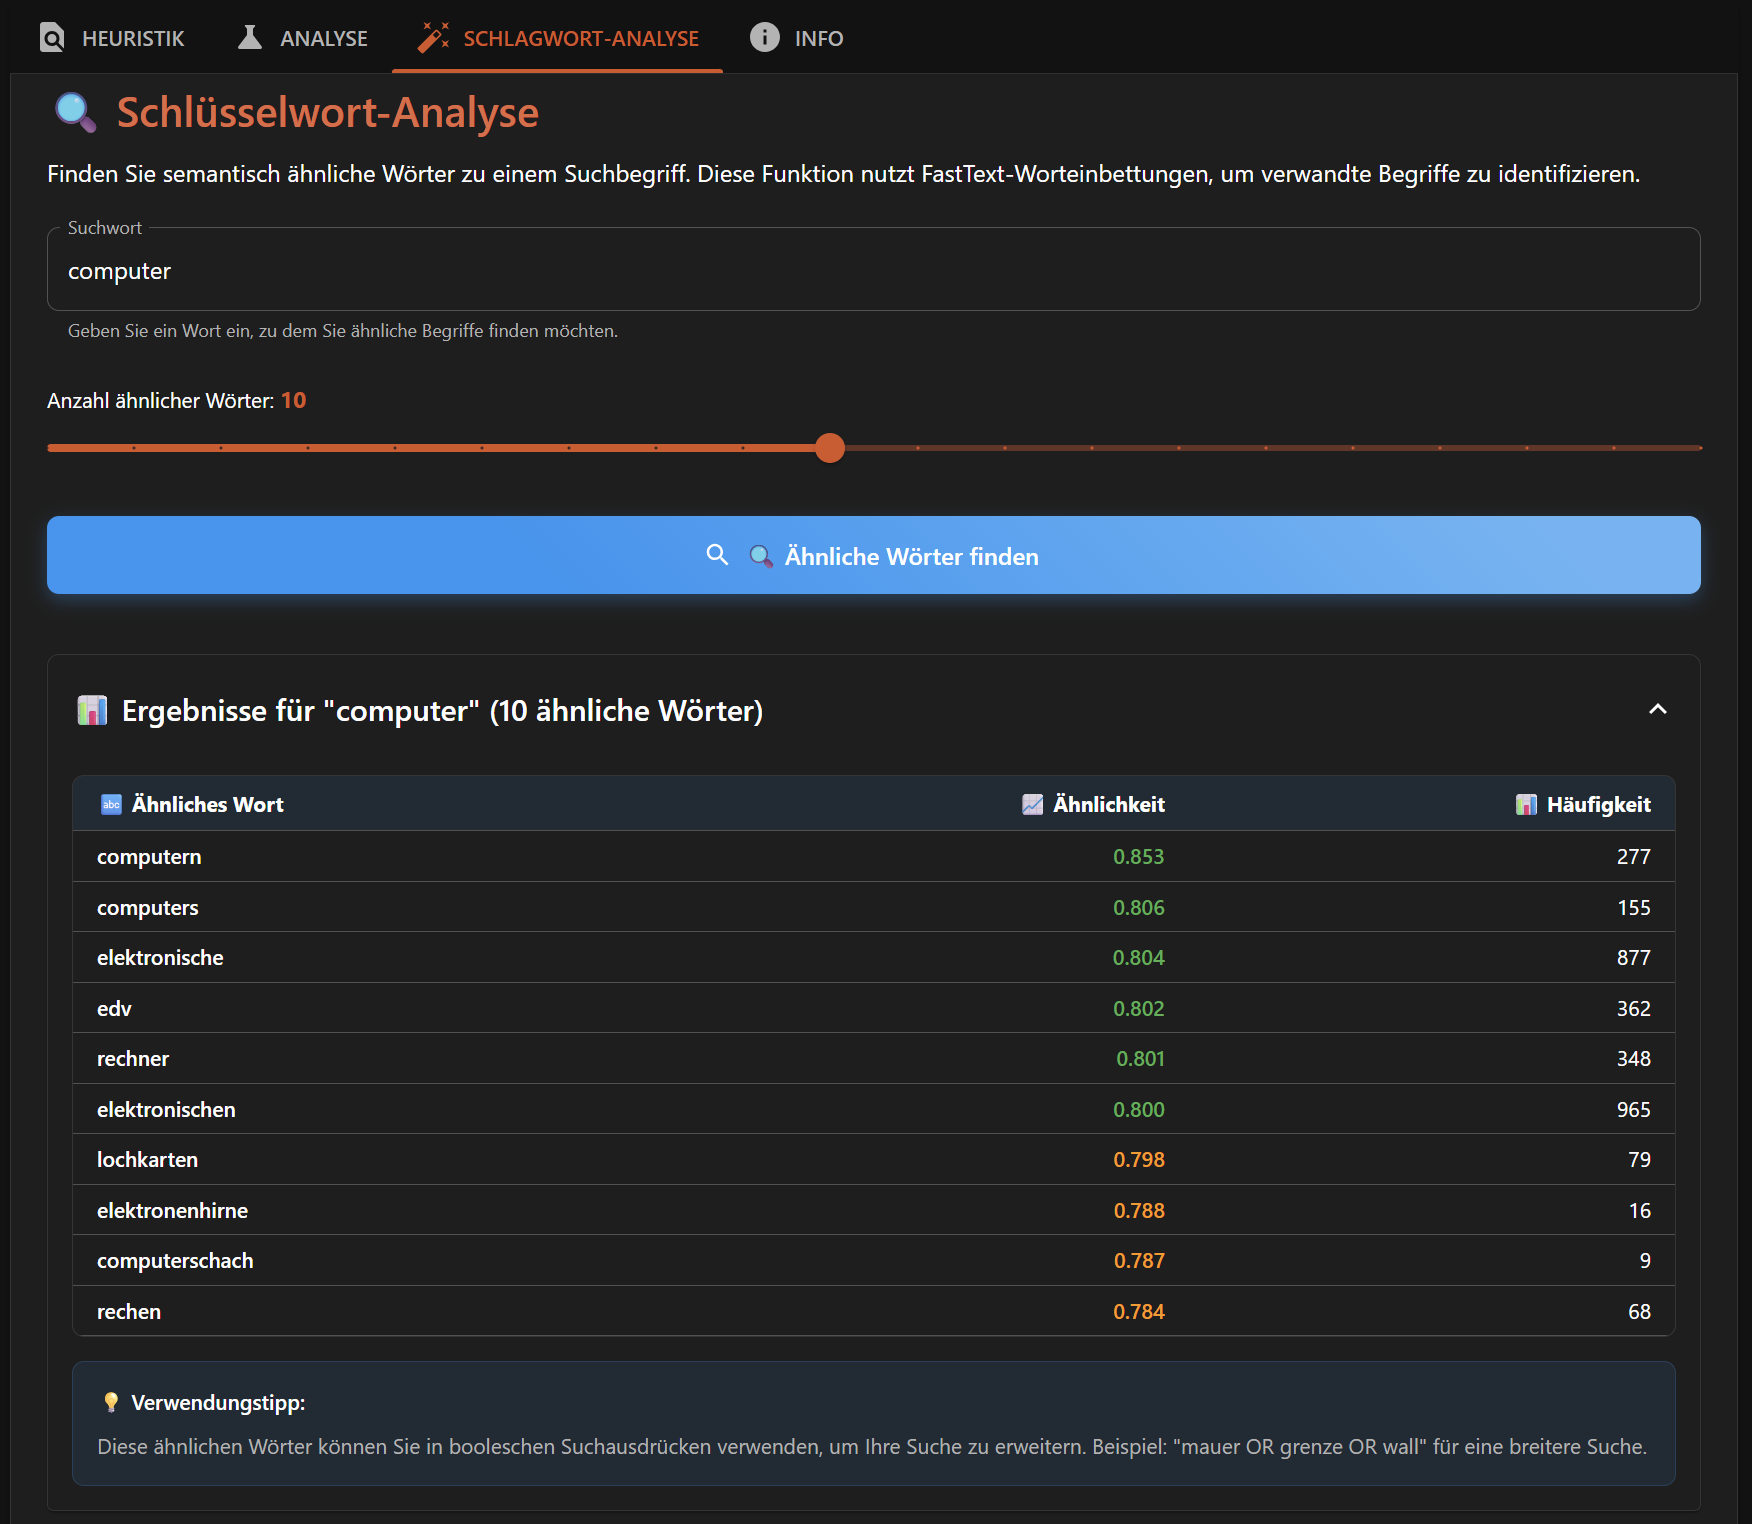

In [7]:
from IPython.display import Image, display
metadata={
    "jdh": {
        "module": "object",
        "object": {
            "type": "image",
            "source": [
                "[Screenshot of SPIEGELRagged application page with word embeddings for 'Computer']"
            ]
        }
    }
}
display(Image("media/word-embeddings-example-computer.png"), metadata=metadata)

This approach exemplifies how we build our RAG system on established DH methods. Word embeddings have demonstrated value for tracking semantic change in historical texts (see for example: Teich, 2025), and our application extends this proven technique with an additional utility that allows for the enhancement of retrieval queries in RAG pipelines.

## **2.6 Compilation of a Demonstration Subcorpus**

For the purpose of making the following demonstrations executable and reproducible for the reader, we create a smaller subcorpus that does not require resource-intensive computations over the entire corpus. This subcorpus employs two complementary selection strategies:

In [8]:
# Define specifically selected issues (computerisation-related)
specific_issues_selection = {
    1964: 14,  # Computerisation issue "AUTOMATION IN DEUTSCHLAND"
    1978: 16,  # Computerisation issue "Fortschritt macht arbeitslos"
}

# Initialise subcorpus with specifically selected issues
selected_dfs = []
selection_log = []

print("SPECIFIC ISSUES:")
print("-" * 60)
for year, issue_num in specific_issues_selection.items():
    specific_issue_df = df[(df['Year'] == year) & (df['Ausgabe'] == issue_num)].copy()
    if len(specific_issue_df) > 0:
        selected_dfs.append(specific_issue_df)
        selection_log.append({'year': year, 'issue': issue_num, 'articles': len(specific_issue_df), 'type': 'specific'})
        print(f"- {year} Issue {issue_num}: {len(specific_issue_df)} articles")
    else:
        print(f"- {year} Issue {issue_num}: NO DATA FOUND")

# Strategy 2: Random sampling - 1 issue per year for temporal coverage
np.random.seed(42)  # Reproducibility

print("\nRANDOM SAMPLING:")
print("-" * 60)
for year in range(1950, 1980):
    if year not in specific_issues_selection:
        year_df = df[df['Year'] == year]
        available_issues = year_df['Ausgabe'].unique()

        if len(available_issues) > 0:
            selected_issue = np.random.choice(available_issues, 1)[0]  # Extract scalar
            random_issue_df = year_df[year_df['Ausgabe'] == selected_issue].copy()
            selected_dfs.append(random_issue_df)
            selection_log.append({'year': year, 'issue': selected_issue, 'articles': len(random_issue_df), 'type': 'random'})
            print(f"{year} Issue {selected_issue}: {len(random_issue_df)} articles")
        else:
            print(f"{year}: NO DATA AVAILABLE")

# Combine all selected dataframes
subcorpus = pd.concat(selected_dfs, ignore_index=True)

# Create proper unique issue identifier
subcorpus['issue_id'] = subcorpus['Year'].astype(str) + '_' + subcorpus['Ausgabe'].astype(str)

print("\n" + "=" * 60)
print("SUBCORPUS SUMMARY")
print("=" * 60)
print(f"Total articles:              {len(subcorpus):,}")
print(f"Unique year-issue combos:    {subcorpus['issue_id'].nunique()}")
print(f"Years covered:               {subcorpus['Year'].nunique()}/30")
print(f"Computerisation articles:    {subcorpus['has_computerisation'].sum()}")

# Create selection summary dataframe
selection_summary = pd.DataFrame(selection_log)
print(f"\nSelection breakdown:")
print(f"  Specific issues:  {len(selection_summary[selection_summary['type'] == 'specific'])}")
print(f"  Random sampled:   {len(selection_summary[selection_summary['type'] == 'random'])}")
print(f"  Total:            {len(selection_summary)}")

# Show any missing years
expected_years = set(range(1950, 1980))
actual_years = set(subcorpus['Year'].unique())
missing_years = expected_years - actual_years
if missing_years:
    print(f"\n- Missing years: {sorted(missing_years)}")

SPECIFIC ISSUES:
------------------------------------------------------------
- 1964 Issue 14: 61 articles
- 1978 Issue 16: 93 articles

RANDOM SAMPLING:
------------------------------------------------------------
1950 Issue 39: 54 articles
1951 Issue 52: 28 articles
1952 Issue 29: 43 articles
1953 Issue 16: 37 articles
1954 Issue 44: 37 articles
1955 Issue 9: 25 articles
1956 Issue 21: 58 articles
1957 Issue 39: 51 articles
1958 Issue 20: 45 articles
1959 Issue 24: 47 articles
1960 Issue 12: 56 articles
1961 Issue 12: 68 articles
1962 Issue 25: 74 articles
1963 Issue 37: 83 articles
1965 Issue 41: 87 articles
1966 Issue 25: 75 articles
1967 Issue 4: 57 articles
1968 Issue 23: 55 articles
1969 Issue 3: 67 articles
1970 Issue 25: 75 articles
1971 Issue 45: 93 articles
1972 Issue 31: 94 articles
1973 Issue 39: 98 articles
1974 Issue 3: 65 articles
1975 Issue 22: 71 articles
1976 Issue 35: 67 articles
1977 Issue 13: 85 articles
1979 Issue 23: 63 articles

SUBCORPUS SUMMARY
Total articles

With this selection, we create a subcorpus that will act as a representative for the complete 1950-1979 corpus with the caveat that we can be assured that articles of the utmost relevance are included. This should prove useful for validation for our testing throughout the article. The subcorpus includes a range of article types from cover stories and explicitly thematic pieces to articles where computerisation appears as a secondary concern. This reflects the diversity of discourse contexts we aim to capture.

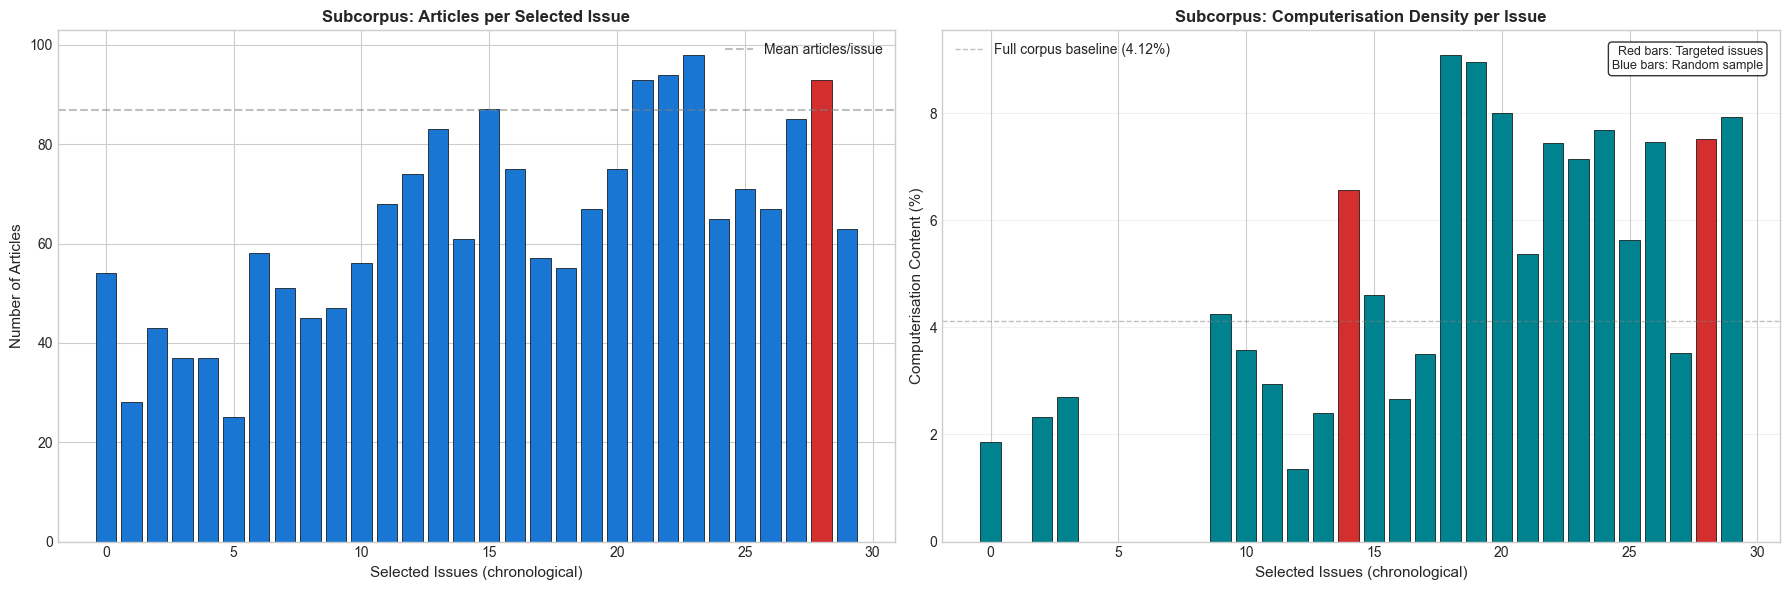

In [9]:
# Visualize subcorpus selection strategy
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Left: Articles per selected issue
issue_groups = subcorpus.groupby(['Year', 'Ausgabe']).size().reset_index(name='article_count')
issue_groups['label'] = issue_groups['Year'].astype(str) + '/' + issue_groups['Ausgabe'].astype(str)
issue_groups = issue_groups.sort_values('Year')

# Color targeted issue differently
colors = ['#D32F2F' if (row['Year'] == 1978 and row['Ausgabe'] == 16)
          else '#1976D2' for _, row in issue_groups.iterrows()]

axes[0].bar(range(len(issue_groups)), issue_groups['article_count'], color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_xlabel('Selected Issues (chronological)', fontsize=11)
axes[0].set_ylabel('Number of Articles', fontsize=11)
axes[0].set_title('Subcorpus: Articles per Selected Issue', fontsize=12, fontweight='bold')
axes[0].axhline(y=subcorpus.groupby('Ausgabe').size().mean(), color='gray',
                linestyle='--', alpha=0.5, label='Mean articles/issue')
axes[0].legend()

# Right: Computerisation content density in selected issues
comp_density = subcorpus.groupby(['Year', 'Ausgabe']).agg({
    'has_computerisation': 'sum',
    'Artikeltitel': 'count'
}).reset_index()
comp_density['comp_percentage'] = (comp_density['has_computerisation'] / 
                                    comp_density['Artikeltitel'] * 100)
comp_density = comp_density.sort_values('Year')

# Color the specifically-selected issues differently
colors = ['#D32F2F' if (row['Year'] in [1964, 1978]) 
          else '#00838F' for _, row in comp_density.iterrows()]

axes[1].bar(range(len(comp_density)), comp_density['comp_percentage'], 
            color=colors, edgecolor='black', linewidth=0.5)
axes[1].set_xlabel('Selected Issues (chronological)', fontsize=11)
axes[1].set_ylabel('Computerisation Content (%)', fontsize=11)
axes[1].set_title('Subcorpus: Computerisation Density per Issue', fontsize=12, fontweight='bold')
axes[1].axhline(y=4.12, color='gray', linestyle='--', linewidth=1,
                alpha=0.5, label='Full corpus baseline (4.12%)')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# Add note about targeted issues
axes[1].text(0.98, 0.97, 'Red bars: Targeted issues\nBlue bars: Random sample',
             transform=axes[1].transAxes, fontsize=9,
             verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()


## **2.7 Two Metaquestions**

As introduced previously, our analysis focuses on two interrelated metaquestions that operate at the level of discourse patterns rather than individual factual claims. We will now define these more clearly for our investigation.

**Metaquestion 1: Terminology Evolution**  
How did the language used to describe computerisation and automation shift across the thirty-year period? Therefore, we track the trajectory of related terms, examining not just frequency changes but *contextual patterns*. When and in what types of articles did each term predominate? How did terminology vary between coverage foci? Did Leserbriefe adopt editorial terminology or develop distinct vocabularies?

**Metaquestion 2: Hopes and Fears Discourse**
How did public discourse about computerisation and automation's consequences evolve from early euphoria to later anxieties? Schuhmann (<cite data-cite="schuhmann2012TraumVomPerfekten"></cite>) identifies a shift from celebration of the "perfekten Unternehmen" in the 1950s-60s to fears about unemployment and social disruption in the 1970s. Is this shift reflected in *Der Spiegel*? Was the shift gradual or punctuated by specific events (oil crisis, rising unemployment)? How did fears about automation relate to broader economic concerns? Crucially, did reader letters reflect, anticipate, or resist editorial framing?

Both metaquestions demand analysis across the complete corpus, including articles where computerisation appears as a secondary theme rather than primary topic. They require distinguishing between different discourse contexts (business reporting, political commentary, cultural features) and comparing editorial and reader voices. Traditional archival research excels at deep analysis of selected key texts but cannot systematically track patterns across such scale. DH 1.0 methods could identify frequency patterns and co-occurrences but have limited ability to interpret the context of usage. This is precisely where our RAG system promises value. But only if designed to preserve rather than bypass the critical practices of source evaluation and interpretive authority that define historical scholarship.

# 3. Building a RAG Pipeline

Having established our research questions and corpus, we now turn to the technical infrastructure that will enable semantic-based searching across over 100,000 articles. This section introduces the core components of a Retrieval-Augmented Generation (RAG) pipeline, including chunking texts into retrievable units, embedding them as vectors, and storing them for similarity search. While these are standard components in any RAG system, our presentation emphasises the choices available in each step and aims to highlight the decisions being made and their effect on usage. This reflects our conviction that methodological choices are never merely technical. They embed theoretical assumptions that shape what becomes visible and what remains obscured. The choices available (although not always available to users, instead being made without user knowledge by other actors such as data, cloud or API providers) carry consequences for research processes. By addressing some of the most important of these decisions through the context of historical research we aim to foreground the choices being made. Choices that commercial RAG-applications (such as NotebookLM) often conceal. The goal is for users to be aware of the tools they use and encourage researchers to design their own RAG-applications to suit their research requirements.

To reiterate the construction of a RAG pipeline is not merely technical; it is an act of scholarly mediation. Each component (how we divide texts, how we represent meaning numerically, how we measure similarity) embeds assumptions about what constitutes relevance and relationship. Following Agre's (1998) call for Critical Technical Practice, we approach these technical choices as sites requiring explicit methodological reflection. The goal is not to optimise for benchmark performance, but to design infrastructure that preserves historians' epistemological agency and interpretive authority while enabling computational scale.

## 3.1 Grounding Generation in Sources

RAG emerged as a response to fundamental limitations of Large Language Models. While LLMs generate fluent text, their knowledge is encoded implicitly in neural network weights, they cannot cite sources, easily update their knowledge, or explain why they produced a particular response. Lewis et al. (<cite data-cite="lewis2020RetrievalAugmentedGenerationKnowledgeIntensive"></cite>) introduced RAG as an architecture that combines "parametric memory" (what the model learned during training) with "non-parametric memory" (an external, searchable knowledge base). This separation is crucial because rather than asking the model to recall facts from training, RAG retrieves relevant documents and provides them as context for generation.

The basic RAG workflow operates in three stages. First, when a user submits a query, the system converts it into a numerical vector (an "embedding") that encodes, to a certain extent, its semantic meaning. Second, this query vector is compared against pre-computed vectors for all documents in the knowledge base, retrieving those most similar to the query. Third, the retrieved documents are provided as context to an LLM along with the original query, and the model generates a response grounded in these specific sources. This architecture enables LLM generated answers more grounded in the relevant sources than would be possible for models operating from parametric memory alone.

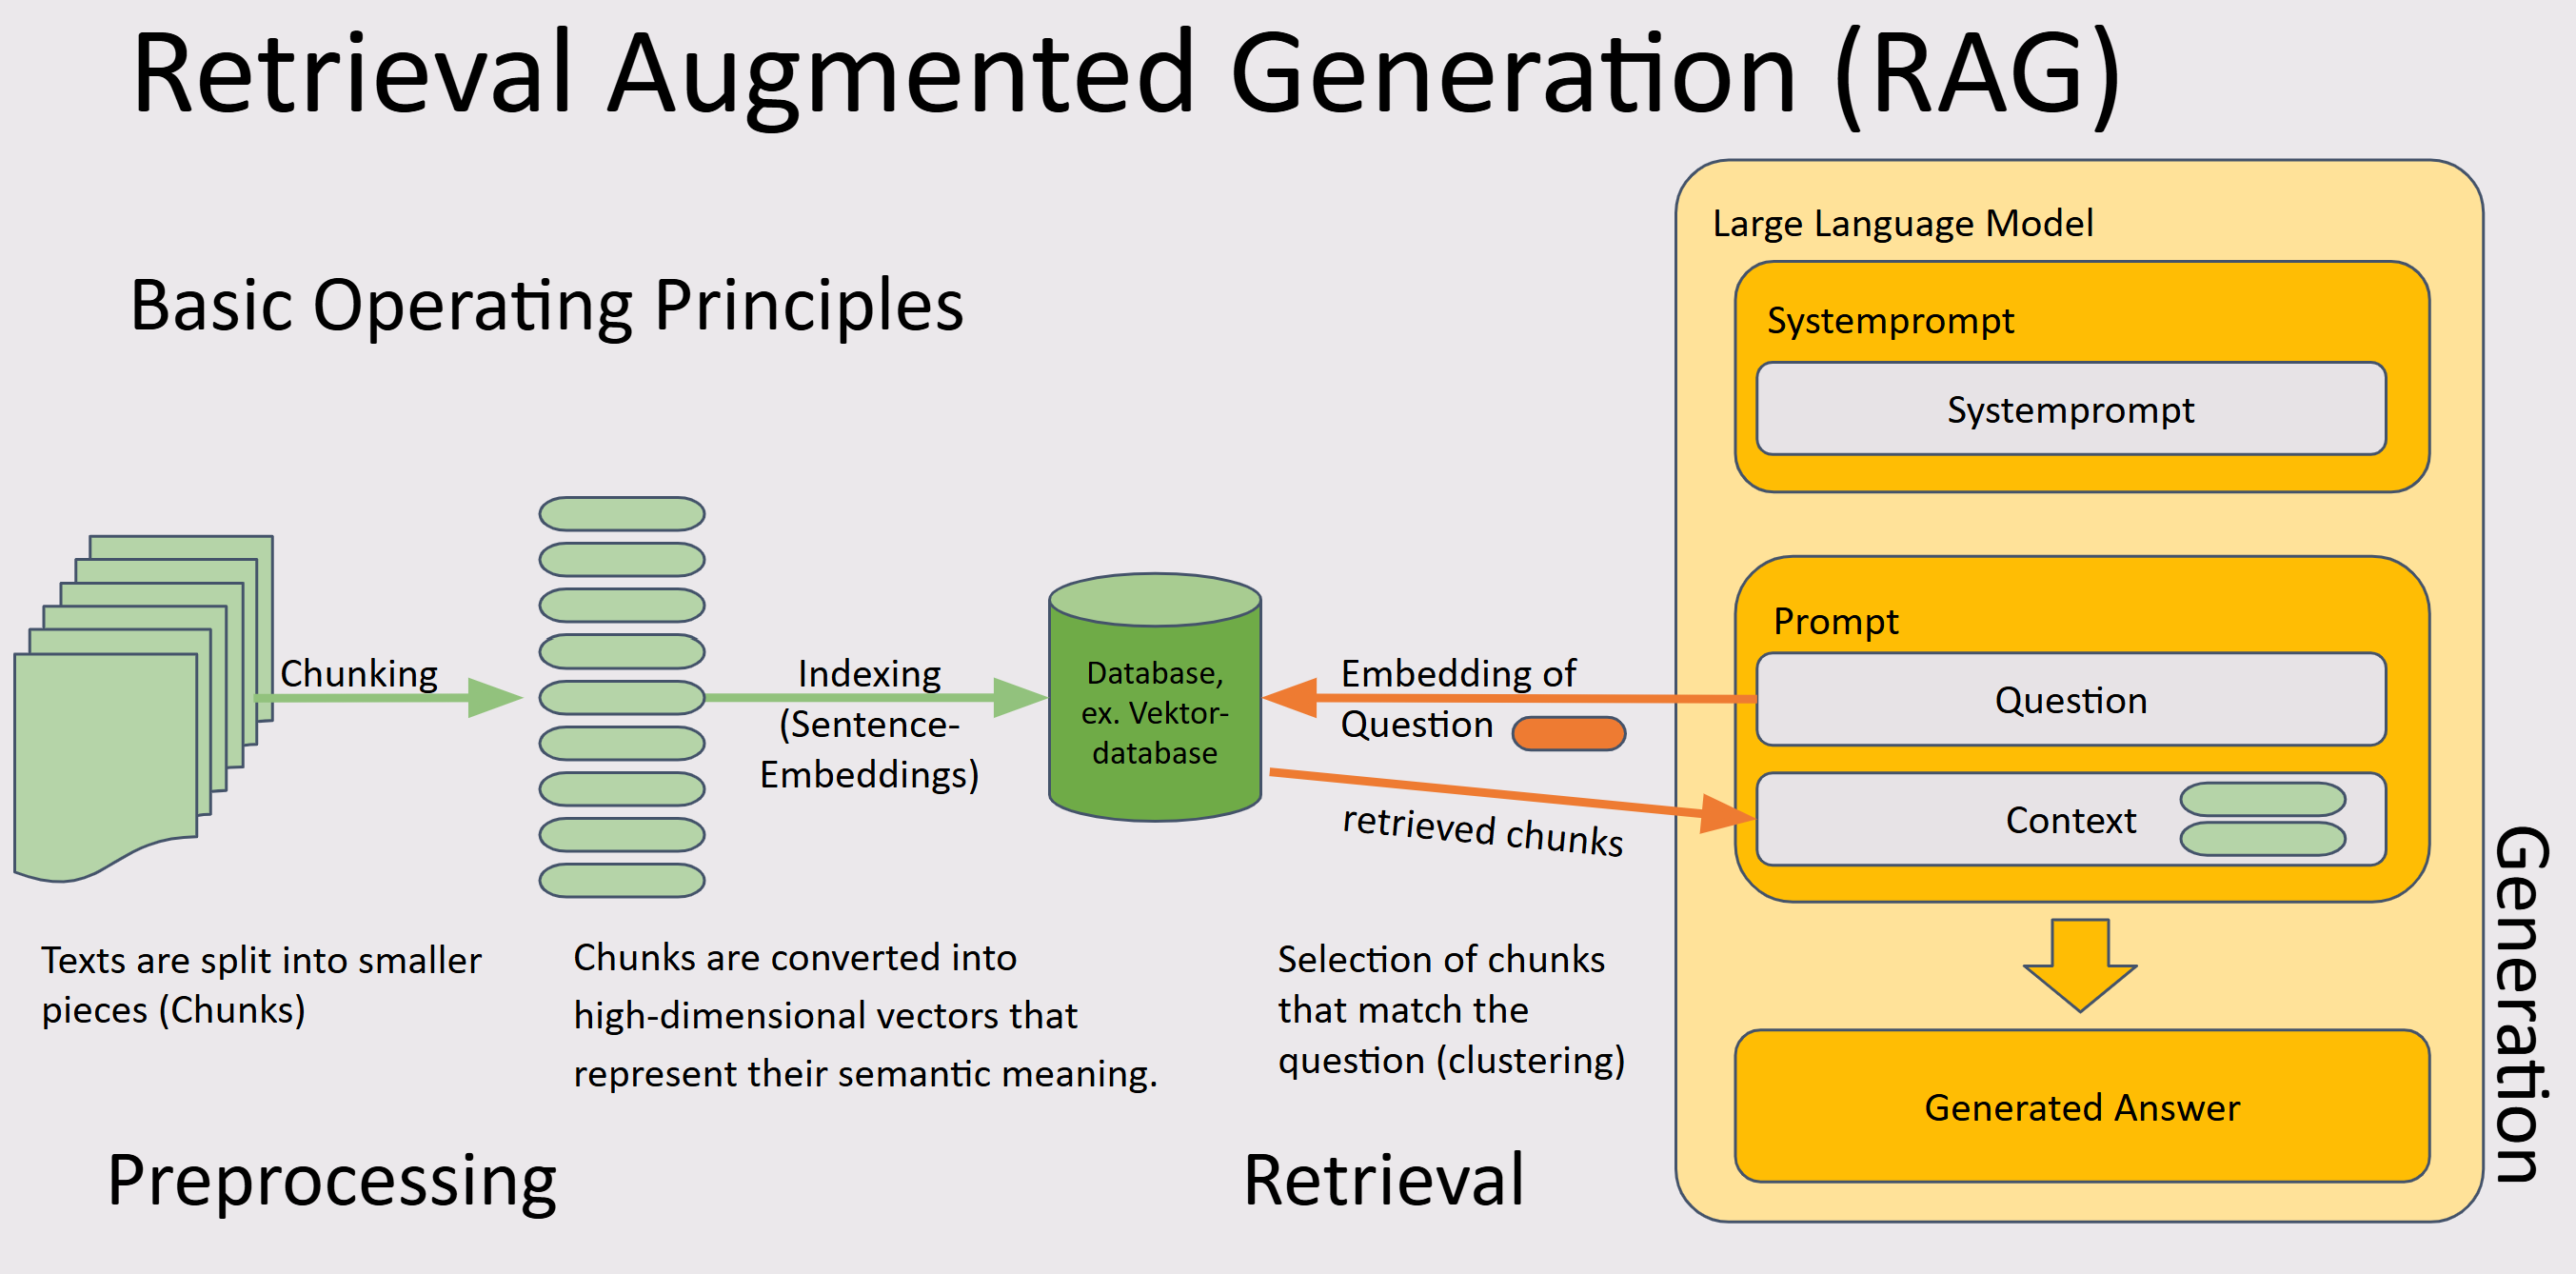

In [10]:
from IPython.display import Image, display
metadata={
    "jdh": {
        "module": "object",
        "object": {
            "type": "image",
            "source": [
                "[Visualisation of basic components of RAG systems including Preprocessing, Retrieval and Generation]"
            ]
        }
    }
}
display(Image("media/basic-operating-principles.png"), metadata=metadata)

Today, most LLM platforms include elements of RAG already, through internet searches, project knowledge or uploaded documents, the information provided to the LLM as context is enhanced for improved answers. But, importantly, control in these platforms is limited — a direct challenge to the epistemic agency we argued for above. This integration increases accessibility but obscures the decisions being made; which sources are retrieved, how relevance is measured, what context reaches the model. This is even more the case for agentic workflows, as we hope to show, while agents are useful tools and definitively part of LLM usage, users must be aware of the opaqueness of all LLM-systems they are using. By handing over epistemological agency to black-box systems, we risk losing sight of how knowledge is constructed and thereby losing its value.

## 3.2 Chunking: Dividing Texts for Retrieval

Before texts can be embedded and searched, they must be divided into retrievable units. This process, known as chunking, presents a trade-off: smaller chunks enable more precise retrieval but risk losing contextual coherence, while larger chunks preserve context but may bury relevant passages within irrelevant material. This trade-off is also model-dependent in two respects: embedding models impose maximum input lengths that constrain chunk size, and the generation models that later process retrieved chunks vary in their context windows. Larger windows reduce the penalty of including broader chunks, since more of them can be considered simultaneously.

In [11]:
subcorpus['Text'] = subcorpus['Text'].fillna('')

print(f"Working with {len(subcorpus):,} articles from {subcorpus['issue_id'].nunique()} issues")
print(f"Years covered: {subcorpus['Year'].min()} - {subcorpus['Year'].max()}")
print(f"Character count range: {subcorpus['char_count'].min():,} - {subcorpus['char_count'].max():,}")
print(f"Mean article length: {subcorpus['char_count'].mean():,.0f} characters")

Working with 1,912 articles from 30 issues
Years covered: 1950 - 1979
Character count range: 0 - 84,450
Mean article length: 5,097 characters


Several chunking strategies exist, each with distinct implications.

- **Fixed-size chunking** divides text at regular character or word intervals regardless of content. While computationally simple, this approach may split sentences mid-thought or separate closely related passages.
- **Recursive character chunking** attempts to split at natural boundaries (paragraph breaks, sentence ends) while respecting size constraints. When a chunk exceeds the target size, the algorithm recursively applies smaller separators until the constraint is met. Difficulties exist where texts are non-conform either as a result of text type or limited OCR. In these instances natural boundaries might be non-standardised over the corpora and not indicative of natural boundaries.
- **Semantic chunking** uses embedding similarity between adjacent sentences to identify natural topic boundaries, splitting where semantic distance exceeds a threshold. However, recent research suggests this computational overhead may not be justified, Qu et al. (<cite data-cite="qu2024SemanticChunkingWorth"></cite>) found that semantic chunking's benefits were "highly context-dependent and did not consistently justify the additional computational cost," with fixed-size chunking often performing comparably on real-world documents.

In our corpus, the natural unit of meaning is the individual article. Ideally, each article would be embedded and retrieved as a whole, preserving its full argumentative structure. In practice, however, many articles exceed the input limits of embedding models, making subdivision necessary. The goal of chunking is therefore to divide articles into retrievable units while preserving as much of their internal coherence as possible. We experimented with aligning chunk boundaries to actual article lengths so that shorter articles could remain intact, but ultimately adopted recursive character chunking as a more generalisable approach that balances respect for textual structure against computational efficiency and worked well across the range of article lengths in our corpus. Crucially, SPIEGELragged offers users three pre-configured chunking sizes, enabling researchers to select the granularity appropriate to their research question:

- **Large chunks (3000/300)**: 3000 characters with 300-character overlap, preserving extended argumentative passages — sufficient to contain many shorter articles whole
- **Medium chunks (2000/200)**: 2000 characters with 200-character overlap, balancing context and precision
- **Small chunks (500/50)**: 500 characters with 50-character overlap, enabling fine-grained retrieval at the cost of losing broader context

This configurability reflects a core design principle: there is no universally optimal chunk size. Certain questions may benefit from larger chunks that preserve argumentative flow, while searches for specific terminology or quotations may require smaller, more precise units.

We will now dive into chunking and its effects on retrieval a bit deeper by chunking our subcorpus in three different configurations and comparing retrieval similarity across all three.

In [12]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Define our three chunking configurations as offered in SPIEGELragged
chunking_configs = {
    'large': {'chunk_size': 3000, 'chunk_overlap': 300},
    'medium': {'chunk_size': 2000, 'chunk_overlap': 200},
    'small': {'chunk_size': 500, 'chunk_overlap': 50}
}

# Sentence boundary regex for German text: splits at sentence-ending punctuation
# followed by a new sentence, while avoiding false splits at abbreviations
# (e.g. "Dr.", "z.B.", "Mio. DM") by requiring at least two preceding lowercase chars
german_sentence_boundary = (
    r"(?<=[A-Z\u00d6\u00dc\u00c4a-z\u00e4\u00f6\u00fc\u00df]"
    r"[a-z\u00e4\u00f6\u00fc\u00df][.!?])\s+"
    r"(?=[A-Z\u00d6\u00c4\u00dc][a-z\u00e4\u00f6\u00fc\u00df])"
    r"|"
    r"(?<=[a-z][.!?]\u00ab)\s+"
    r"(?=[A-Z\u00d6\u00c4\u00dc][a-z\u00e4\u00f6\u00fc\u00df])"
)

# Create splitters for each configuration
splitters = {}
for name, config in chunking_configs.items():
    splitters[name] = RecursiveCharacterTextSplitter(
        chunk_size=config['chunk_size'],
        chunk_overlap=config['chunk_overlap'],
        is_separator_regex=True,
        separators=[
            r"\n\n",                   # Paragraph breaks
            r"\n",                      # Line breaks
            german_sentence_boundary,    # Sentence boundaries (abbreviation-aware)
            r"\s",                      # Whitespace
            r""                          # Fallback: character-level
        ]
    )

print("Chunking configurations initialised:")
for name, config in chunking_configs.items():
    print(f"  {name}: {config['chunk_size']} chars, {config['chunk_overlap']} overlap")

Chunking configurations initialised:
  large: 3000 chars, 300 overlap
  medium: 2000 chars, 200 overlap
  small: 500 chars, 50 overlap


In [13]:
# Select a longer article about computerisation for demonstration
computerisation_articles = subcorpus[
    (subcorpus['has_computerisation'] == True) &
    (subcorpus['char_count'] > 5000)
].copy()

if len(computerisation_articles) > 0:
    sample_article = computerisation_articles.iloc[0]
    sample_text = sample_article['Text']

    print(f"Sample article: '{sample_article['Artikeltitel']}'")
    print(f"Year: {sample_article['Year']}, Issue: {sample_article['Ausgabe']}")
    print(f"Length: {len(sample_text):,} characters")
    print("\n" + "="*60)

    # Apply each chunking strategy
    chunk_results = {}
    for name, splitter in splitters.items():
        chunks = splitter.split_text(sample_text)
        chunk_results[name] = chunks
        avg_len = sum(len(c) for c in chunks) / len(chunks) if chunks else 0
        print(f"\n{name.upper()} chunking: {len(chunks)} chunks (avg {avg_len:.0f} chars)")
        if chunks:
            print(f"  Second chunk preview: '{chunks[1][:100]}...'")
else:
    print("No suitable computerisation articles found in subcorpus")
    # Use any long article as fallback
    sample_article = subcorpus[subcorpus['char_count'] > 5000].iloc[0]
    sample_text = sample_article['Text']
    chunk_results = {name: splitter.split_text(sample_text) for name, splitter in splitters.items()}

Sample article: 'Einzug der Roboter'
Year: 1964, Issue: 14
Length: 56,633 characters


LARGE chunking: 21 chunks (avg 2884 chars)
  Second chunk preview: 'Seine Spitzenverdiener können ohnehin nirgends zupacken. Die Buna-Fabrik der Chemische Werke Hüls AG...'

MEDIUM chunking: 31 chunks (avg 1916 chars)
  Second chunk preview: 'Kurt Pentzlin, 61, einer der angesehensten Rationalisierungsfachleute Westdeutschlands. »Was wir bra...'

SMALL chunking: 144 chunks (avg 395 chars)
  Second chunk preview: 'Der Arbeiter, der die Automatik auslöst, weiß nicht einmal, welchen Kuchen er gerade herstellt. Er w...'


To demonstrate how chunk size affects retrieval, we apply text-embedding (a technique we introduce in more detail in section 3.3 below, but which is fundamentally different from word embeddings in its complexity and creation process) to convert these chunks into numerical vectors and compare search results for a query relevant to our metaquestions:

In [14]:
# Load pre-computed embeddings (generated locally with all-MiniLM-L6-v2)
import json

with open('script/chunk_analysis.json', 'r', encoding='utf-8') as f:
    chunk_analysis = json.load(f)

query = "Arbeitslosigkeit durch Automatisierung und Computer"
print(f"Query: '{query}'\n")
print("="*80)

for name, data in chunk_analysis.items():
    similarities = np.array(data['similarities'])
    top_indices = np.argsort(similarities)[-3:][::-1]
    
    print(f"\n{name.upper()} CHUNKING - Top 3 matches:")
    print("-"*60)
    for rank, idx in enumerate(top_indices, 1):
        preview = data['chunks'][idx][:120].replace('\n', ' ')
        print(f"  {rank}. Score: {similarities[idx]:.4f}")
        print(f"     '{preview}...'")

Query: 'Arbeitslosigkeit durch Automatisierung und Computer'


LARGE CHUNKING - Top 3 matches:
------------------------------------------------------------
  1. Score: 0.5158
     '. Wie wenig Bonn und die Bosse bislang den sozialen und wirtschaftlichen Gefahren der Automatisierung konfrontiert wurde...'
  2. Score: 0.4996
     '. Der Automationsexperte der IG Metall Dr. Günter Friedrichs (siehe SPIEGEL-Gespräch Seite 51) fürchtet denn auch zu Rec...'
  3. Score: 0.4724
     '. Während sich die Textil-Industriellen noch zu keinerlei Zugeständnissen an freigesetzte Weber und Spinner bereit fande...'

MEDIUM CHUNKING - Top 3 matches:
------------------------------------------------------------
  1. Score: 0.5454
     '. »Ich bedaure den Verlust der Geschicklichkeit und des beruflichen Könnens in der Arbeit«, schrieb der Harvard-Professo...'
  2. Score: 0.5235
     '. Die Bundesregierung hingegen sah keinerlei Veranlassung, auch nur einem einzigen Beamten ähnliche Einblicke zu verscha...'

The retrieval results confirm the suspected pattern that smaller chunks yield higher similarity scores. This is not altogether surprising, a 500-character chunk discussing automation fears will geometrically align more closely with our query than a 3000-character chunk where the same passage appears alongside more text or even other topics. Yet it is slightly surprising since our news articles are assumed to be topically coherent meaning that larger chunks should not include too many distinct topics. 

However, higher similarity scores do not necessarily indicate better retrieval for historical research. Consider what the top results actually contain. The small-chunk results isolate precise statements about automation anxiety, but strip them of argumentative context. The large-chunk results embed these statements within broader discussions of industrial policy, labour relations, and technological change. This is context that may be essential for understanding how fears were framed and contested. The "best" retrieval depends on what we intend to do with the results. To explore this trade-off further, we examine the full distribution of similarity scores across all chunks, not just the top matches:

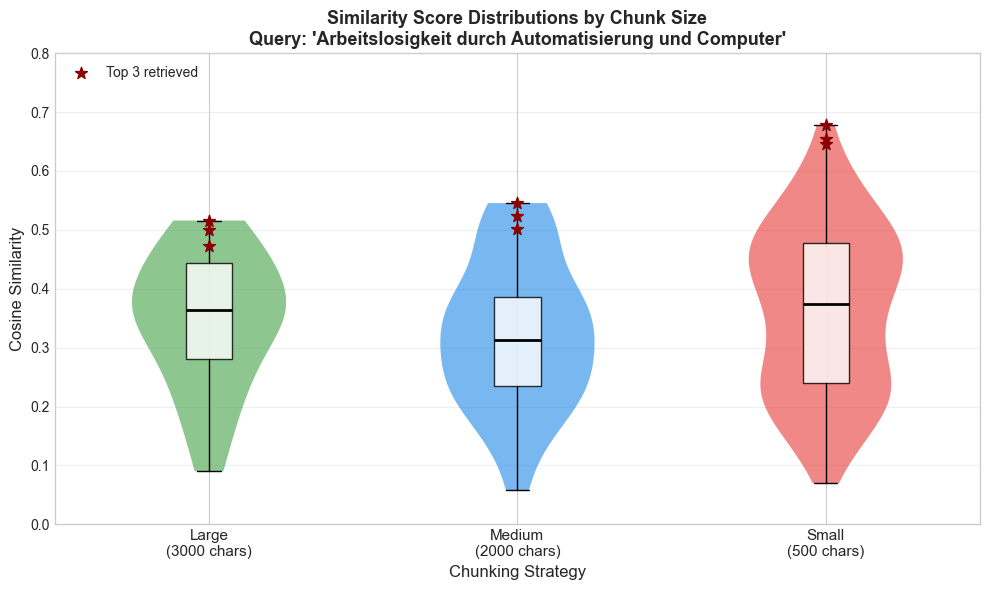


Summary Statistics:
----------------------------------------------------------------------
Strategy   Chunks     Mean       Std        Max        Top-3 Avg 
----------------------------------------------------------------------
large      21         0.3449     0.1112     0.5158     0.4959    
medium     31         0.3240     0.1211     0.5454     0.5236    
small      144        0.3641     0.1424     0.6774     0.6594    


In [15]:
# Prepare data for violin plot
plot_data = []
for name, data in chunk_analysis.items():
    config = data['config']
    for sim in data['similarities']:
        plot_data.append({
            'Strategy': f"{name.capitalize()}\n({config['chunk_size']} chars)",
            'Similarity': sim,
            'strategy_order': config['chunk_size']
        })

plot_df = pd.DataFrame(plot_data)
plot_df = plot_df.sort_values('strategy_order', ascending=False)  # Large -> Medium -> Small

fig, ax = plt.subplots(figsize=(10, 6))

# Create violin plot
strategies = plot_df['Strategy'].unique()
positions = range(len(strategies))
colors = ['#43A047', '#1E88E5', '#E53935']  # Large=green, Medium=blue, Small=red

for i, strategy in enumerate(strategies):
    data = plot_df[plot_df['Strategy'] == strategy]['Similarity'].values

    # Violin
    parts = ax.violinplot([data], positions=[i], showmeans=False, showmedians=False, showextrema=False)
    for pc in parts['bodies']:
        pc.set_facecolor(colors[i])
        pc.set_alpha(0.6)

    # Box plot overlay for quartiles
    bp = ax.boxplot([data], positions=[i], widths=0.15, patch_artist=True,
                    showfliers=False, zorder=3)
    bp['boxes'][0].set_facecolor('white')
    bp['boxes'][0].set_alpha(0.8)
    bp['medians'][0].set_color('black')
    bp['medians'][0].set_linewidth(2)

    # Mark top-3 scores
    top_3 = np.sort(data)[-3:]
    ax.scatter([i]*3, top_3, color='darkred', s=80, zorder=5,
               marker='*', label='Top 3 retrieved' if i == 0 else None)

ax.set_xticks(positions)
ax.set_xticklabels(strategies, fontsize=11)
ax.set_ylabel('Cosine Similarity', fontsize=12)
ax.set_xlabel('Chunking Strategy', fontsize=12)
ax.set_title(f"Similarity Score Distributions by Chunk Size\nQuery: '{query}'",
             fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 0.8)

plt.tight_layout()
plt.show()

# Summary statistics table
print("\nSummary Statistics:")
print("-" * 70)
print(f"{'Strategy':<10} {'Chunks':<10} {'Mean':<10} {'Std':<10} {'Max':<10} {'Top-3 Avg':<10}")
print("-" * 70)
for name, data in chunk_analysis.items():
    sims = data['similarities']
    top_3_avg = np.mean(np.sort(sims)[-3:])
    print(f"{name:<10} {len(data['chunks']):<10} {np.mean(sims):<10.4f} {np.std(sims):<10.4f} {np.max(sims):<10.4f} {top_3_avg:<10.4f}")

The violin plot confirms the pattern, but shows nuance in the results. Smaller chunks produce higher similarity scores as well as greater variance, while larger chunks yield lower and more tightly clustered scores. The wider distribution for small chunks reflects greater distinctiveness. Tightly focused chunks score either very high (when closely matching the query) or very low (when the narrow content diverges), producing a more polarised distribution. 

This trade-off between precision and context cannot be resolved algorithmically, it requires reflection on research goals. For our hopes-and-fears metaquestion, we might prefer larger chunks that preserve how fears were framed and contested rather than smaller chunks that isolate individual anxious statements. For terminology tracking, smaller chunks might better capture precise usage patterns, though they too require sufficient surrounding context for meaningful interpretation. The 'best' retrieval is always relative to interpretive purpose.

Therefore in SPIEGELragged, we aim to preserve this choice as an explicit research decision. Users select their preferred chunking configuration at the start of a session, with the understanding that this shapes the subsequent retrieval landscape. This transparency contrasts with commercial RAG systems that hide such decisions behind seamless interfaces.

## 3.3 Embedding: Representing Text as Vectors

For the preceding experiment comparing chunking sizes, we already applied text embedding to evaluate retrieval quality. We now introduce this technique more precisely. In Section 2.6, we used word embeddings (FastText) to explore the vocabulary of our corpus. Text embedding extends this principle from single words to variable-length passages. A sentence, a paragraph, or an entire chunk is transformed into a single fixed-dimensional vector where geometric proximity corresponds to semantic similarity. The term "sentence embedding" is sometimes used synonymously, originating with models like Sentence-BERT, though "text embedding" more accurately describes what we do when embedding multi-paragraph chunks. 

As Simons et al. (<cite data-cite="simons2025LargeLanguageModelsa"></cite>) emphasise, these representations are not neutral: "Rather than merely discovering relationships, text embedding models *construct* them, guided by technical choices about similarity, relevance, and relatedness" (p. 8). The assumptions embedded in model architecture and training data carry interpretive consequences that shape what becomes visible in retrieval.

Embedding model selection deserves careful consideration in any RAG project. Key factors include:

- **Training objective**: Embedding models are trained for different tasks, some optimise for semantic similarity (finding texts that resemble the query), others for question-answer retrieval (finding texts that respond to the query). This distinction matters for historical research as searching for "hopes and fears about computerisation" could prioritise texts using similar vocabulary or texts containing relevant information, depending on the model's training. Some models, including the nomic models we employ, use task-specific prefixes to switch between retrieval modes.
- **Multilingual capability**: Does the model handle your corpus's language adequately? Models trained primarily on English may underperform on other languages, particularly historical varieties.
- **Context window**: Can the model process your chosen chunk sizes without truncation? Exceeding the context limit silently discards text.
- **Dimensionality**: Higher-dimensional embeddings (768 vs. 384) capture more nuanced semantic distinctions but require more storage and computation.
- **Practical constraints**: Cost, inference speed, and infrastructure requirements matter for sustainable projects.
- **Transparency**: Open-weight models allow inspection of training data and architecture; proprietary alternatives obscure these choices.

For SPIEGELragged, we initially deployed nomic-embed-text (<cite data-cite="nussbaum2025NomicEmbedTraining"></cite>), an open-source model with 768-dimensional embeddings, an 8192-token context window accommodating our larger chunks, and task-specific prefixes that distinguish queries from documents. The model processed our 1950-1979 German-language corpus effectively, though it was primarily trained on English with multilingual fine-tuning.

Subsequently, we migrated to nomic-embed-moe-v2 (<cite data-cite="nussbaum2025TrainingSparseMixture"></cite>), the first general-purpose Mixture-of-Experts (MoE) text embedding model. MoE architectures address a tension relevant to RAG applications: larger models generally produce better embeddings, but their increased memory requirements and inference latency create practical constraints. MoE models achieve strong performance while activating only a subset of parameters during inference, maintaining competitive results with models twice their size. For our German-language corpus, nomic-embed-moe-v2 offered improved multilingual performance while reducing computational overhead.

We encourage researchers to treat embedding model selection as a methodological decision requiring explicit justification rather than accepting defaults. The model shapes what "similarity" means in your retrieval system. This is a choice with interpretive consequences that should be documented and defended. Other experiments with medieval Swiss German texts revealed significant limitations in handling historical language varieties, an area requiring further research as historians increasingly apply these methods to pre-modern sources.

In [ ]:
# Demonstrate embedding properties and semantic similarity
# sample_texts = [
#     "Computer revolutionieren die Bueroarbeit",  # Computers revolutionize office work
#     "Elektronengehirn uebernimmt Rechenaufgaben",  # Electronic brain takes over calculations
#     "Arbeiter fuerchten Rationalisierung",  # Workers fear rationalisation
#     "Das Wetter in Hamburg ist regnerisch"  # The weather in Hamburg is rainy (unrelated)
# ]

with open('script/embedding_demo.json', 'r', encoding='utf-8') as f:
    demo = json.load(f)

sample_texts = demo['texts']
sim_matrix = np.array(demo['sim_matrix'])

print("Embedding dimensionality:", demo['dimensionality'])
print("\nSemantic similarity between sample texts:")
print("-" * 60)

reference_text = sample_texts[0]
print(f"\nReference: '{reference_text}'\n")
for j in range(1, len(sample_texts)):
    print(f"  → '{sample_texts[j]}': {sim_matrix[0][j]:.3f}")

Embedding dimensionality: 384

Semantic similarity between sample texts:
------------------------------------------------------------

Reference: 'Computer revolutionieren die Bueroarbeit'

  → 'Elektronengehirn uebernimmt Rechenaufgaben': 0.432
  → 'Arbeiter fuerchten Rationalisierung': 0.389
  → 'Das Wetter in Hamburg ist regnerisch': 0.230


Having embedded all chunks with the chosen embedding model, the results of the similarity scoring show both the power and limitations of embedding-based retrieval. The cosine similarity scores range from 0.23-0.43. While this might seem low, these are actually typical and expected for sentence embeddings. Sentence embeddings capture nuanced meaning, unlike word embeddings where "king" and "queen" might score 0.8+, sentence embeddings encode the entire semantic context of a sentence, making exact matches rare. Additionally, our two sentences that we expect to be most related: "Computer revolutionieren die Bueroarbeit" and "Elektronengehirn uebernimmt Rechenaufgaben" are conceptually related but use entirely different terminologies. Our model choice also plays a role, both the low dimensionality (384 dimensions) and the training of this model result in unique scores that would be different with other embedding models.

Far more important than the numerical values is the ranking of similarity. The key insight is that semantically related sentences (0.39-0.43) score significantly higher than the unrelated weather sentence (0.23). This ranking is what enables effective retrieval. The probability that all substantially relevant chunks are among the top results is high, particularly since our research questions seek patterns across many texts rather than individual singular passages.

Furthermore, the model itself cannot interpret between neutral description ("Computer revolutionieren die Bueroarbeit") and anxious framing ("Arbeiter fuerchten Rationalisierung"). This is a distinction crucial for our hopes-and-fears metaquestion and precisely why retrieval is only the first step in our methodology.

We invite further research into embedding model performance on historical language varieties. Our 1950s-1970s corpus uses modern standard German and presented no significant issues. However, experiments with other texts such as medieval documents, dialectal sources, or texts with substantial orthographic variation revealed significant limitations. This remains an open question with important implications for Digital History practice, particularly as researchers increasingly apply these methods to pre-modern sources.

## 3.4 Vector Storage and Retrieval

Having chunked our corpus, we now embed all chunks using our chosen model, transforming each text segment into a 768-dimensional vector. At medium chunking settings, the full *Der Spiegel* corpus produces approximately 200,000 chunks. This is a substantial computational step, but one that needs to be performed only once (or repeated when changing embedding models or chunking parameters). The resulting vectors must then be stored in infrastructure that allows efficient similarity search. When a user submits a query, the system must find the most similar vectors among these 200,000 candidates, ideally in milliseconds rather than minutes.

A naive approach would compare the query vector against every stored vector, calculating 200,000 similarity scores and returning the highest. This works for small collections but becomes impractical at scale. Vector databases solve this problem through approximate nearest neighbour (ANN) algorithms that trade perfect accuracy for dramatic speed improvements. The key insight is that we do not need to find the *exact* most similar vectors, instead finding vectors that are very *likely to be* among the most similar is sufficient. The probability of missing a genuinely relevant result is very low, and for our purposes the slight imprecision is inconsequential, as we are searching for discourse patterns across many texts, not for individual singularities. If an approximate search misses one relevant chunk among dozens, the broader pattern remains intact.

We employ ChromaDB as our vector store, configured with the HNSW (Hierarchical Navigable Small World) algorithm. HNSW works by building a network of connections between similar vectors, organised in layers. Searching this network is like navigating a city, you start on a "highway" layer with long-distance connections that quickly get you to the right neighbourhood, then descend to "local streets" for fine-grained navigation to your destination. This structure means search time grows slowly even as the collection expands. Searching 200,000 vectors takes only marginally longer than searching 20,000.

For measuring similarity between vectors, we use cosine similarity, which calculates the angle between two vectors in high-dimensional space. Vectors pointing in similar directions (small angle) are considered semantically similar; vectors pointing in different directions (large angle) are dissimilar. This metric is standard for text embeddings, though recent research notes limitations. You (<cite data-cite="you2025SemanticsAngleWhen"></cite>) demonstrates that high-dimensional spaces exhibit counterintuitive properties where many vectors appear moderately similar to any given query, potentially obscuring meaningful distinctions. These technical caveats reinforce our approach of treating retrieval results as candidates for further evaluation rather than as authoritative relevance judgments, and caution against the uncritical adoption of similarity scores as a measure of scholarly relevance.

The storage of metadata alongside vectors is essential for historical research. Each chunk in our database carries its provenance: article title, publication date, issue number, and URL to the original source. This enables filtering by temporal range, sorting results chronologically, and crucially tracing any retrieved passage back to the article it originates from. The vector database serves not as a black box but as an indexed, queryable representation of our corpus that preserves the citability fundamental to historical scholarship.

In [17]:
# Demonstrate document preparation for vector storage
# In production, this connects to ChromaDB via LangChain

from langchain_core.documents import Document

def prepare_documents(df, splitter, max_articles=50):
    """Convert dataframe articles to LangChain Documents with metadata."""
    documents = []
    for idx, row in df.head(max_articles).iterrows():
        text = str(row['Text'])
        if not text or text == 'nan':
            continue
        chunks = splitter.split_text(text)
        for i, chunk in enumerate(chunks):
            doc = Document(
                page_content=chunk,
                metadata={
                    'Artikeltitel': row['Artikeltitel'],
                    'Datum': str(row['Datum']),
                    'Year': int(row['Year']),
                    'Ausgabe': int(row['Ausgabe']),
                    'URL': row['URL'],
                    'chunk_index': i,
                    'total_chunks': len(chunks),
                    'has_computerisation': bool(row.get('has_computerisation', False))
                }
            )
            documents.append(doc)
    return documents

# Prepare a sample for demonstration
docs = prepare_documents(subcorpus, splitters['medium'], max_articles=50)
print(f"Prepared {len(docs)} document chunks from 50 articles")
print(f"\nSample document metadata:")
for key, value in docs[0].metadata.items():
    print(f"  {key}: {value}")

Prepared 202 document chunks from 50 articles

Sample document metadata:
  Artikeltitel: Einzug der Roboter
  Datum: 1964-03-31 00:00:00
  Year: 1964
  Ausgabe: 14
  URL: https://www.spiegel.de/politik/einzug-der-roboter-a-ec698c0f-0002-0001-0000-000046173388?context=issue
  chunk_index: 0
  total_chunks: 31
  has_computerisation: True


## 3.5 Where Standard RAG Falls Short for Historical Research

The pipeline we have described (chunking, embedding, vector storage, similarity search) constitutes the standard RAG architecture. Since Lewis et al.'s (2020) foundational work, research on RAG has expanded considerably. Huang and Huang (<cite data-cite="huang2024SurveyRetrievalAugmentedText"></cite>) organise the field into four phases: pre-retrieval (how documents are indexed and queries refined), retrieval (the search and ranking process), post-retrieval (filtering and reordering results), and generation (how the LLM produces output). Most enhancements focus on improving retrieval accuracy for question-answering tasks (finding the single best passage to answer a factual query).

Within Digital History, researchers have begun adapting RAG for domain-specific needs. Murugaraj et al. (<cite data-cite="murugaraj2025TopicRAGHistoricalNewspapers"></cite>) introduce Topic-RAG, which integrates topic modelling with retrieval to improve thematic coherence when searching historical newspaper archives. Their system uses BERTopic to identify relevant topics for a query, then restricts retrieval to documents within those topics. This represents a productive direction: rather than accepting generic RAG architectures, scholars are redesigning components around disciplinary requirements. Our approach shares this impulse but differs in strategy, as Topic-RAG aims to increase retrieval precision from the outset, accepting reduced recall as a trade-off, we prioritise broad recall first and refine precision in subsequent evaluation phases — producing a wider initial result set from which relevant passages are then identified through LLM-based assessment and historian review.

Historical research operates under different constraints than the question-answering tasks that drive most RAG development. Our metaquestions require not the single most relevant passage but comprehensive coverage across temporal periods. They demand attention to how relevance itself is constructed. What makes a source appropriate for answering questions about discourse evolution differs from what makes it appropriate for factual lookup. And they require interpretive evaluation that cannot be delegated to similarity metrics. Even the ordering of retrieved chunks carries methodological implications. Standard RAG pipelines present chunks ranked by relevance score, optimised for answering a question as efficiently as possible. For historical research, chronological ordering is often essential, since tracing how discourse develops over time requires sources to be encountered in their temporal sequence rather than sorted by computational relevance.

These tensions motivate the methodological innovations we introduce in the following sections. Rather than accepting standard RAG affordances, we redesign the architecture around historical research practices. Together, these interventions aim to uncover and to an extent recover our epistemological agency.

# 4. Separated Retrieval and Generation

Standard RAG systems flow seamlessly from query to retrieval to generation. A user's question triggers similarity search, and retrieved chunks feed directly into an LLM for response generation. This pipeline optimises for speed and convenience, but it conflates two distinct scholarly activities: finding relevant sources and asking questions of those sources.

Our system's architecture formally separates these phases through a two-tab interface: **Heuristik** (heuristics: retrieval and corpus construction) and **Analyse** (analysis: LLM-assisted interpretation). This separation computationally implements what historians do naturally. The heuristic phase of source discovery precedes and remains distinct from the interpretive engagement with assembled materials.

The term *Heuristik* deliberately invokes the systematic finding and gathering of sources relevant to a research question. Johann Gustav Droysen's *Historik* (1857) established heuristics as the foundational phase of historical inquiry. Before *Kritik*, i.e. source criticism, and *Interpretation* can begin, the historian must assemble a corpus of relevant materials. Standard RAG bypasses this phase entirely, treating source selection as a technical optimisation problem rather than a scholarly judgment. Users upload documents but make no decisions about which parts of these documents are included in the answering of their queries. Our separation restores this methodological distinction, which in standard RAG systems is usually collapsed into a single step.

The Heuristik tab encompasses both finding (similarity search, filtering) and evaluating potential relevance (metadata examination, relevance scoring, manual curation of the working corpus). The Analyse tab enables interpretation, the synthetic work of constructing meaning from assembled evidence.

## 4.1 Two Queries, Two Purposes

The critical architectural insight underlying this separation: the **retrieval query** and the **analysis question** serve fundamentally different purposes and need not (indeed, often should not) be identical. A distinction that standard RAG systems typically collapse, but that is essential in the broader setting of historical research.

The goal of the **retrieval query** is to cast a sufficiently broad net to find potentially relevant sources. To this end, it is converted to a text embedding and used for a similarity calculation against chunk embeddings in the vector database. Since embedding models are trained on natural language text (<cite data-cite="nussbaum2025NomicEmbedTraining"></cite>), effective retrieval queries are typically descriptive rather than interrogative: "West German media coverage of automation, computers, and technological unemployment 1950-1970" rather than "How did fears about automation change over time?" The descriptive formulation provides the embedding model with richer contextual information, producing vectors that better represent the intended search space. 

The **analysis question**, by contrast, is fed to the LLM along with the retrieved chunks. Its goal is to guide interpretation of the assembled sources. Analysis questions can be specific, comparative, or exploratory in ways that would be counterproductive for retrieval: "Compare how editorial content versus reader letters framed automation anxieties" or "Identify shifts in the vocabulary used to describe computers across these sources."

Consider how this distinction operates for our first metaquestion about terminology evolution. A researcher investigating how the language of computerisation shifted from "Elektronenhirn" to "Computer" to "EDV" would craft different queries for each phase:

- **Retrieval query**: "West German discourse on computing technology, electronic brains, data processing, and automation across popular media" — a natural language description designed to position the query embedding in the relevant region of semantic space, supplemented by keyword filters for specific terms like "Elektronenhirn," "Computer," or "EDV" to ensure lexical coverage.

- **Analysis question**: "Examine how the terminology used to describe computing technology shifts across these sources. When does 'Elektronenhirn' give way to 'Computer'? In what contexts does 'EDV' appear? Do different article types (business reporting, political commentary, reader letters) adopt new terminology at different rates?"

The retrieval query optimises for *coverage* — finding sources across the relevant semantic field. The analysis question optimises for *interpretation* — guiding the LLM toward the specific patterns the researcher seeks to understand. Conflating these into a single query would either narrow retrieval (missing sources that don't match the interpretive framing) or blur analysis (providing no guidance for how to read the assembled sources).

The separation mirrors traditional archival practice. A historian searching an archive catalogue for "Mauer Berlin 1961" will later ask very different questions of the assembled sources, questions about representation, rhetoric, comparison across source types, evolution of discourse. The archive search terms and the research questions operate in different registers. Our system's architecture preserves this distinction computationally.

## 4.2 The Heuristik Phase: Corpus Construction

The Heuristik tab provides researchers with granular control over the retrieval process. Rather than accepting whatever a similarity search returns, users are in the position to configure multiple parameters that shape their working subcorpus.

**Retrieval parameters include:**

- **Number of chunks**: How many results to retrieve (configurable from 1 to 50 for standard search, or per time window for interval-based search)
- **Keyword filtering**: Boolean expressions (AND/OR/NOT) that can be applied across different regions of the data (chunk text, article title, or keyword fields) and combined as needed, enabling hybrid semantic-lexical search
- **Minimum retrieval score**: A similarity threshold below which chunks are excluded, preventing low-relevance noise from entering the corpus
- **Result ordering**: Chronological versus relevance-score based display, supporting different analytical approaches

These parameters are not hidden implementation details but explicit methodological choices that researchers configure based on their research questions.

**A Worked Example: Investigating Terminology Evolution**

To illustrate the Heuristik workflow concretely, let's approach our first metaquestion about how computerisation vocabulary evolved across three decades. The researcher enters the retrieval query "Wie entwickelte sich die Sprache der Computerisierung in westdeutschen Medien? Diskussionen über Elektronengehirne, Computer, Rechner, elektronische Datenverarbeitung und Automatisierung in Wirtschaft und Gesellschaft" and configures parameters: 100 chunks maximum, date range 1950-1979, minimum relevance score 0.25, chronological ordering.

The initial retrieval returns the requested 100 chunks. The timeline visualisation immediately reveals a pattern, we see results cluster heavily in the late 1960s and 1970s, with sparse coverage of the 1950s. This distribution reflects both the corpus composition (more articles published in later years) and vocabulary evolution (the query terms, particularly "Computer" and "EDV," became more frequent over time). The researcher notes this temporal bias as a methodological concern (addressed in Section 5's temporal windowing).

Examining the results chronologically, the researcher expands several 1950s chunks. One from 1952 discusses "Elektronengehirne" in the context of American technological marvels; another from 1957 uses "Rechenmaschine" alongside early mentions of "Computer." These early sources employ vocabulary the researcher wants to track. But several retrieved chunks prove tangential. For example, a 1954 article about "Automatisierung" in textile manufacturing that mentions computing only in passing, a 1963 piece where "Rechner" appears in a financial rather than technological context.

The researcher deselects these tangential chunks, retaining sources where computerisation terminology appears substantively rather than incidentally. After reviewing titles and expanding 40 chunks for closer examination, the researcher selects 65 for transfer to analysis. This forms a curated corpus that balances temporal coverage with topical relevance.

This iterative process (retrieve, examine, curate, refine) computationally implements what historians do naturally when assembling sources. The difference is scale. Rather than physically handling dozens of archival folders, the researcher works through hundreds of digitised passages, with algorithmic retrieval proposing candidates and scholarly judgment disposing of irrelevant material.

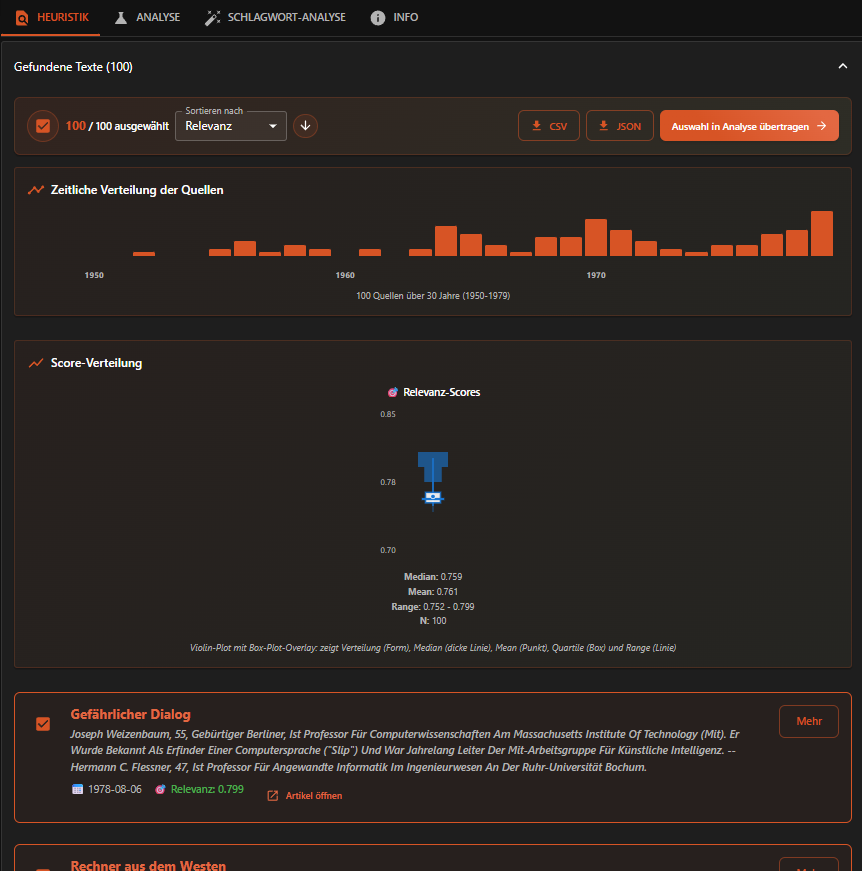

In [18]:
from IPython.display import Image, display
metadata={
    "jdh": {
        "module": "object",
        "object": {
            "type": "image",
            "source": [
                "[Screenshot of SPIEGELRagged application page showing initial Heuristik/Retrieval page]"
            ]
        }
    }
}
display(Image("media/screenshot-simple-retrieval.png"), metadata=metadata)

Retrieved chunks are displayed with full metadata: article title, publication date and relevance score. Users can expand each chunk to read its full content or follow the link to the original article in the SPIEGEL archive. The timeline visualisation shows the temporal distribution of results, immediately revealing potential gaps or concentrations in coverage.

Crucially, the interface invites manual curation. Each chunk has a selection checkbox, and users can deselect retrieved chunks they judge irrelevant before transferring to analysis. This is heuristic refinement at computational scale, not replacing scholarly judgment but enabling it to operate on larger corpora than traditional methods allow.

The system preserves all selection states, allowing researchers to iterate: return to retrieval, adjust parameters, find additional chunks, modify selections, and transfer an updated corpus to analyse.

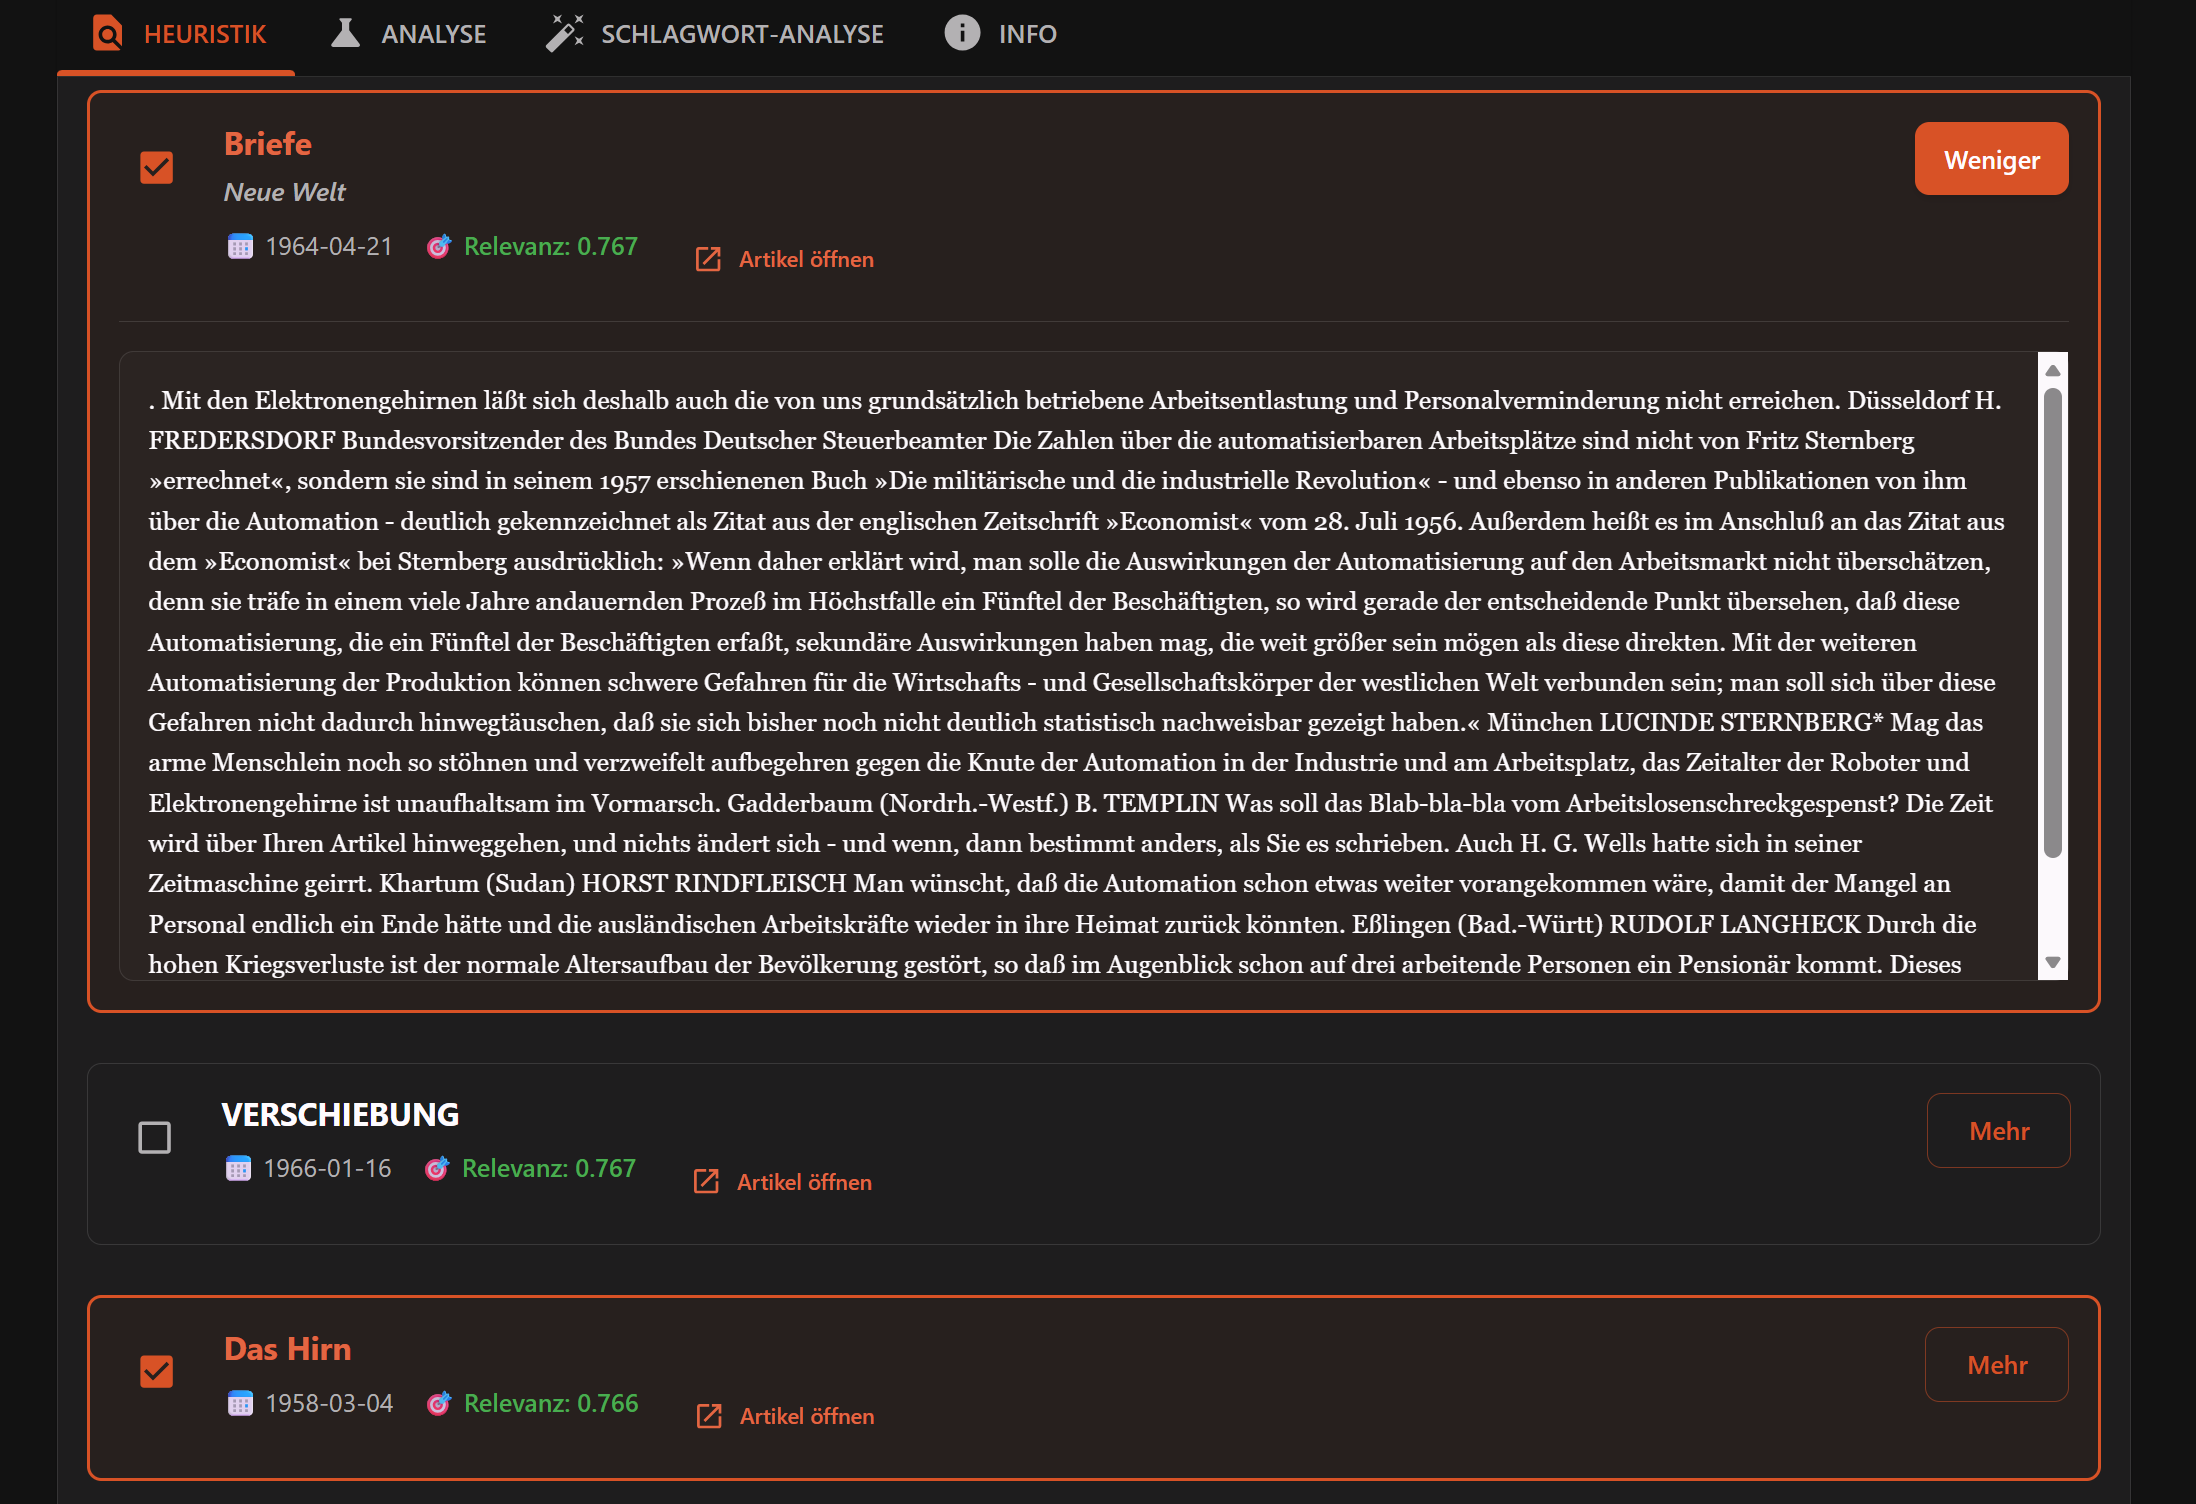

In [19]:
from IPython.display import Image, display
metadata={
    "jdh": {
        "module": "object",
        "object": {
            "type": "image",
            "source": [
                "Screenshot of SPIEGELRagged application page showing chunk retrieval results with metadata"
            ]
        }
    }
}
display(Image("media/chunk-view.png"), metadata=metadata)

The manual curation step addresses a fundamental tension in computational text analysis. Algorithms excel at scale but lack interpretive judgment and humans excel at interpretation but cannot process millions of documents. By positioning algorithmic retrieval as a *first filter* that surfaces candidates for human review, we preserve interpretive authority while enabling computational reach. The historian remains the decision-maker for their corpus.

Yet manual curation has limits. In the worked example above, the researcher reviewed 40 of 100 chunks, feasible for a focused query, but increasingly burdensome as corpora grow. When retrieval surfaces hundreds of candidates, the historian needs support in assessing which chunks merit close attention. This is where LLM-based evaluation can assist by pre-assessing each chunk against researcher-defined criteria, the system can provide argued relevance scores that help prioritise the manual review process. We develop this approach as "LLM-as-a-Judge" in Section 6, where it becomes clear that such evaluation does not replace the curation shown here but augments it, offering the historian a reasoned first assessment that can be accepted, contested, or overridden.

## 4.3 Export as Working Subcorpus

Before proceeding to LLM-assisted analysis, researchers can export their assembled subcorpus as CSV or JSON. This export includes all metadata and scoring, creating a documented, reproducible dataset that can be used independently of the RAG system.

In [20]:
# Load an exported subcorpus from the Heuristik phase

# Settings used:
# - User query: "Wie entwickelte sich die Computerisierung und Automatisierung in der Bundesrepublik Deutschland? Diskussionen über elektronische Datenverarbeitung, Rechenmaschinen, Kybernetik und den Einsatz von Computern in Wirtschaft, Verwaltung und Gesellschaft."
# - Date range: 1950-1979
# - Max articles: 150
# - Chunk size: 3000 characters / overlap: 300 characters
# - Minimum relevance score: 0.3

subcorpus = pd.read_csv('script/simple_heuristik_export.csv', sep=',', encoding='utf-8')

# Display structure and first few rows
print(f"Exported subcorpus: {len(subcorpus)} chunks")
print(f"\nColumns: {list(subcorpus.columns)}")
display(subcorpus[['chunk_id', 'relevance_score', 'title', 'date']].head(10))

Exported subcorpus: 150 chunks

Columns: ['chunk_id', 'relevance_score', 'title', 'date', 'url', 'content']


,chunk_id,relevance_score,title,date
0,1,0.813849,Rechner aus dem Westen,1969-10-26
1,2,0.805424,Welt in der Stube,1968-08-11
2,3,0.795406,Briefe,1965-06-22
3,4,0.794709,Rat von Thesaurus,1970-09-27
4,5,0.785885,Futter mit System,1969-09-28
5,6,0.781660,Futter mit System,1969-09-28
6,7,0.777356,»Das Stahlnetz stülpt sich über uns«,1979-05-13
7,8,0.776726,Unerwünschte Helfer,1970-05-24
8,9,0.776218,Briefe,1978-05-14
9,10,0.775822,Kluge Zwerge,1975-06-01


The export preserves:

- **chunk_id**: Position in the retrieval results
- **relevance_score**: Cosine similarity between query embedding and chunk embedding
- **title**: Original article title from the SPIEGEL archive
- **date**: Publication date
- **url**: Direct link to the original article
- **content**: Full chunk text

This export enables what we might call "DH 1.0" workflows. Researchers can take the subcorpus offline for traditional computational analysis (word frequencies, concordances, topic modeling) or systematic close reading, entirely independent of the LLM-based analysis pipeline.

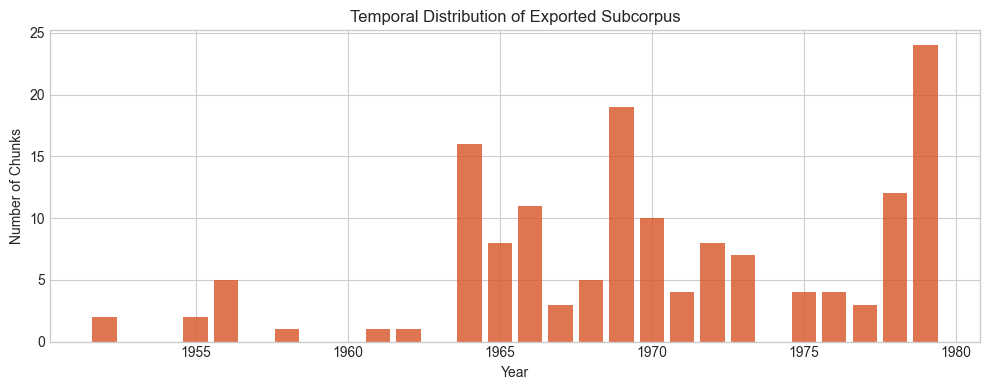

In [21]:
# Extract year from date column
subcorpus['year'] = pd.to_datetime(subcorpus['date'], format='%Y-%m-%d', errors='coerce').dt.year

# Plot distribution
fig, ax = plt.subplots(figsize=(10, 4))
year_counts = subcorpus['year'].value_counts().sort_index()
ax.bar(year_counts.index, year_counts.values, color='#d75425', alpha=0.8)
ax.set_xlabel('Year')
ax.set_ylabel('Number of Chunks')
ax.set_title('Temporal Distribution of Exported Subcorpus')
plt.tight_layout()
plt.show()

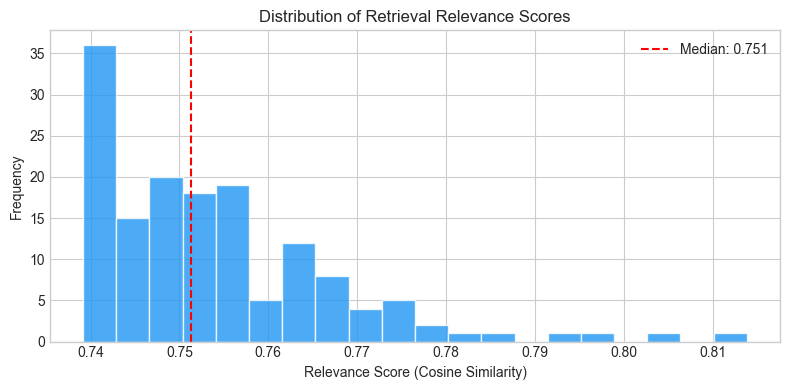

In [22]:
# Example: Relevance score distribution
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(subcorpus['relevance_score'], bins=20, color='#2196f3', alpha=0.8, edgecolor='white')
ax.axvline(subcorpus['relevance_score'].median(), color='red', linestyle='--', 
           label=f'Median: {subcorpus["relevance_score"].median():.3f}')
ax.set_xlabel('Relevance Score (Cosine Similarity)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Retrieval Relevance Scores')
ax.legend()
plt.tight_layout()
plt.show()

The exportable subcorpus functions as the digital historian's "working folder" but unlike the photocopies and notes accumulated during archive visits, these are machine-readable texts that remain computationally processable. The export carries explicit provenance through the retrieval query, similarity scores, and filters applied. It can be shared, reused, and subjected to further analysis, such as word frequencies, concordances, topic modelling, all entirely independent of the RAG system that produced it. Another researcher can examine exactly which sources informed an analysis and, with access to the same vector database, reproduce the retrieval.

This transparency addresses a persistent challenge in computational humanities, it is the "black box" problem where algorithmic selections are neither visible nor reproducible. By making the subcorpus an explicit, exportable artifact, Histo-RAG transforms an opaque pipeline step into a documented research decision.

## 4.4 The Analyse Phase: Interpretation

Transfer from Heuristik to Analyse requires an explicit user action by clicking "Auswahl in Analyse übertragen" (Transfer selection to analysis). This deliberate step prevents the seamless pipeline flow of standard RAG, ensuring researchers consciously transition from corpus construction to interpretation.

The Analyse tab displays the transferred chunks (read-only) and provides controls for LLM-assisted interpretation.

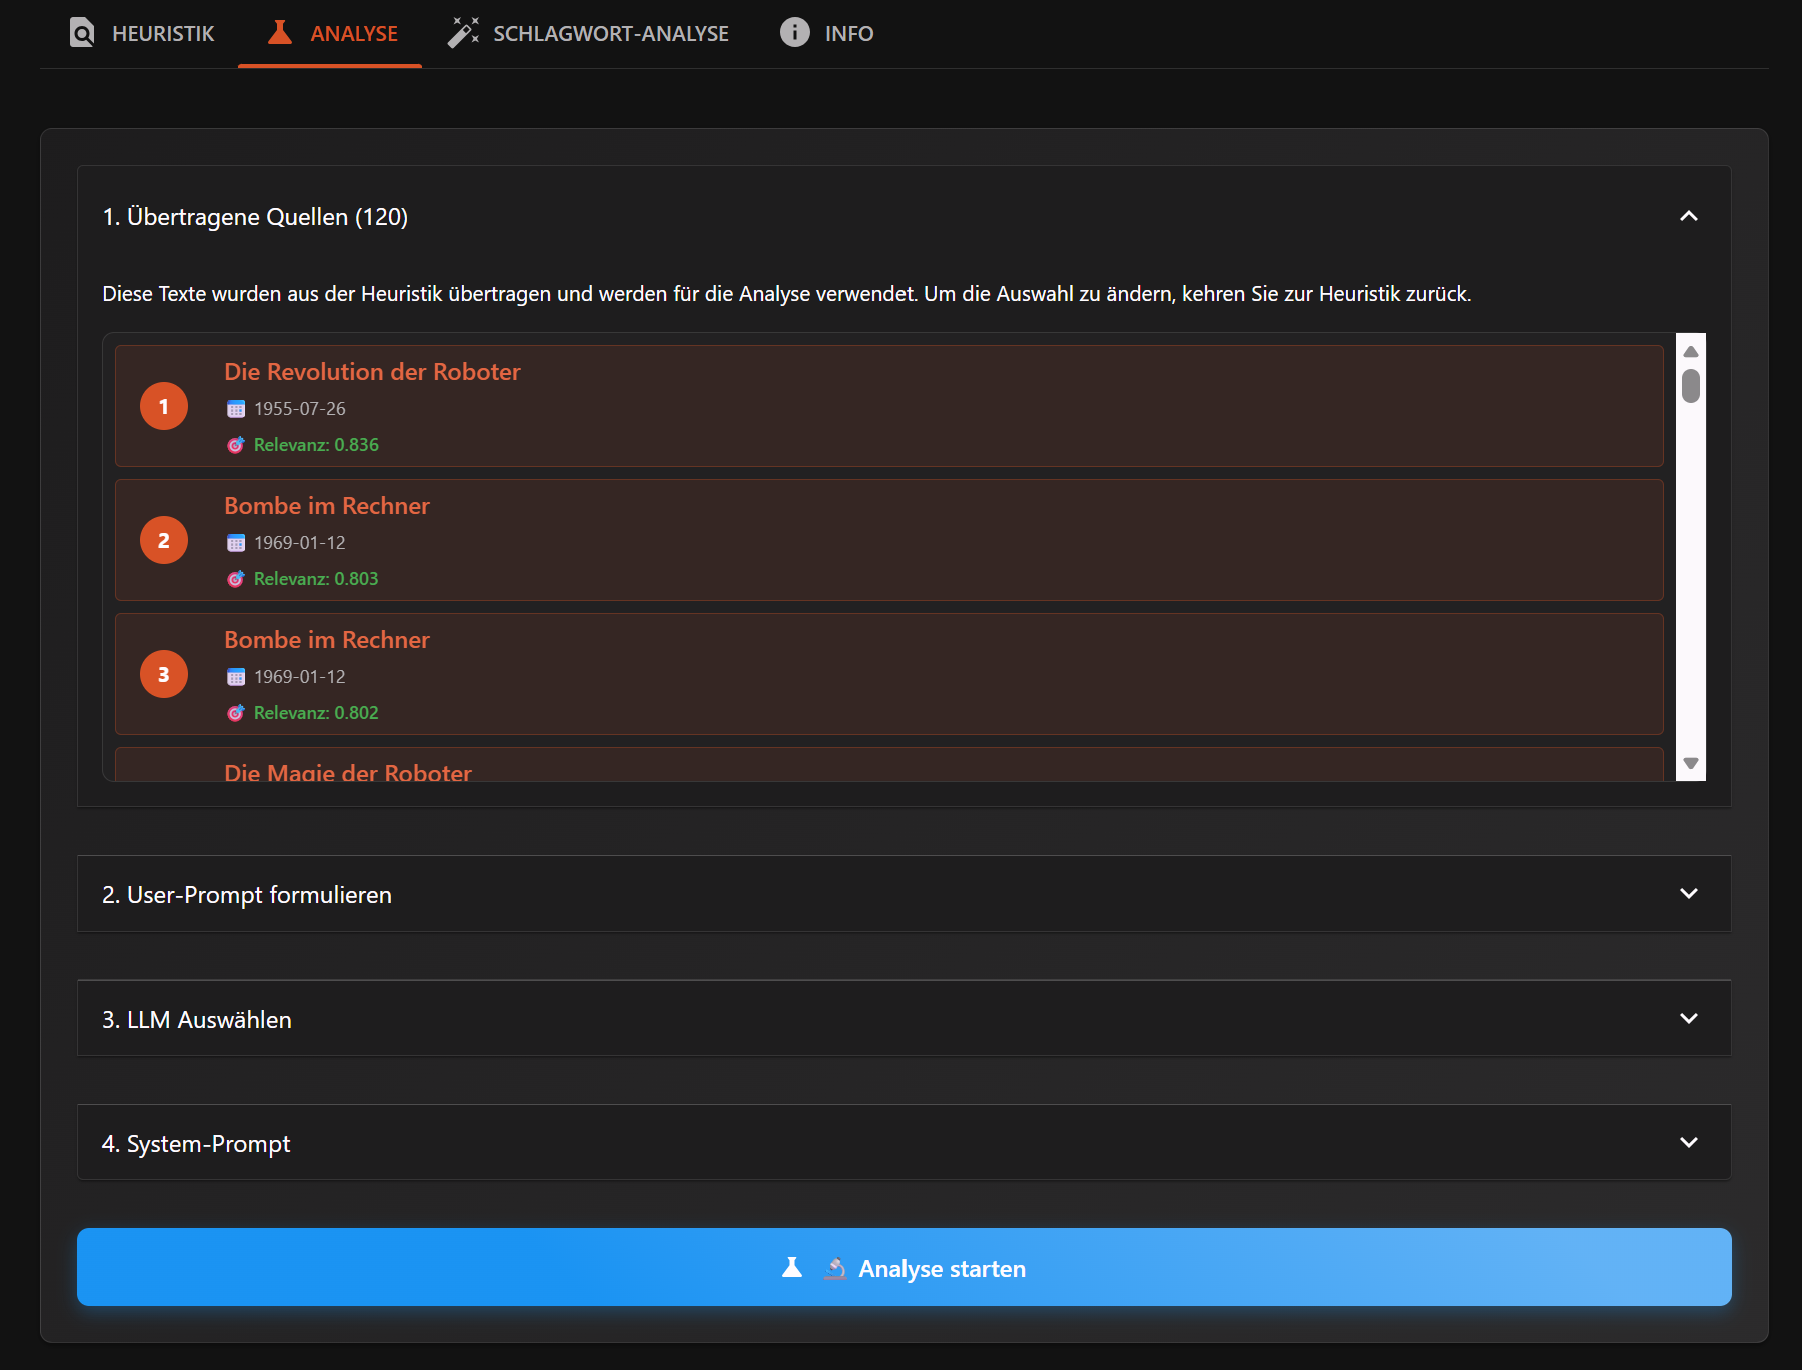

In [23]:
from IPython.display import Image, display
metadata={
    "jdh": {
        "module": "object",
        "object": {
            "type": "image",
            "source": [
                "[Screenshot of SPIEGELRagged application page showing Analyse tab where LLM-generated summaries and analyses are done]"
            ]
        }
    }
}
display(Image("media/analyse-tab.png"), metadata=metadata)

**Analysis configuration options include:**

- **Research question (User-Prompt)**: The interpretive question to ask of the assembled sources. This is distinct from the retrieval query that found them
- **LLM selection**: Multiple models available, including institutional open-weight options (HU-LLM, running Mistral & Qwen models) and commercial APIs (GPT-4, Gemini, DeepSeek, Claude), depending on availability and the specific requirements of the analysis task
- **System prompt**: Methodological instructions that frame how the LLM should approach the sources
- **Temperature**: Controls response variability in certain models (lower values produce more deterministic outputs, not available in reasoning-models)
- **Model-specific parameters**: Such as reasoning effort levels, though this distinction may evolve as reasoning capabilities become standard across models

The availability of multiple LLMs enables a form of methodological triangulation. Researchers can run the same subcorpus and research question through different models, comparing how responses vary. As we will discuss in Section 6, these variations can be substantial. Different models emphasise different aspects of the sources, structure arguments differently, and sometimes reach divergent conclusions. This variability is not a flaw but a feature that foregrounds the interpretive nature of LLM outputs.

## 4.5 Reasoning Transparency

Recent LLM developments have introduced mechanisms for exposing aspects of model processing. OpenAI's GPT-5, for instance, offers configurable "reasoning effort" levels and can generate a "reasoning summary" — a textual account of the model's processing steps (OpenAI, 2025, https://platform.openai.com/docs/guides/reasoning, accessed 01.11.2025).

SPIEGELragged allows users to configure these parameters and consult the resulting reasoning summaries. This supports transparency and methodological documentation. Researchers can examine not just what the model concluded but how it claims to have reached that conclusion.

An example reasoning summary excerpt, from an analysis of reader letters discussing automation:

> *"In 1964, there was a significant moment reflected in letters to The Spiegel about automation. Readers advocated for a planned economy to combat unemployment, raising concerns about 'total overproduction' and the illusions of full automation. Some unions claimed that electronic data processing (EDP) wouldn't lead to staff reductions, while others emphasised the need for automation to address demographic changes... I notice an interesting letter from 1966 where Dr. Friedrichs from IG Metall takes a mature stance, correcting misquotes and indicating that the union is now entangled with computing, contemplating fears of mismanagement instead of fearing robots... I'll connect these themes through letters, showing how automation's meaning evolved and how societal reflections contest dominant narratives."*

A critical caveat is that these "reasoning" outputs should not be understood as windows into actual model cognition. LLMs are autoregressive text generators. They produce tokens sequentially based on learned probability distributions, not through explicit logical reasoning. The "Chain of Thought" paradigm prompts models to generate intermediate steps that *resemble* reasoning, and empirically this improves performance on certain tasks. But the generated reasoning steps are themselves outputs, not process logs. They may represent purely text-based post-hoc rationalisation rather than the actual computational path to an answer (<cite data-cite="chen2025ReasoningModelsDont"></cite>).

OpenAI's documentation for its o1 reasoning model acknowledges this explicitly: the visible reasoning summary is generated content *about* the model's processing, not a direct transcript of it (<cite data-cite="openai2024OpenAIO1System"></cite>). For historical research, these summaries can nonetheless be valuable as they document the analytical moves the model claims to have made, identify which sources it emphasised, and reveal the narrative structure it constructed. We can treat them as interpretive artifacts to be critically examined rather than authoritative accounts of model reasoning.

Rüsen (<cite data-cite="rusen2019EvidenceMeaningTheory"></cite>) distinguishes between the cognitive work of research (methodically regulated and verifiable) and the representational work of historical narrative, which incorporates research but "is not primarily cognitive in form" (p. 128). The LLM's "reasoning summaries" occupy an ambiguous position. They are generated outputs that represent a purely text-based analytical process rather than documenting one. We treat them as interpretive artifacts to be critically examined, not as authoritative accounts of how conclusions were reached.

## 4.6 Preserving Source Access

Throughout both phases, SPIEGELragged maintains direct links to original sources. Each chunk retains its URL to the full article in the SPIEGEL archive, which users can use to get to the full-text version of the article and issue.

This design principle reflects a core commitment; the RAG system augments but never replaces access to primary sources. The chunks are entry points, not substitutes. A researcher who finds a relevant passage through semantic search can immediately access the complete source, assess context that the chunk omits, and make independent judgments about the source's significance.

In [24]:
# Example: Accessing source URLs from the exported subcorpus
print("Sample source URLs from the subcorpus:\n")
for idx, row in subcorpus.head(5).iterrows():
    print(f"[{row['chunk_id']}] {row['title']}")
    print(f"    Date: {row['date']}")
    print(f"    URL: {row['url']}")
    print()

Sample source URLs from the subcorpus:

[1] Rechner aus dem Westen
    Date: 1969-10-26
    URL: https://www.spiegel.de/politik/rechner-aus-dem-westen-a-6995cec6-0002-0001-0000-000045520479?context=issue

[2] Welt in der Stube
    Date: 1968-08-11
    URL: https://www.spiegel.de/kultur/welt-in-der-stube-a-80117524-0002-0001-0000-000045950214?context=issue

[3] Briefe
    Date: 1965-06-22
    URL: https://www.spiegel.de/politik/denkmaschinen-a-e55398e4-0002-0001-0000-000046273029?context=issue

[4] Rat von Thesaurus
    Date: 1970-09-27
    URL: https://www.spiegel.de/politik/rat-von-thesaurus-a-c6965cef-0002-0001-0000-000044418105?context=issue

[5] Futter mit System
    Date: 1969-09-28
    URL: https://www.spiegel.de/politik/futter-mit-system-a-6fa1d6ef-0002-0001-0000-000045547686?context=issue



The preservation of source URLs instantiates a methodological principle: computational tools should lower barriers to primary sources, not raise them.

# 5. Temporal Windowing for Balanced Retrieval

After designing a seperation in retrieval and generation alligned with our methodological practices, and having discussed th initial retrieval process, we now have chunks that are assembled into a curated subcorpus. But problems remain in the retrieval itself. Similarity-based search returns chunks ranked by semantic proximity to the query embedding and this ranking often correlates with temporal factors. Vocabulary, concepts, and discourse patterns evolved across the three decades of our corpus (1950-1979). Chunks from periods where terminology most closely matches the query embedding will be over-represented; other periods with different vocabulary may be systematically under-retrieved.

For metaquestions involving discourse evolution this temporal bias is methodologically problematic. Section 5 introduces our second architectural innovation: temporal windowing, which ensures balanced retrieval across the search timeframe.

## 5.1 Time and Historical Research: Theoretical Foundations

Before examining the technical challenge, we must understand why temporality matters fundamentally to historical scholarship, not merely as a practical concern but as an epistemological foundation for our metaquestions. Welskopp (<cite data-cite="welskopp2008HistorischeErkenntnis"></cite>) identifies what he terms the *Kontinuitätsannahme* (continuity assumption) as one of the foundational pillars of historical method. It is the principle that historical understanding requires tracing connections across time, seeing how phenomena develop, transform, and relate to what came before and after. This is not merely an assumption but a methodological commitment by historians to approach their objects through what Welskopp calls "historische Betrachtungsweise" (historical perspective), which he argues defines the discipline more fundamentally than any specific technique (p. 11). The question is not *what* methods historians use (as these vary widely across subfields) but *how* they approach their objects: as phenomena embedded in and shaped by temporal contexts that must be reconstructed.

This temporal orientation creates particular challenges for computational methods. Embedding models encode text in semantic spaces shaped by contemporary language patterns. They lack the temporal situatedness that enables historians to recognise when vocabulary, concepts, or framings mark their historical moment. The embedding model that encodes our query does not from its parametric knowledge contextualise that "Elektronengehirn" represents a specific historical moment's way of making meaning about computing technology.

To address this challenge, we introduce *temporal windowing*: rather than retrieving the top-N most similar chunks across the entire corpus, we divide the search period into temporal windows and retrieve proportionally from each. This ensures balanced temporal representation regardless of how vocabulary similarity distributes across decades. In the following sections, we first demonstrate the problem (5.2), then examine what temporal windowing reveals (5.3), before reflecting on the methodological implications (5.4).

## 5.2 The Technical Challenge: Vocabulary Drift as Retrieval Bias

These theoretical concerns manifest concretely in semantic search. Consider our metaquestion about terminology evolution. When we search for content about "Computer, Automatisierung, Arbeitslosigkeit" (computers, automation, unemployment), the embedding model encodes this query in a semantic space shaped by the contemporary language patterns from which most of its training data derives. Chunks from the late 1970s, when "Computer" had become the dominant term and automation anxieties were mainstream political discourse, will naturally score higher in similarity than chunks from the early 1950s, when the same phenomena were described as "Elektronengehirn" (electronic brain) or "Rechenmaschine" (calculating machine).

This is not a flaw in the embedding model, it accurately captures semantic proximity. The problem is methodological, as for discourse evolution questions, high semantic similarity to a modern query formulation may inversely correlate with historical significance. The earliest sources, precisely those that document the emergence and transformation of concepts, use vocabulary most distant from contemporary usage. Standard RAG thus embodies a presentist bias, it privileges sources that speak our language over sources that document how that language came to be.

Busch (<cite data-cite="busch2015DiskurslexikologieUndSprachgeschichte"></cite>) provides the linguistic evidence for this drift. The first public discourse about computer technology in *Der Spiegel* appeared in 1949-1950, using "strongly anthropomorphising" terminology like "Elektronengehirn" and "Maschinengehirn", these are "technology stereotypes" that framed computing through analogies to human cognition (p. 219). Busch identifies a systematic pattern: lay vocabulary about computerisation entered public discourse with considerable delay relative to technical development, undergoing what he calls "Wissensdispersion" (knowledge dispersion) as concepts moved from expert to popular contexts (p. 67). The early vocabulary reflected uncertainty, wonder, and anxiety; by the late 1960s, "Computer" had largely displaced these earlier terms, marking the technology's routinisation. A similarity-based search using contemporary vocabulary will systematically under-retrieve the formative early period where the conceptual foundations of public understanding were established.

The temporal imbalance in our corpus compounds this problem. As documented in Section 2, the 1970s produced 41% of our corpus articles compared to 24% from the 1950s, a near two-to-one ratio. Combined with vocabulary drift, standard retrieval would produce corpora heavily skewed toward particular periods. For questions about discourse *evolution*, this would be methodologically catastrophic, as we would retrieve the destination without documenting the journey, thereby violating the *Kontinuitätsannahme* that historical understanding requires tracing temporal connections.

## 5.3 Demonstrating Query Fragility: Vocabulary Choice as Temporal Filter

The theoretical problem becomes empirically visible through a simple experiment. If vocabulary evolved across three decades of computerisation discourse, then queries using era-specific terminology should retrieve disproportionately from those eras. We test this by constructing three query sets based on Busch's (2015) periodisation of computerisation vocabulary:

```python
# Define era-specific vocabulary sets based on Busch (<cite data-cite="busch2015DiskurslexikologieUndSprachgeschichte"></cite>)
# These groupings reflect the linguistic periodisation documented in discourse-lexicological research

query_sets = {
    '1950s_vocabulary': [
        'Elektronenhirn', 'Elektronengehirn', 'Denkmaschine', 
        'Rechenmaschine', 'Roboter', 'Robotergehirn'
    ],
    '1960s_vocabulary': [
        'Automation', 'Lochkarte', 'Rechenautomat', 
        'IBM', 'Datenverarbeitung', 'Hollerith'
    ],
    '1970s_vocabulary': [
        'Computer', 'EDV', 'Großrechner', 
        'elektronische Datenverarbeitung', 'Mikroelektronik', 'Minicomputer'
    ]
}

# Note: These categories are analytically constructed based on Busch's findings
# about terminology evolution. Real usage overlapped, but dominant terms shifted.
```

Each query set was run against the full corpus (1950-1979) using standard cosine similarity retrieval, returning the top 50 most similar chunks without temporal filtering.

In [25]:
# Load experiment results
# Each file contains top 50 chunks retrieved using era-specific vocabulary
set50s = pd.read_csv('script/chapter_5/temp_test1_set50s.csv')
set60s = pd.read_csv('script/chapter_5/temp_test1_set60s.csv')
set70s = pd.read_csv('script/chapter_5/temp_test1_set70s.csv')

# Extract years from date column
for df in [set50s, set60s, set70s]:
    df['year'] = pd.to_datetime(df['date']).dt.year

# Assign decades
def assign_decade(year):
    if year < 1960: return '1950s'
    elif year < 1970: return '1960s'
    else: return '1970s'

for df in [set50s, set60s, set70s]:
    df['decade'] = df['year'].apply(assign_decade)

The following results confirm that vocabulary choice functions as an implicit temporal filter.

In [26]:
# Calculate decade distributions for each query set
datasets = {
    '1950s Vocabulary': set50s,
    '1960s Vocabulary': set60s,
    '1970s Vocabulary': set70s
}

# Create comparison table
print("=" * 70)
print("TEMPORAL DISTRIBUTION BY QUERY VOCABULARY")
print("=" * 70)
print(f"\n{'Query Set':<25} {'1950s':>12} {'1960s':>12} {'1970s':>12}")
print("-" * 70)

for name, df in datasets.items():
    decade_counts = df['decade'].value_counts(normalize=True).sort_index() * 100
    pcts = [decade_counts.get(d, 0) for d in ['1950s', '1960s', '1970s']]
    print(f"{name:<25} {pcts[0]:>11.1f}% {pcts[1]:>11.1f}% {pcts[2]:>11.1f}%")

print(f"{'Corpus Baseline':<25} {'24.0%':>12} {'35.0%':>12} {'41.0%':>12}")
print("-" * 70)

TEMPORAL DISTRIBUTION BY QUERY VOCABULARY

Query Set                        1950s        1960s        1970s
----------------------------------------------------------------------
1950s Vocabulary                 48.0%        42.0%        10.0%
1960s Vocabulary                 18.0%        48.0%        34.0%
1970s Vocabulary                  0.0%        28.0%        72.0%
Corpus Baseline                  24.0%        35.0%        41.0%
----------------------------------------------------------------------


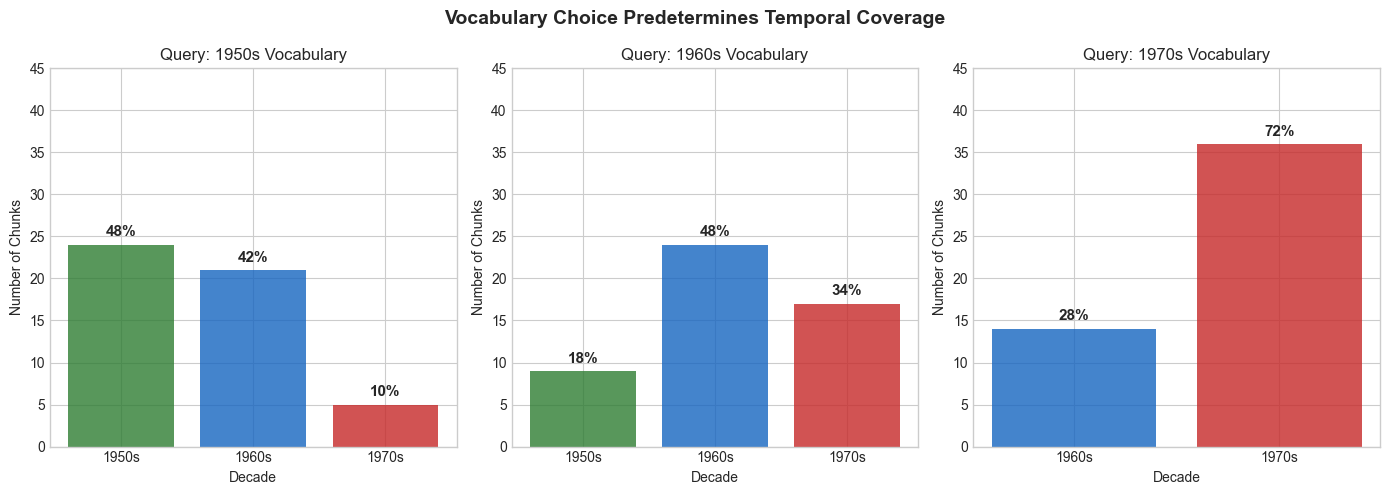

In [27]:
# Visualise the temporal distributions
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

decade_colors = {'1950s': '#2E7D32', '1960s': '#1565C0', '1970s': '#C62828'}
query_names = ['1950s Vocabulary', '1960s Vocabulary', '1970s Vocabulary']
query_data = [set50s, set60s, set70s]

for ax, name, df in zip(axes, query_names, query_data):
    decade_counts = df['decade'].value_counts().sort_index()
    colors = [decade_colors[d] for d in decade_counts.index]
    bars = ax.bar(decade_counts.index, decade_counts.values, color=colors, alpha=0.8)
    
    # Add percentage labels
    for bar, (decade, count) in zip(bars, decade_counts.items()):
        pct = count / len(df) * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                f'{pct:.0f}%', ha='center', fontsize=11, fontweight='bold')
    
    ax.set_xlabel('Decade')
    ax.set_ylabel('Number of Chunks')
    ax.set_title(f'Query: {name}')
    ax.set_ylim(0, 45)

plt.suptitle('Vocabulary Choice Predetermines Temporal Coverage', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

The pattern is striking. Queries using 1950s vocabulary retrieve 48% of chunks from the 1950s, double the corpus baseline of 24%. Queries using 1960s vocabulary peak in the 1960s at 48%. Most dramatically, queries using 1970s vocabulary retrieve **zero chunks from the 1950s** and 72% from the 1970s. This implies that a researcher approaching computerisation discourse with contemporary vocabulary would systematically miss the formative period of public discourse formation.

This finding computationally validates Busch's linguistic periodisation while revealing its methodological consequences for RAG-based research. The vocabulary a researcher chooses, often unconsciously, based on their own historical moment, functions as a temporal filter that predetermines which periods of discourse become visible. This challenge, it should be noted, is not unique to computational methods; analogue research faces the same vocabulary-bound limitations, though at smaller scale.

**The Illusion of Chronological Consistency**

One might assume that combining vocabulary from all periods would solve this problem. If early terms are included in the query, surely early sources will be retrieved as well? We test this by constructing a comprehensive query combining all three vocabulary sets:
```python
# Comprehensive query: all terms from all periods
comprehensive_terms = (
    query_sets['1950s_vocabulary'] + 
    query_sets['1960s_vocabulary'] + 
    query_sets['1970s_vocabulary']
)

# Query string used:
# "Elektronenhirn, Elektronengehirn, Denkmaschine, Rechenmaschine, Roboter, 
#  Automation, Lochkarte, Rechenautomat, IBM, Datenverarbeitung,
#  Computer, EDV, Großrechner, elektronische Datenverarbeitung, Minicomputer"
```

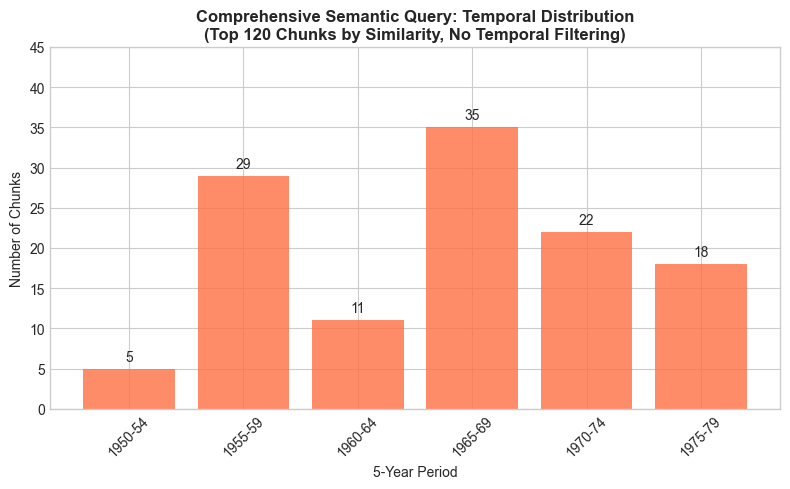


TEMPORAL DISTRIBUTION: Comprehensive Semantic Query (unfiltered)
  1950-54:   5 chunks (4.2%)
  1955-59:  29 chunks (24.2%)
  1960-64:  11 chunks (9.2%)
  1965-69:  35 chunks (29.2%)
  1970-74:  22 chunks (18.3%)
  1975-79:  18 chunks (15.0%)


In [28]:
# Load comprehensive query results and keyword corpus for comparison
# Without temporal filtering: top 120 chunks by similarity
# With temporal filtering: 20 chunks per 5-year window (6 windows × 20 = 120)
# Keyword corpus: lexical keyword matching from Section 4
comprehensive = pd.read_csv('script/chapter_5/temp_test2.csv')
comprehensive_filtered = pd.read_csv('script/chapter_5/temp_test2_filtered.csv')
computerisation_df.rename(columns={'Datum': 'date'}, inplace=True)

for df in [comprehensive, comprehensive_filtered, computerisation_df]:
    df['year'] = pd.to_datetime(df['date']).dt.year
    df['decade'] = df['year'].apply(assign_decade)

# Define 5-year periods for more granular analysis
def assign_period(year):
    if year < 1955: return '1950-54'
    elif year < 1960: return '1955-59'
    elif year < 1965: return '1960-64'
    elif year < 1970: return '1965-69'
    elif year < 1975: return '1970-74'
    else: return '1975-79'

comprehensive['period'] = comprehensive['year'].apply(assign_period)
comprehensive_filtered['period'] = comprehensive_filtered['year'].apply(assign_period)
computerisation_df['period'] = computerisation_df['year'].apply(assign_period)

period_order = ['1950-54', '1955-59', '1960-64', '1965-69', '1970-74', '1975-79']

# Visualise the unfiltered semantic retrieval distribution
fig, ax = plt.subplots(figsize=(8, 5))

period_counts_nf = comprehensive['period'].value_counts().reindex(period_order, fill_value=0)
ax.bar(period_order, period_counts_nf.values, color='#FF7043', alpha=0.8)
ax.set_xlabel('5-Year Period')
ax.set_ylabel('Number of Chunks')
ax.set_title('Comprehensive Semantic Query: Temporal Distribution\n(Top 120 Chunks by Similarity, No Temporal Filtering)', fontsize=12, fontweight='bold')
ax.set_ylim(0, max(period_counts_nf.max(), 40) + 5)
ax.tick_params(axis='x', rotation=45)

# Add count labels
for i, (period, count) in enumerate(period_counts_nf.items()):
    ax.text(i, count + 1, str(count), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# Print the distribution
print("\nTEMPORAL DISTRIBUTION: Comprehensive Semantic Query (unfiltered)")
print("=" * 50)
total = period_counts_nf.sum()
for period in period_order:
    count = period_counts_nf.get(period, 0)
    pct = count / total * 100
    print(f"  {period}: {count:3d} chunks ({pct:.1f}%)")


The comprehensive query without temporal filtering retrieves 28.4% from the 1950s, 38.4% from the 1960s, and 33.3% from the 1970s. While this appears more balanced than era-specific queries, the distribution still reflects unpredictable biases introduced by how the embedding model weights different terms in semantic space. More revealing is the 5-year period breakdown: only 4.2% of chunks come from 1950-1954, compared to 29.2% from 1965-1969. The earliest formative period remains systematically under-represented.

This pattern partly reflects the corpus composition documented in Section 2, where later decades contain substantially more articles. Nevertheless, the key insight is that query formulation alone cannot solve the temporal bias problem. Whether using narrow or comprehensive vocabulary, the researcher cannot predict or control how the embedding model will distribute retrieval across time periods. Vocabulary choice becomes an invisible methodological decision with consequences the researcher cannot anticipate.

**How Temporal Windowing Shifts the Retrieval Set**

The temporal skew demonstrated above has concrete consequences for which sources a researcher encounters. To make this visible, we compare retrieval results with and without the temporal windowing introduced in section 5.1, retrieving proportionally from each five-year window rather than selecting globally by similarity. The first list below shows articles that temporal windowing adds to the retrieval set: sources absent from standard similarity-based retrieval, surfaced because windowing guarantees representation from under-represented periods. The second list shows articles displaced in exchange: sources that ranked highly by similarity alone but were deprioritised to make room for temporal balance.

In [29]:
# Identify articles unique to each approach
filtered_titles = set(comprehensive_filtered['title'].unique())
unfiltered_titles = set(comprehensive['title'].unique())

added_titles = filtered_titles - unfiltered_titles
displaced_titles = unfiltered_titles - filtered_titles

# Get details of added and displaced articles
added_df = comprehensive_filtered[comprehensive_filtered['title'].isin(added_titles)][
    ['title', 'date', 'year', 'relevance_score']
].drop_duplicates('title').sort_values('date')

displaced_df = comprehensive[comprehensive['title'].isin(displaced_titles)][
    ['title', 'date', 'year', 'relevance_score']
].drop_duplicates('title').sort_values('date')

print("=" * 70)
print(f"ARTICLES ADDED BY TEMPORAL WINDOWING: {len(added_titles)}")
print("=" * 70)
print("\nThese articles appear only with temporal windowing, not in standard similarity-based retrieval:\n")
for _, row in added_df.iterrows():
    print(f"  {row['date']}: {row['title'][:50]:<50} (score: {row['relevance_score']:.3f})")

print("\n" + "=" * 70)
print(f"ARTICLES DISPLACED BY TEMPORAL WINDOWING: {len(displaced_titles)}")
print("=" * 70)
print("\nThese articles are EXCLUDED to make room for temporal balance:\n")
for _, row in displaced_df.iterrows():
    print(f"  {row['date']}: {row['title'][:50]:<50} (score: {row['relevance_score']:.3f})")

ARTICLES ADDED BY TEMPORAL WINDOWING: 17

These articles appear only with temporal windowing, not in standard similarity-based retrieval:

  1950-05-24: Porsche von Fallersleben                           (score: 0.691)
  1950-06-07: Kino im Wohnzimmer                                 (score: 0.687)
  1951-04-10: US-Präsident in der Höhle                          (score: 0.681)
  1952-01-29: Lehrhaftes Spielzeug                               (score: 0.683)
  1952-06-24: Generationen von Halbidioten                       (score: 0.706)
  1952-07-01: Die PAG ist eine Macht                             (score: 0.687)
  1952-08-12: Bei aller Dankbarkeit                              (score: 0.681)
  1953-02-17: Das kleine Einmaleins                              (score: 0.682)
  1953-09-22: Nervenkitzel dreidimensional                       (score: 0.690)
  1953-12-08: Im Dschungel des Geschmacks                        (score: 0.693)
  1954-01-05: Mord am Händler                                

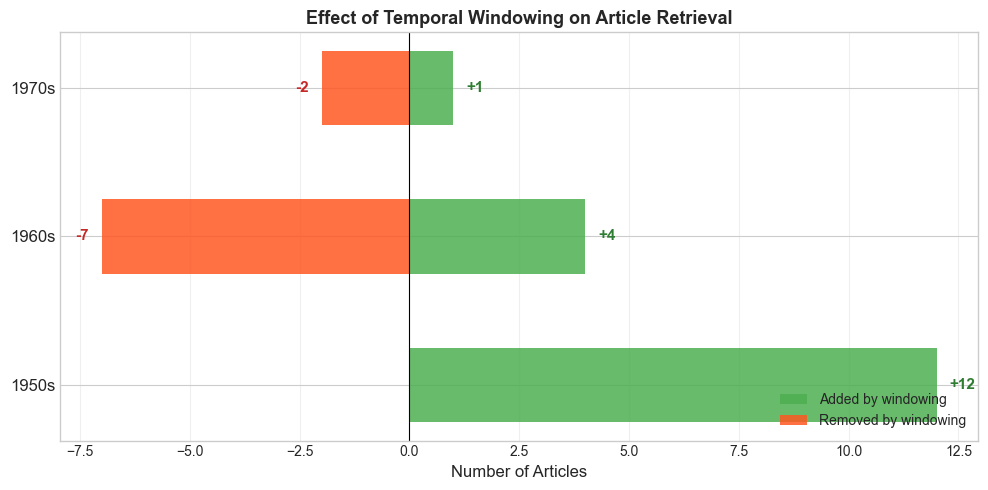


Added: 17 articles (primarily 1950s)
Removed: 9 articles (primarily 1960s)

Mean relevance score - Added: 0.703
Mean relevance score - Removed: 0.753


In [30]:
# Temporal windowing effect: articles added vs removed
# Visualise as diverging bar chart (single axis) per Torsten's suggestion
added_article_years = comprehensive_filtered[comprehensive_filtered['title'].isin(added_titles)].drop_duplicates('title')['year']
displaced_article_years = comprehensive[comprehensive['title'].isin(displaced_titles)].drop_duplicates('title')['year']

added_decades = [assign_decade(y) for y in added_article_years]
displaced_decades = [assign_decade(y) for y in displaced_article_years]

added_counts = pd.Series(added_decades).value_counts().reindex(['1950s', '1960s', '1970s'], fill_value=0)
displaced_counts = pd.Series(displaced_decades).value_counts().reindex(['1950s', '1960s', '1970s'], fill_value=0)

fig, ax = plt.subplots(figsize=(10, 5))

decades = ['1950s', '1960s', '1970s']
y_pos = range(len(decades))

# Added articles (positive, left/green)
added_vals = [added_counts.get(d, 0) for d in decades]
# Removed articles (negative, right/red)  
removed_vals = [-displaced_counts.get(d, 0) for d in decades]

bars_added = ax.barh(y_pos, added_vals, color='#4CAF50', alpha=0.85, label='Added by windowing', height=0.5)
bars_removed = ax.barh(y_pos, removed_vals, color='#FF5722', alpha=0.85, label='Removed by windowing', height=0.5)

# Add count labels
for i, (a, r) in enumerate(zip(added_vals, removed_vals)):
    if a > 0:
        ax.text(a + 0.3, i, f'+{a}', va='center', fontsize=11, fontweight='bold', color='#2E7D32')
    if r < 0:
        ax.text(r - 0.3, i, f'{r}', va='center', ha='right', fontsize=11, fontweight='bold', color='#C62828')

ax.set_yticks(y_pos)
ax.set_yticklabels(decades, fontsize=12)
ax.set_xlabel('Number of Articles', fontsize=12)
ax.set_title('Effect of Temporal Windowing on Article Retrieval', fontsize=13, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.legend(loc='lower right', fontsize=10)
ax.grid(axis='x', alpha=0.3)

# Summary
plt.tight_layout()
plt.show()

print(f"\nAdded: {len(added_titles)} articles (primarily 1950s)")
print(f"Removed: {len(displaced_titles)} articles (primarily 1960s)")
print(f"\nMean relevance score - Added: {added_df['relevance_score'].mean():.3f}")
print(f"Mean relevance score - Removed: {displaced_df['relevance_score'].mean():.3f}")


The pattern confirms temporal windowing's methodological function: articles surfaced by windowing tend to cluster in the 1950s, while deprioritised articles come primarily from the 1960s, producing a more balanced and thus more robust temporal distribution. The 1950s articles are not necessarily more important than 1960s articles in absolute terms, but for research questions about discourse evolution, they are essential. Without temporal windowing, standard retrieval would document computerisation discourse at its mature state while systematically omitting the formative period where concepts, vocabulary, and public understanding were being established.

The relevance score differential makes the trade-off explicit. It is important to note that the relevance score here measures thematic proximity to the query, not relevance for the research question. This is a distinction we address through LLM-as-a-Judge evaluation in section 6. Surfaced articles score lower (mean: 0.703) than deprioritised articles (mean: 0.753). By guaranteeing temporal balance, we accept lower aggregate similarity in exchange for temporal coverage. This is a deliberate methodological choice, we treat temporal representativeness as a dimension of relevance that similarity metrics alone cannot capture.

## 5.4 Temporal Windowing as Methodological Intervention

Temporal windowing addresses this bias through a simple but consequential design choice. Rather than retrieving the top-N most similar chunks across the entire corpus, we divide the search period into temporal windows and retrieve proportionally from each. For a thirty-year corpus searched in six five-year windows with twenty chunks per window, we guarantee balanced representation regardless of how vocabulary similarity distributes across time.

This intervention exemplifies Critical Technical Practice (<cite data-cite="agre1998CriticalTechnicalPractice"></cite>): rather than accepting computational defaults as neutral optimisations, we examine the assumptions they embed and redesign systems to embody different commitments. Standard RAG architectures optimise for what is computationally natural (similarity maximisation) without interrogating whether this serves the research context. Temporal windowing recognises that similarity-based retrieval embeds presentist assumptions about relevance, and redesigns the system to embody historical methodology's temporal commitments.

The implementation in SPIEGELragged is deliberately transparent:

```python
# From enhanced_time_window_strategy.py
def _create_time_windows(self, start_year: int, end_year: int) -> List[Tuple[int, int]]:
    """Create time windows for the given year range."""
    windows = []
    current_start = start_year
    while current_start <= end_year:
        current_end = min(current_start + self.window_size - 1, end_year)
        windows.append((current_start, current_end))
        current_start = current_end + 1
    return windows
```

The simplicity is intentional. Each window receives equal retrieval allocation regardless of corpus density or similarity scores within that window. This implements computationally what historians do intuitively in traditional research, ensuring temporal coverage for the period under investigation. A historian investigating discourse evolution would not simply read the most accessible sources; they would deliberately sample across the full period, knowing that early sources require different finding strategies than later ones, including different archives, different search terms, and different contextual knowledge. Temporal windowing embeds this methodological commitment into the retrieval architecture.

The trade-off is explicit and contestable. As Welskopp (<cite data-cite="welskopp2008HistorischeErkenntnis"></cite>) argues, "die Methode folgt aus der Frage und der Theorie" (method follows from question and theory) — there is no universal optimum, only choices appropriate to specific inquiries (p. 11). By guaranteeing temporal balance, we accept that some windows will yield lower-similarity chunks than a global search would have retrieved. For the 1950s windows, we retrieve chunks at lower similarity scores while potentially excluding higher-scoring chunks from the 1970s. 

Having introduced temporal windowing as a methodological intervention, we can now compare all three retrieval approaches side by side: unfiltered semantic retrieval, temporally windowed retrieval, and the keyword corpus from Section 2. This comparison reveals how each method distributes sources across time and why temporal balance requires deliberate design.

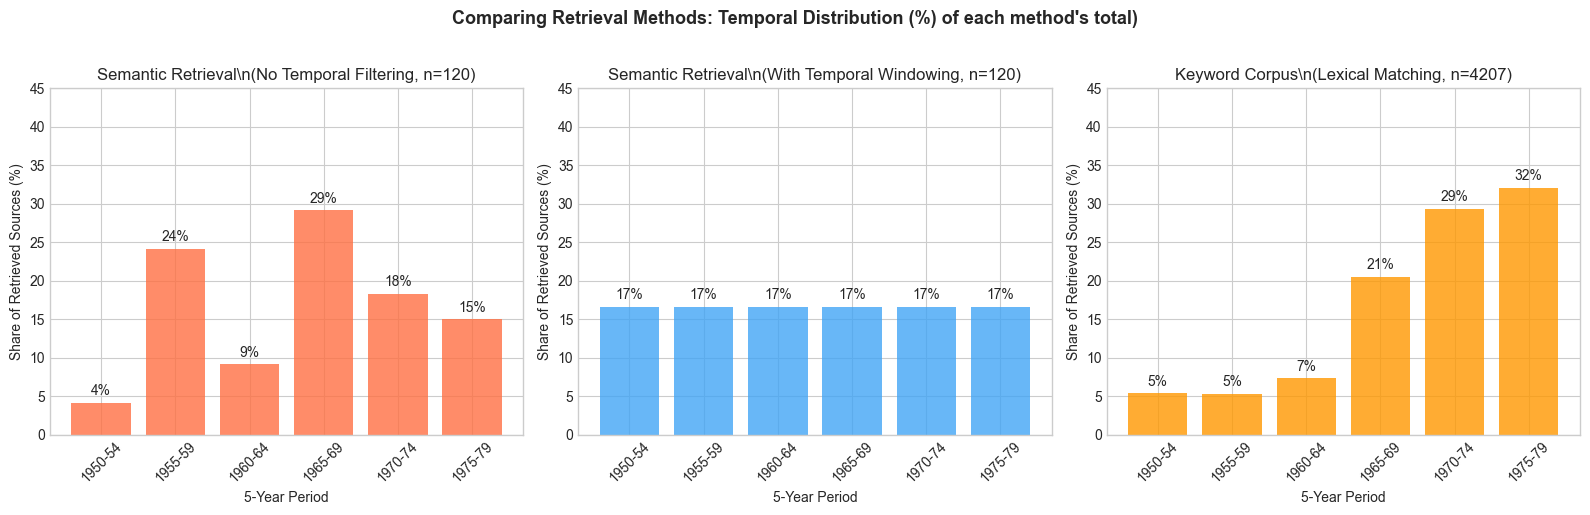

\n================================================================================
TEMPORAL DISTRIBUTION COMPARISON (% of each method's total)
\nPeriod       Semantic (raw)     Semantic (windowed)    Keyword corpus    
--------------------------------------------------------------------------------
1950-54        4.2%             16.7%                 5.4%
1955-59       24.2%             16.7%                 5.3%
1960-64        9.2%             16.7%                 7.3%
1965-69       29.2%             16.7%                20.5%
1970-74       18.3%             16.7%                29.3%
1975-79       15.0%             16.7%                32.1%


In [31]:
# Three-method comparison: now that temporal windowing has been introduced
# All panels show percentage distributions for direct comparability
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left: Without filtering (semantic)
period_counts_nf = comprehensive['period'].value_counts().reindex(period_order, fill_value=0)
period_pcts_nf = period_counts_nf / period_counts_nf.sum() * 100
axes[0].bar(period_order, period_pcts_nf.values, color='#FF7043', alpha=0.8)
axes[0].set_xlabel('5-Year Period')
axes[0].set_ylabel('Share of Retrieved Sources (%)')
axes[0].set_title(f'Semantic Retrieval\\n(No Temporal Filtering, n={period_counts_nf.sum()})')
axes[0].set_ylim(0, 45)
axes[0].tick_params(axis='x', rotation=45)
for i, (period, pct) in enumerate(period_pcts_nf.items()):
    axes[0].text(i, pct + 1, f'{pct:.0f}%', ha='center', fontsize=10)

# Middle: With filtering (semantic + windowing)
period_counts_f = comprehensive_filtered['period'].value_counts().reindex(period_order, fill_value=0)
period_pcts_f = period_counts_f / period_counts_f.sum() * 100
axes[1].bar(period_order, period_pcts_f.values, color='#42A5F5', alpha=0.8)
axes[1].set_xlabel('5-Year Period')
axes[1].set_ylabel('Share of Retrieved Sources (%)')
axes[1].set_title(f'Semantic Retrieval\\n(With Temporal Windowing, n={period_counts_f.sum()})')
axes[1].set_ylim(0, 45)
axes[1].tick_params(axis='x', rotation=45)
for i, (period, pct) in enumerate(period_pcts_f.items()):
    axes[1].text(i, pct + 1, f'{pct:.0f}%', ha='center', fontsize=10)

# Right: Keyword corpus (lexical matching)
period_counts_kw = computerisation_df['period'].value_counts().reindex(period_order, fill_value=0)
period_pcts_kw = period_counts_kw / period_counts_kw.sum() * 100
axes[2].bar(period_order, period_pcts_kw.values, color='#FF9800', alpha=0.8)
axes[2].set_xlabel('5-Year Period')
axes[2].set_ylabel('Share of Retrieved Sources (%)')
axes[2].set_title(f'Keyword Corpus\\n(Lexical Matching, n={len(computerisation_df)})')
axes[2].set_ylim(0, 45)
axes[2].tick_params(axis='x', rotation=45)
for i, (period, pct) in enumerate(period_pcts_kw.items()):
    axes[2].text(i, pct + 1, f'{pct:.0f}%', ha='center', fontsize=10)

plt.suptitle("Comparing Retrieval Methods: Temporal Distribution (%) of each method's total)", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print comparison table
print("\\n" + "=" * 80)
print("TEMPORAL DISTRIBUTION COMPARISON (% of each method's total)")
print("=" * 80)
print(f"\\n{'Period':<12} {'Semantic (raw)':<18} {'Semantic (windowed)':<22} {'Keyword corpus':<18}")
print("-" * 80)
for period in period_order:
    sem_raw_pct = period_pcts_nf.get(period, 0)
    sem_win_pct = period_pcts_f.get(period, 0)
    kw_pct = period_pcts_kw.get(period, 0)
    print(f"{period:<12} {sem_raw_pct:>5.1f}%{'':11s} {sem_win_pct:>5.1f}%{'':14s} {kw_pct:>5.1f}%")

The keyword corpus comparison reveals a striking additional pattern, we that lexical matching produces an even more pronounced temporal skew than semantic retrieval. Over 61% of keyword-matched articles come from the 1970s and only 10.7% from the 1950s. This reflects both corpus composition (more articles published later) and the nature of computerisation vocabulary (later articles use more of the keyword terms). Neither semantic similarity nor lexical matching inherently produces temporal balance; both require explicit methodological intervention to ensure coverage across the research period. Only the windowed approach (centre panel) guarantees the balanced representation that historical research on discourse change demands.

# 6. LLM-as-a-Judge: Post-Retrieval Evaluation

## 6.1 The Problem: When Similarity Isn't Relevance

Temporal windowing ensures balanced source coverage across the search period, addressing one dimension of retrieval bias. But semantic similarity, even within temporal windows, remains a blunt instrument. Relevance is complex and, as an interpretive notion, to some extent inherently unquantifiable. Vector similarity captures lexical and conceptual proximity but cannot evaluate whether a source addresses the interpretive dimensions that matter for a specific research question.

Consider our metaquestion about public attitudes toward computerisation. We do not seek texts that merely *discuss* hope and fear in the context of technology, we seek texts that themselves *express* hope or fear about technological change. The distinction matters, a journalistic report *about* public fears is not the same as a reader letter that itself *articulates* fear. A query embedding has limited capacity to encode such nuanced criteria. Adding affective terms like "Hoffnung" or "Angst" to a query alongside "Computer" and "Automatisierung" dilutes the semantic focus rather than sharpening it, leading to a more diffuse set of results where the limitations of similarity-based retrieval become most pronounced.

Our third methodological intervention tackles this problem. After retrieval and temporal balancing, LLM-as-a-judge evaluation functions as a post-retrieval filter: a language model reads each retrieved chunk and evaluates it against explicit, researcher-defined criteria. This reranking step introduces interpretive judgment into the pipeline through nuanced relevance assessments that vector similarity cannot capture, while also preserving the transparency and contestability that define scholarly practice and ensure epistemological agency.

This section addresses two questions. First, can we design evaluation criteria that capture interpretive relevance to our research question, not just semantic similarity? Second, what is the relationship between vector similarity scores and research question relevance? The relationship between RAG-based and keyword-based retrieval, and what each contributes, is addressed in section 6.6.

## 6.2 LLM-as-a-Judge in RAG

The use of LLMs to evaluate retrieval relevance has emerged as a significant research direction within RAG system development. Gao et al. (<cite data-cite="gao2024RetrievalAugmentedGenerationLarge"></cite>) identify post-retrieval processing as a key component of "Advanced RAG" architectures, noting that re-ranking models can address the limitations of initial retrieval by evaluating document relevance more carefully before generation. Nogueira and Cho (<cite data-cite="nogueira2020PassageRerankingBERT"></cite>) demonstrated that BERT-based passage re-ranking significantly improves retrieval quality by moving beyond simple similarity matching to learned relevance judgments.

The "LLM-as-a-judge" paradigm (<cite data-cite="gu2024SurveyLLMasaJudge"></cite>) extends this approach, using instruction-following language models to evaluate content against explicit criteria. This approach has been applied primarily to question-answering systems, where the evaluation criteria are relatively straightforward, asking for example, does this passage contain information that answers the question?

Historical scholarship presents a different challenge. Our evaluation criteria are not factual correctness but interpretive utility. Our focus is on questioning if a source provides insights useful for our research question. Does it capture the affective dimension of technological discourse, what understanding of computerisations do texts reveal, what attitudes? These are inherently subjective judgments that cannot be reduced to binary relevance classifications, the procedural reasoning steps to arrive at these judgements are important to evaluate as well. Unlike information retrieval benchmarks where ground truth exists, historical relevance depends on the research question being asked and interpretation.

Can LLMs be utilised for this challenge and if we do use LLMs for our interpretive judgements how do we do so successfully, and how would we even define success? Murugadoss et al. (<cite data-cite="murugadoss2024EvaluatingEvaluatorMeasuring"></cite>) examined the factors that influence agreement between LLM evaluations and human judgments. On a base level they found that *certain* models are effective at judging task-specific relevance. In terms of methodology for implementation they found that even providing highly specific scoring instructions improved LLM-human alignment by only approximately 4%. For our purposes, this finding is significant, the value of making our evaluation criteria explicit lies not primarily in improving the LLM's accuracy but in creating transparency about *what dimensions of relevance are being evaluated*. We cannot assert that LLM evaluations match what a historian would judge; we can only ensure that the basis for judgment is visible and contestable.

## 6.3 Designing Evaluation Criteria for Historical Research

Our evaluation approach centres on a system prompt that makes historical criteria explicit while preserving evaluator independence. The complete prompt, as implemented in our system:

```python
# Evaluation system prompt for hopes-and-fears metaquestion
evaluation_prompt = """
Du bewertest Textabschnitte aus SPIEGEL-Artikeln (1950-1979) für historische Forschung zur öffentlichen Wahrnehmung von Computerisierung und Automatisierung in der Bundesrepublik.

**FORSCHUNGSFRAGE**: Wie entwickelten sich Hoffnungen und Ängste gegenüber 
Computerisierung und Automatisierung in der westdeutschen Gesellschaft?

**BEWERTUNGSKRITERIEN**:
Bewerte jeden Text danach, inwieweit er Einblicke in zeitgenössische Hoffnungen 
ODER Ängste bezüglich technologischen Wandels bietet:

- **9-10/10**: Text thematisiert explizit Hoffnungen oder Ängste bezüglich 
  Computerisierung/Automatisierung. Enthält konkrete Aussagen über erwartete 
  positive oder negative Konsequenzen der Computerisierung (z.B Arbeitsplatzverlust, Effizienzsteigerung, gesellschaftliche Veränderung). Besonders wertvoll: Stimmen von Betroffenen, Leserbriefe, oder Darstellung öffentlicher Debatten.

- **7-8/10**: Text behandelt Computerisierung/Automatisierung mit erkennbarer 
  affektiver oder evaluativer Dimension. Implizite Hoffnungen/Ängste durch 
  Wortwahl oder Rahmung erkennbar. Relevanter historischer Kontext.

- **5-6/10**: Text erwähnt Computerisierung/Automatisierung, aber primär
  deskriptiv oder technisch. Mögliche indirekte Relevanz, aber keine explizite 
  Thematisierung.

- **3-4/10**: Schwacher thematischer Bezug. Erwähnt Technologie oder Wandel, 
  aber ohne erkennbare Verbindung zu öffentlicher Wahrnehmung oder affektiver 
  Dimension.

- **1-2/10**: Kein erkennbarer Bezug zur Forschungsfrage. Rein technische 
  Beschreibung ohne gesellschaftliche Dimension, oder thematisch irrelevant.

**WICHTIG - ABSOLUTE BEWERTUNG**:
- Bewerte JEDEN Text UNABHÄNGIG gegen die oben genannten Kriterien
- Vergleiche die Texte NICHT miteinander
- Die Bewertung eines Textes darf NICHT davon abhängen, wie gut oder schlecht 
  die anderen Texte sind

**VORGEHEN**:
1. Lies den vollständigen Text sorgfältig
2. Identifiziere relevante Passagen zu Hoffnungen/Ängsten
3. Begründe deine Bewertung mit Verweis auf konkrete Textstellen
4. Vergib dann den Score
"""
```

Several design decisions merit attention. First, in the section "Vorgehen" (Procedure), we require argumentation before scoring: the LLM must justify its assessment with reference to specific textual evidence before assigning a numerical score. This produces evaluation texts that function as interpretive annotations, not mere relevance labels. The historian can examine why a source was rated highly or poorly, enabling informed acceptance or rejection of the algorithmic judgment. This contrasts with black-box reranking systems where relevance scores arrive without explanation.

Second, we emphasise absolute rather than comparative evaluation. During development, we identified a risk that batch processing of chunks (used for improved speed and cost reduction) would lead to comparative scoring. The LLM ranking sources within a batch relative to each other rather than evaluating each against the stated criteria. The system prompt explicitly instructs, *"Bewerte JEDEN Text UNABHÄNGIG gegen die oben genannten Kriterien. Vergleiche die Texte NICHT miteinander."* This was an effectual change that aided a highly relevant sources being scored the same irrespective of the relevance of the other chunks in the batch being processed. Comparison of batches showed that this was indeed an improvement, producing more consistent and reliable evaluations across different batch-configurations, although this discussion merits further research.

Third, the criteria foreground dimensions that vector similarity cannot easily capture: explicit thematisation of hopes or fears, voices of affected individuals, representations of public debate. These are the interpretive qualities that distinguish sources valuable for understanding public attitudes from sources that merely mention computerisation terminology. By specifying that Leserbriefe and *"Stimmen von Betroffenen"* receive highest ratings, we encode our scholarly interest in vernacular discourse, the reader responses that Section 2 identified as methodologically valuable yet highly underrepresented in keyword-filtered corpora.

## 6.4 Empirical Analysis I: Dual Score Comparison of our LLM-as-a-Judge in Post-Retrieval Reranking

To evaluate whether LLM-based assessment captures dimensions distinct from vector similarity, we retrieved 120 Leserbriefe chunks across the full search period (1950-1979), using temporal windowing (Section 5) to ensure balanced coverage. Each chunk received both a vector similarity score from the embedding-based retrieval and an LLM evaluation score from our criteria-based assessment.

In [32]:
from scipy.stats import pearsonr, spearmanr

# Load the dual-score corpus
dual_scores = pd.read_csv('script/llm_judge_total.csv')
dual_scores['llm_score_10'] = dual_scores['llm_evaluation_score'] * 10
dual_scores['year'] = pd.to_datetime(dual_scores['date']).dt.year

print(f"Loaded {len(dual_scores)} evaluated chunks")
print(f"\n=== DUAL SCORE STATISTICS ===")
print(f"\nVector Similarity Score:")
print(f"  Mean: {dual_scores['vector_similarity_score'].mean():.3f}")
print(f"  Std:  {dual_scores['vector_similarity_score'].std():.3f}")
print(f"  Range: [{dual_scores['vector_similarity_score'].min():.3f}, "
      f"{dual_scores['vector_similarity_score'].max():.3f}]")

print(f"\nLLM Evaluation Score (1-10 scale):")
print(f"  Mean: {dual_scores['llm_score_10'].mean():.2f}")
print(f"  Std:  {dual_scores['llm_score_10'].std():.2f}")
print(f"  Range: [{dual_scores['llm_score_10'].min():.0f}, "
      f"{dual_scores['llm_score_10'].max():.0f}]")

Loaded 120 evaluated chunks

=== DUAL SCORE STATISTICS ===

Vector Similarity Score:
  Mean: 0.757
  Std:  0.016
  Range: [0.733, 0.808]

LLM Evaluation Score (1-10 scale):
  Mean: 8.73
  Std:  1.00
  Range: [6, 10]


In [33]:
from scipy.stats import shapiro
# Calculate correlations between vector similarity and LLM evaluation
pearson_r, pearson_p = pearsonr(dual_scores['vector_similarity_score'], 
                                 dual_scores['llm_evaluation_score'])
spearman_rho, spearman_p = spearmanr(dual_scores['vector_similarity_score'], 
                                      dual_scores['llm_evaluation_score'])

# Test normality to determine appropriate correlation measure
vec_w, vec_norm_p = shapiro(dual_scores['vector_similarity_score'])
llm_w, llm_norm_p = shapiro(dual_scores['llm_evaluation_score'])

print(f"=== NORMALITY TESTS (Shapiro-Wilk) ===")
print(f"Vector similarity: W = {vec_w:.3f}, p = {vec_norm_p:.4f} {'(normal)' if vec_norm_p > 0.05 else '(non-normal)'}")
print(f"LLM evaluation:    W = {llm_w:.3f}, p = {llm_norm_p:.4f} {'(normal)' if llm_norm_p > 0.05 else '(non-normal)'}")

print(f"\n=== CORRELATION ANALYSIS ===")
print(f"\nPearson correlation:  r = {pearson_r:.3f} (p = {pearson_p:.4f})")
print(f"Spearman correlation: ρ = {spearman_rho:.3f} (p = {spearman_p:.4f})")

if llm_norm_p < 0.05 or vec_norm_p < 0.05:
    print(f"\n→ Non-normal distributions detected; Spearman (rank-order) is the appropriate test")
if spearman_p > 0.05:
    print(f"→ Spearman correlation is NOT statistically significant (p > 0.05)")
    print(f"→ Vector similarity and LLM evaluation measure different dimensions")
if pearson_p < 0.05:
    print(f"\nNote: Pearson r reaches nominal significance (p = {pearson_p:.4f}),")
    print(f"but Pearson assumes normality and is sensitive to the tight clustering")
    print(f"of vector similarity scores — see Spearman for robust interpretation.")

=== NORMALITY TESTS (Shapiro-Wilk) ===
Vector similarity: W = 0.953, p = 0.0004 (non-normal)
LLM evaluation:    W = 0.856, p = 0.0000 (non-normal)

=== CORRELATION ANALYSIS ===

Pearson correlation:  r = 0.273 (p = 0.0026)
Spearman correlation: ρ = 0.275 (p = 0.0023)

→ Non-normal distributions detected; Spearman (rank-order) is the appropriate test

Note: Pearson r reaches nominal significance (p = 0.0026),
but Pearson assumes normality and is sensitive to the tight clustering
of vector similarity scores — see Spearman for robust interpretation.


The correlation between these measures is statistically significant but weak (Pearson r = 0.273 (p = 0.003), Spearman ρ = 0.275 (p = 0.002)). Given the non-normal distribution of both score variables (confirmed by Shapiro-Wilk tests), Spearman's rank-order correlation is the more appropriate measure. Both coefficients tell a consistent story: vector similarity and LLM-assessed relevance are related but only weakly so, sharing less than 8% of their variance. This weak correlation validates a central assertion of our architecture: vector similarity and interpretive relevance capture overlapping but substantially different dimensions. A source can be semantically proximate to our query while offering limited insight into our research question. Conversely, a source discussing anxieties about technological change in vocabulary that differs from our query formulation may prove highly relevant. The vector similarity scores cluster tightly (range: 0.733–0.808), leaving little room for discrimination, yet within this narrow band, the LLM evaluation identifies meaningful variation in interpretive relevance.

In [34]:
# Temporal distribution verification
decade_counts = dual_scores.groupby((dual_scores['year'] // 10) * 10).size()
print("=== TEMPORAL DISTRIBUTION ===")
for decade, count in decade_counts.items():
    print(f"  {decade}s: {count} chunks ({count/len(dual_scores)*100:.1f}%)")

# LLM score distribution
print(f"\n=== LLM SCORE DISTRIBUTION ===")
score_counts = dual_scores['llm_score_10'].round().value_counts().sort_index()
for score, count in score_counts.items():
    pct = count / len(dual_scores) * 100
    bar = '█' * int(pct / 2)
    print(f"  Score {int(score):2d}: {count:3d} ({pct:5.1f}%) {bar}")

=== TEMPORAL DISTRIBUTION ===
  1950s: 40 chunks (33.3%)
  1960s: 40 chunks (33.3%)
  1970s: 40 chunks (33.3%)

=== LLM SCORE DISTRIBUTION ===
  Score  6:   4 (  3.3%) █
  Score  7:  11 (  9.2%) ████
  Score  8:  23 ( 19.2%) █████████
  Score  9:  57 ( 47.5%) ███████████████████████
  Score 10:  25 ( 20.8%) ██████████


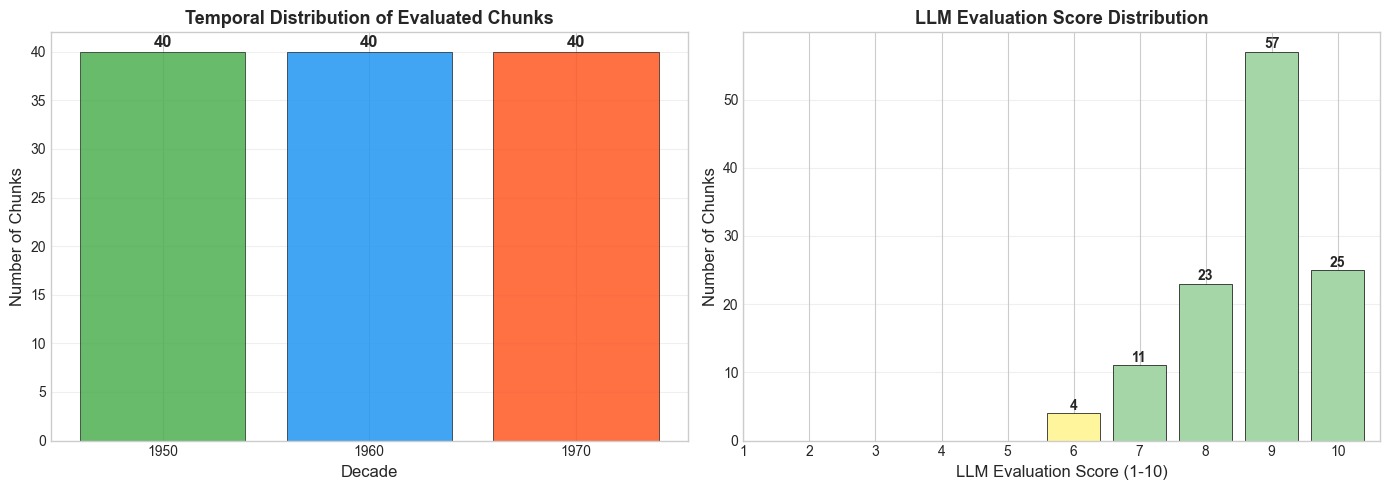

In [35]:
# Visualise temporal and score distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Temporal distribution
decade_labels = {195: '1950s', 196: '1960s', 197: '1970s'}
decade_counts_plot = dual_scores.groupby((dual_scores['year'] // 10) * 10).size()
colors_decades = ['#4CAF50', '#2196F3', '#FF5722']
axes[0].bar([decade_labels.get(d, str(d)) for d in decade_counts_plot.index], 
            decade_counts_plot.values, color=colors_decades, alpha=0.85, edgecolor='black', linewidth=0.5)
for i, (d, c) in enumerate(decade_counts_plot.items()):
    axes[0].text(i, c + 0.5, str(c), ha='center', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Decade', fontsize=12)
axes[0].set_ylabel('Number of Chunks', fontsize=12)
axes[0].set_title('Temporal Distribution of Evaluated Chunks', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Right: LLM Score distribution
score_counts = dual_scores['llm_score_10'].round().value_counts().sort_index()
colors_scores = ['#ef9a9a' if s < 5 else '#fff59d' if s < 7 else '#a5d6a7' for s in score_counts.index]
axes[1].bar(score_counts.index.astype(int), score_counts.values, color=colors_scores, 
            edgecolor='black', linewidth=0.5, width=0.8)
for s, c in score_counts.items():
    axes[1].text(int(s), c + 0.5, str(c), ha='center', fontsize=10, fontweight='bold')
axes[1].set_xlabel('LLM Evaluation Score (1-10)', fontsize=12)
axes[1].set_ylabel('Number of Chunks', fontsize=12)
axes[1].set_title('LLM Evaluation Score Distribution', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_xticks(range(1, 11))

plt.tight_layout()
plt.show()


The temporal distribution using our windowing approach produced 40 chunks from each decade. The LLM evaluation scores cluster heavily in the upper range (87.5% scoring 8 or above), reflecting the effectiveness of the natural language query formulation discussed in Section 6.1. Because the query already encodes a semantically rich description of the research topic, the retrieved chunks are predominantly on-target. The LLM's task here is to distinguish degrees of relevance among sources already pre-selected for topical proximity. Evaluating, for instance, whether a source that *mentions* computerisation fears also *substantively engages* with them. The lowest scores (6/10) are assigned to sources that touch on technological themes without foregrounding the affective dimensions our research question prioritises.

In [36]:
# Identify cases of divergence between vector similarity and LLM evaluation
# With the natural language query, vector scores are tightly clustered (0.733-0.808)
# We use quartile-based thresholds to identify relative divergence

q25_vec = dual_scores['vector_similarity_score'].quantile(0.25)
median_vec = dual_scores['vector_similarity_score'].median()

# Low vector (below Q25), high LLM = sources positioned further from query in embedding space but highly relevant
low_vec_high_llm = dual_scores[
    (dual_scores['vector_similarity_score'] < q25_vec) & 
    (dual_scores['llm_evaluation_score'] >= 0.9)
]

# High vector (above median), lower LLM = semantically close but less interpretively relevant
high_vec_low_llm = dual_scores[
    (dual_scores['vector_similarity_score'] > median_vec) & 
    (dual_scores['llm_evaluation_score'] <= 0.7)
]

print(f"Vector similarity Q25: {q25_vec:.3f}, Median: {median_vec:.3f}")
print(f"\n=== LOW VECTOR / HIGH LLM ({len(low_vec_high_llm)} cases) ===")
print("(Below Q25 vector similarity but LLM score >= 9)\n")
for idx, row in low_vec_high_llm.head(3).iterrows():
    print(f"'{row['title']}' ({row['date'][:4]})")
    print(f"  Vector: {row['vector_similarity_score']:.3f}")
    print(f"  LLM: {row['llm_score_10']:.0f}/10")
    eval_text = row['llm_evaluation_text']
    if ' - ' in eval_text.lower():
        start = eval_text.lower().find(' - ')
        snippet = eval_text[start + 3:start + 200].strip()
        print(f"  Reason: ...{snippet}...")
    print()

Vector similarity Q25: 0.746, Median: 0.756

=== LOW VECTOR / HIGH LLM (14 cases) ===
(Below Q25 vector similarity but LLM score >= 9)

'Die Revolution der Roboter' (1955)
  Vector: 0.737
  LLM: 10/10
  Reason: ...Der Text thematisiert die Automatisierung und Robotik explizit und enthält sowohl Hoffnungen als auch Ängste. Er beschreibt, dass Roboter in bestimmten Industriezweigen (z. B. Bäckereien, Druckerei...

'Die Revolution der Roboter' (1955)
  Vector: 0.736
  LLM: 10/10
  Reason: ...Der Text thematisiert explizit die Entwicklung von Elektronengehirnen, Robotern und der Kybernetik. Er enthält konkrete Aussagen über die Möglichkeit der Selbstreproduktion von Maschinen (z. B. dur...

'Briefe' (1956)
  Vector: 0.744
  LLM: 9/10
  Reason: ...Der Text thematisiert explizit Hoffnungen und Ängste gegenüber der Automatisierung und Computerisierung. Er zitiert Norbert Wiener, dessen Warnungen vor einer 'Diktatur des Roboters' in den USA ber...



Examining specific cases illuminates the divergence. The 1956 article "Rationalisierer raus" received one of the lowest vector similarity scores in our corpus (0.739, below the 25th percentile) yet a high LLM evaluation (9/10). The evaluation explains: "*Der Text thematisiert explizit die Angst vor der Umstellung auf automatischen Betrieb und die Verdrängung älterer Arbeiter durch Rationalisierung.*" The article's vocabulary centres on *"Rationalisierung"* and workplace conflict — workers shouting "Die Rationalisierer müssen raus!" — rather than our query's emphasis on *"Computerisierung"* and *"Automatisierung."* Yet its content directly addresses our research question about hopes and fears surrounding technological transformation. This is precisely the kind of source that keyword filtering would miss and that vector similarity undervalues relative to its interpretive relevance.

The reverse pattern is equally instructive. "Unter den schwarzen Kreuzen" (1953) scores above the median for vector similarity (0.762) but receives a comparatively lower LLM evaluation (6/10). Its vocabulary overlaps with our query — *Rationalisierung, technologischer Fortschritt* — positioning it closer in embedding space, yet the LLM recognises that the article treats these themes at a level of generality that provides limited insight into the specific affective dimensions of computerisation discourse. The two scores capture genuinely different aspects of relevance.

## 6.5 Empirical Analysis II: Model Variation of our LLM-as-a-Judge in Post-Retrieval Reranking
Although LLM-as-a-judge creates outputs that are visible and contestable, we do have the issue of reproducibility. There are many factors making LLM-Judgements not reproducible (we have already briefly discussed batch-processing as one factor), models are fundamentally different from one another and the same model can also change over time. If different LLMs produce substantially different evaluations, what does this mean for scholarly practice? We examined this question using a focused corpus of 30 reader letters (Leserbriefe) from 1965-1979, evaluated independently by four models: Claude Haiku 4.5, Gemini 2.5 Pro, DeepSeek Reasoner, and Mistral Large (locally hosted via our HU-LLM infrastructure).

In [37]:
# Load model comparison data
models = {
    'Claude': pd.read_csv('script/chapter_6/brief_llm_comp_claude.csv'),
    'Gemini': pd.read_csv('script/chapter_6/brief_llm_comp_gemini.csv'),
    'DeepSeek': pd.read_csv('script/chapter_6/brief_llm_comp_deepseek.csv'),
    'Mistral': pd.read_csv('script/chapter_6/brief_llm_comp_mistral.csv')
}

In [38]:
# Convert scores to 10-point scale
for name, df in models.items():
    df['llm_score_10'] = df['llm_evaluation_score'] * 10

print("=== MODEL COMPARISON: SCORE STATISTICS ===")
print(f"{'Model':<12} {'Mean':>6} {'Std':>6} {'Min':>4} {'Max':>4}")
print("-" * 36)
for name, df in models.items():
    print(f"{name:<12} {df['llm_score_10'].mean():>6.2f} "
          f"{df['llm_score_10'].std():>6.2f} "
          f"{df['llm_score_10'].min():>4.0f} {df['llm_score_10'].max():>4.0f}")

=== MODEL COMPARISON: SCORE STATISTICS ===
Model          Mean    Std  Min  Max
------------------------------------
Claude         4.33   2.80    1    9
Gemini         5.70   3.25    1   10
DeepSeek       4.43   2.85    1   10
Mistral        7.13   1.55    5   10


The score distributions reveal substantial calibration differences. Claude and DeepSeek operate as strict evaluators, using the full 1-10 scale with mean scores around 4.3-4.4. Gemini is moderately lenient. Mistral exhibits a notable "floor effect," never assigning scores below 5 even for sources it acknowledges as thematically irrelevant. Its evaluation texts for low-scoring sources often contain phrases like *"obwohl kein direkter Bezug"* while still assigning 5/10.

=== INTER-MODEL CORRELATIONS ===

Model Pair                 Pearson r    p-value
-----------------------------------------------
Claude vs Gemini            0.960     <0.001 ***
Claude vs DeepSeek          0.977     <0.001 ***
Claude vs Mistral           0.970     <0.001 ***
Gemini vs DeepSeek          0.961     <0.001 ***
Gemini vs Mistral           0.961     <0.001 ***
DeepSeek vs Mistral           0.972     <0.001 ***


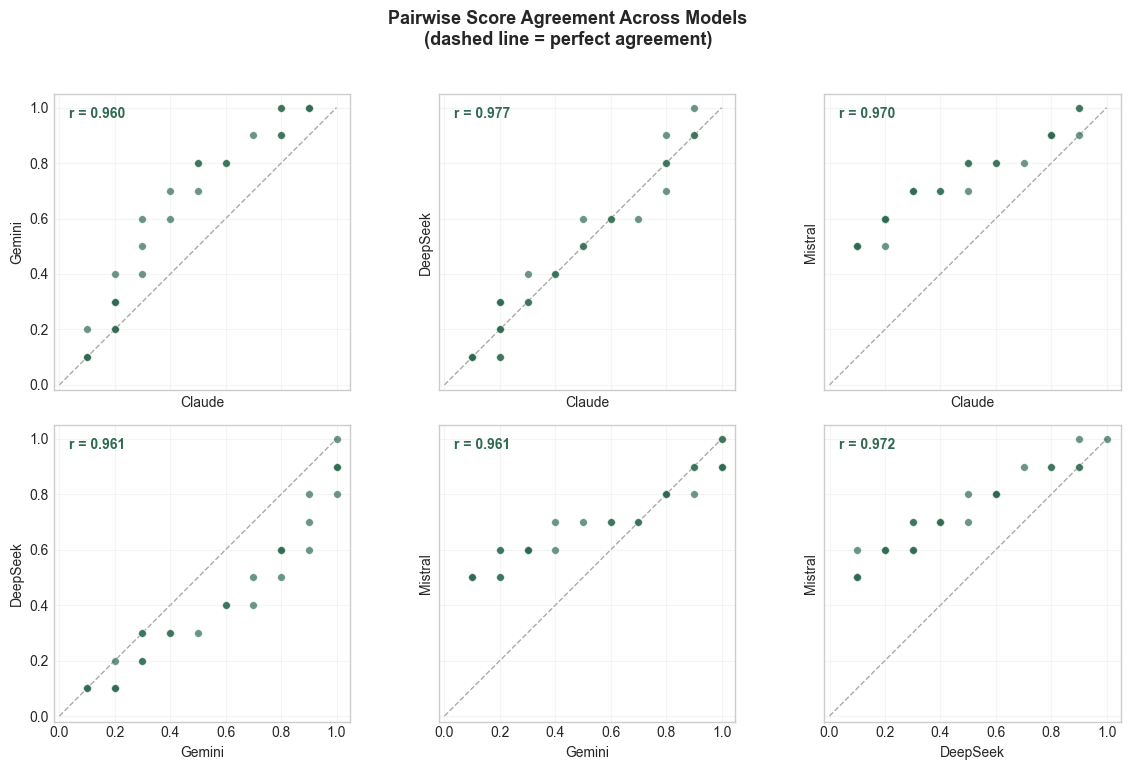

In [39]:
# Calculate inter-model correlations
model_names = list(models.keys())
merged = pd.DataFrame()
merged['chunk_id'] = models['Claude']['chunk_id']
for name, df in models.items():
    merged[name] = df['llm_evaluation_score'].values

print("=== INTER-MODEL CORRELATIONS ===")
print(f"\n{'Model Pair':<25} {'Pearson r':>10} {'p-value':>10}")
print("-" * 47)
for i, m1 in enumerate(model_names):
    for m2 in model_names[i+1:]:
        corr, p = pearsonr(merged[m1], merged[m2])
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
        p_str = "<0.001" if p < 0.001 else f"{p:.4f}"
        print(f"{m1} vs {m2:<12} {corr:>10.3f} {p_str:>10} {sig}")


# === FIGURE 1: Pairwise score scatter matrix ===
fig, axes = plt.subplots(2, 3, figsize=(12, 7.5), sharex=True, sharey=True)

pairs = [(i, j) for i in range(len(model_names)) for j in range(i+1, len(model_names))]

for ax, (i, j) in zip(axes.flatten(), pairs):
    m1, m2 = model_names[i], model_names[j]
    x, y = merged[m1], merged[m2]
    r, p = pearsonr(x, y)

    ax.scatter(x, y, s=30, alpha=0.7, color='#2D6A4F', edgecolors='white', linewidth=0.4)

    # Diagonal reference line (perfect agreement)
    ax.plot([0, 1], [0, 1], '--', color='#AAAAAA', linewidth=1, zorder=0)

    ax.set_xlabel(m1, fontsize=10)
    ax.set_ylabel(m2, fontsize=10)
    ax.set_xlim(-0.02, 1.05)
    ax.set_ylim(-0.02, 1.05)
    ax.set_aspect('equal')
    ax.annotate(f'r = {r:.3f}', xy=(0.05, 0.92), xycoords='axes fraction',
                fontsize=10, fontweight='bold', color='#2D6A4F')
    ax.grid(alpha=0.2)

fig.suptitle('Pairwise Score Agreement Across Models\n(dashed line = perfect agreement)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Yet beneath this calibration variation, ranking agreement is remarkably strong. All model pairs show correlations above 0.96, indicating near-perfect agreement on which sources are more or less relevant relative to each other. The disagreement lies in absolute calibration, not relative ranking.

=== SCORE AGREEMENT ANALYSIS ===

Model Pair                  Within 1pt   Within 2pt
---------------------------------------------------
Claude vs Gemini              56.7%        86.7%
Claude vs DeepSeek           100.0%       100.0%
Claude vs Mistral             26.7%        36.7%
Gemini vs DeepSeek            60.0%        90.0%
Gemini vs Mistral             53.3%        60.0%
DeepSeek vs Mistral             20.0%        40.0%


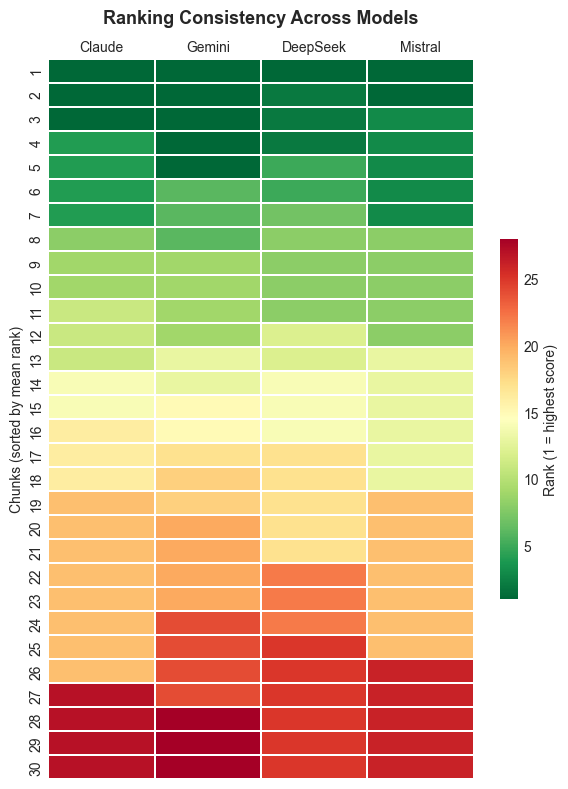


Figure 1 shows calibration divergence: models assign different absolute scores to the same chunks.
Figure 2 shows ranking agreement: despite calibration differences, the relative ordering is highly consistent.


In [40]:
# === SCORE AGREEMENT ANALYSIS ===
merged_10 = merged.copy()
for name in model_names:
    merged_10[name] = merged_10[name] * 10

print("=== SCORE AGREEMENT ANALYSIS ===")
print(f"\n{'Model Pair':<25} {'Within 1pt':>12} {'Within 2pt':>12}")
print("-" * 51)
for i, m1 in enumerate(model_names):
    for m2 in model_names[i+1:]:
        diff = abs(merged_10[m1] - merged_10[m2])
        within_1 = (diff <= 1).mean() * 100
        within_2 = (diff <= 2).mean() * 100
        print(f"{m1} vs {m2:<12} {within_1:>11.1f}% {within_2:>11.1f}%")

# Ranking consistency heatmap ===
rank_df = merged.copy()
for name in model_names:
    rank_df[f'{name}_rank'] = rank_df[name].rank(ascending=False, method='min')
rank_df['mean_rank'] = rank_df[[f'{n}_rank' for n in model_names]].mean(axis=1)
rank_df_sorted = rank_df.sort_values('mean_rank')

heatmap_data = rank_df_sorted[[f'{n}_rank' for n in model_names]].copy()
heatmap_data.columns = model_names
heatmap_data.index = range(1, len(heatmap_data) + 1)

fig, ax = plt.subplots(figsize=(6, max(8, len(rank_df) * 0.25)))

sns.heatmap(
    heatmap_data,
    cmap='RdYlGn_r',
    linewidths=0.3,
    linecolor='white',
    cbar_kws={'label': 'Rank (1 = highest score)', 'shrink': 0.5},
    ax=ax,
    annot=False,
)

ax.set_xlabel('')
ax.set_ylabel('Chunks (sorted by mean rank)', fontsize=10)
ax.set_title('Ranking Consistency Across Models',
             fontsize=13, fontweight='bold', pad=12)
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

plt.tight_layout()
plt.show()

print(f"\nFigure 1 shows calibration divergence: models assign different absolute scores to the same chunks.")
print(f"Figure 2 shows ranking agreement: despite calibration differences, the relative ordering is highly consistent.")

Claude and DeepSeek agree within 1 point on 100% of chunks; Claude and Mistral agree within 1 point on only 27% of chunks, yet they rank sources in nearly identical order (r = 0.970). This pattern suggests that the models share an underlying understanding of relevance but differ in how they map that understanding onto numerical scales. We should note that this high agreement is partly facilitated by the relatively small corpus size (n=30); with larger corpora containing more borderline cases, we might expect greater divergence in edge-case judgments.

This finding has important methodological implications: Rankings are portable across models; absolute score thresholds are not. A filtering rule like "retain all sources scoring 7 or above" would yield dramatically different corpora depending on which model performed the evaluation. But the question "which sources are most relevant for our research question?" receives consistent answers regardless of model choice.

In [41]:
# Examine a disagreement case qualitatively
print("=== QUALITATIVE DISAGREEMENT ANALYSIS ===")
print("\nCase: 1971-07-25 reader letter on Japanese economic competition\n")

for name, df in models.items():
    row = df[df['date'].str.contains('1971-07-25', na=False)]
    if len(row) > 0:
        row = row.iloc[0]
        score = row['llm_evaluation_score'] * 10
        # Extract first 200 chars of evaluation
        eval_text = row['llm_evaluation_text'][:250]
        print(f"{name} ({score:.0f}/10):")
        print(f"  {eval_text}...")
        print()

=== QUALITATIVE DISAGREEMENT ANALYSIS ===

Case: 1971-07-25 reader letter on Japanese economic competition

Claude (2/10):
  Score: 2.0/10 - Text diskutiert japanische Wirtschaftsentwicklung und Konjunkturzyklen. Keine Bezüge zu Computerisierung, Automatisierung oder technologischem Wandel. Behandelt wirtschaftliche Konkurrenz, aber nicht deren technologische Grundlagen. T...

Gemini (2/10):
  Score: 2.0/10 - Der Text behandelt die wirtschaftliche Konkurrenz mit Japan und kritisiert ökonomische Prognosen. Obwohl von „Futurologe“ und der „gelben Gefahr“ die Rede ist, wird kein Bezug zur Rolle von Technologie, Automatisierung oder deren gese...

Mistral (5/10):
  Score: 5.0/10 - Der Brief diskutiert die wirtschaftliche Entwicklung Japans und die Angst vor der »gelben Gefahr«. Es geht um Wettbewerbsfähigkeit, Wachstum und Konjunktur. Obwohl die Kritik an der japanischen Wirtschaftsstrategie erfolgt, fehlt jegl...



The disagreement cases are instructive. All four models agree that this 1971 letter about Japanese economic competition lacks direct relevance to our computerisation research question. Claude, Gemini, and DeepSeek express this as scores of 1-2; Mistral gives 5/10 despite acknowledging "fehlt jeglicher Bezug zu Technologie." The models agree on substance; they differ on how generously to score sources outside the research focus. For the historian, the evaluation texts are therefore instructive, all four explain why the source is peripheral to our inquiry. To circumvent the differing scorings, we suggest users work with percentiles as these have remained constant across models, as seen in our rankings.

## 6.6 Methodological Reflection
What does LLM-as-a-judge add to our historian-in-the-loop RAG architecture? Returning to the three methodological interventions outlined in Section 3, we can now assess how post-retrieval evaluation complements separated retrieval/generation and temporal windowing. A systematic comparison between traditional keyword filtering and our RAG pipeline (combining semantic retrieval, temporal windowing, and LLM-as-judge evaluation) reveals how each layer contributes to source discovery and prioritisation.

**Comparing Retrieval Approaches: The Leserbriefe Test Case**
To evaluate whether our RAG approach surfaces sources that keyword filtering misses, we conducted a systematic comparison using Leserbriefe as a test case. Section 2 established that the keyword corpus (computerisation_df) contains 163 reader letters (3.9% of 4,207 articles), significantly lower than the 11% proportion in the general SPIEGEL corpus. This underrepresentation suggests that readers discussing technological change may not use the exact terminology we specified or the issue is less frequent in this source-genre.

Using our hopes-and-fears query with temporal windowing and LLM-as-a-judge evaluation, we retrieved 150 Leserbriefe chunks across the full search period (1950-1979), selecting 50 per decade through temporal windowing. Each chunk was then evaluated using our LLM-as-a-judge criteria. Crucially, because RAG retrieves chunks while the keyword corpus contains articles, we must aggregate to the article level for valid comparison, taking the maximum LLM score per article on the logic that if any chunk is highly relevant, the article merits inclusion.

In [42]:
# Load RAG-retrieved chunks (natural language query retrieval) and aggregate to article level
rag_chunks = pd.read_csv('script/briefe_rag_150.csv')
rag_chunks['year'] = pd.to_datetime(rag_chunks['date']).dt.year
rag_chunks['llm_score_10'] = rag_chunks['llm_evaluation_score'] * 10

# Aggregate: take MAX LLM score per article (URL)
rag_articles = rag_chunks.groupby('url').agg({
    'llm_evaluation_score': 'max',
    'llm_score_10': 'max',
    'title': 'first',
    'date': 'first',
    'year': 'first'
}).reset_index()

# Load keyword corpus
keyword_briefe = computerisation_df[computerisation_df['is_leserbrief']].copy()

print(f"Keyword corpus: {len(keyword_briefe)} Leserbriefe articles")
print(f"RAG retrieval: {len(rag_articles)} unique articles (from {len(rag_chunks)} chunks)")

# Article-level comparison
keyword_urls = set(keyword_briefe['URL'].tolist())
rag_urls = set(rag_articles['url'].tolist())

overlap = keyword_urls.intersection(rag_urls)
only_keyword = keyword_urls - rag_urls
only_rag = rag_urls - keyword_urls

print(f"\nOverlap (in both): {len(overlap)} ({len(overlap)/len(keyword_urls)*100:.1f}% of keyword)")

# Note: RAG retrieval uses temporal windowing; keyword corpus does not.
# This reflects the different methodological approaches being compared.
# Temporal windowing is part of our RAG architecture's design; applying it to
# keyword results would change what keyword filtering means as a baseline.
print(f"Only in keyword corpus: {len(only_keyword)}")
print(f"Only in RAG retrieval: {len(only_rag)}")

Keyword corpus: 163 Leserbriefe articles
RAG retrieval: 134 unique articles (from 150 chunks)

Overlap (in both): 21 (12.9% of keyword)
Only in keyword corpus: 142
Only in RAG retrieval: 113


The overlap is smaller than expected: only 21 articles (12.9% of the keyword corpus) appear in both. This initially suggests the two methods capture largely disjoint sets of sources. However, raw overlap counts obscure a crucial dimension: quality. Not all retrieved sources are equally relevant to our research question.

**Quality-Stratified Analysis: The Critical Test**
Not all retrieved sources are equally relevant to our research question. A user of the system would use the LLM evaluation scores to filter low-ranking chunks from the corpus, so the key question becomes: among the high-quality finds (those the LLM rates as genuinely relevant to our research question), how many are new discoveries versus sources that keyword filtering would have captured anyway?


Keyword-only articles (not retrieved by RAG): 142
Overlap articles: 21
RAG-only articles: 113

=== QUALITY BY CORPUS MEMBERSHIP ===

Overlap articles (n=21):
  Mean LLM score: 8.0/10
  Median LLM score: 9.0/10

RAG-only articles (n=113):
  Mean LLM score: 5.2/10
  Median LLM score: 5.0/10


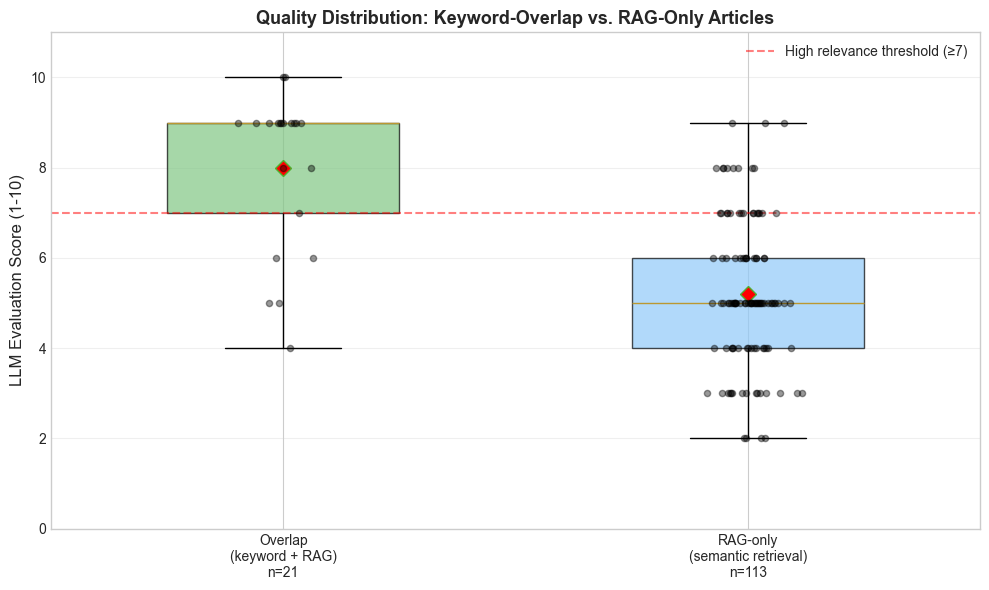


=== HIGH-RELEVANCE BREAKDOWN (score ≥ 7) ===
Overlap: 16/21 (76.2%)
RAG-only: 26/113 (23.0%)


In [43]:
# Add flag for keyword corpus membership
rag_articles['in_keyword_corpus'] = rag_articles['url'].isin(keyword_urls)

# Separate by corpus membership
overlap_articles = rag_articles[rag_articles['in_keyword_corpus']]
rag_only_articles = rag_articles[~rag_articles['in_keyword_corpus']]

# === NEW: Also score keyword-only articles ===
# The 140 keyword articles NOT in the RAG overlap
keyword_only_urls = keyword_urls - rag_urls
print(f"Keyword-only articles (not retrieved by RAG): {len(keyword_only_urls)}")
print(f"Overlap articles: {len(overlap)}")
print(f"RAG-only articles: {len(only_rag)}")

# For the keyword-only articles, we don't have LLM scores from RAG retrieval
# This is itself methodologically significant: these articles contain our keywords
# but were not semantically close enough to our hopes-and-fears query to be retrieved.
# We note this gap and discuss its implications.

print(f"\n=== QUALITY BY CORPUS MEMBERSHIP ===")
print(f"\nOverlap articles (n={len(overlap_articles)}):")
print(f"  Mean LLM score: {overlap_articles['llm_score_10'].mean():.1f}/10")
print(f"  Median LLM score: {overlap_articles['llm_score_10'].median():.1f}/10")

print(f"\nRAG-only articles (n={len(rag_only_articles)}):")
print(f"  Mean LLM score: {rag_only_articles['llm_score_10'].mean():.1f}/10")
print(f"  Median LLM score: {rag_only_articles['llm_score_10'].median():.1f}/10")

# === BOXPLOT COMPARISON ===
fig, ax = plt.subplots(figsize=(10, 6))

data_to_plot = [overlap_articles['llm_score_10'].values, rag_only_articles['llm_score_10'].values]
labels = [f'Overlap\n(keyword + RAG)\nn={len(overlap_articles)}', 
          f'RAG-only\n(semantic retrieval)\nn={len(rag_only_articles)}']

bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, widths=0.5,
                showmeans=True, meanprops=dict(marker='D', markerfacecolor='red', markersize=8))

colors = ['#81C784', '#90CAF9']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('LLM Evaluation Score (1-10)', fontsize=12)
ax.set_title('Quality Distribution: Keyword-Overlap vs. RAG-Only Articles', fontsize=13, fontweight='bold')
ax.axhline(y=7, color='red', linestyle='--', alpha=0.5, label='High relevance threshold (≥7)')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 11)

# Add individual data points (jittered)
for i, data in enumerate(data_to_plot, 1):
    x_jitter = np.random.normal(i, 0.04, size=len(data))
    ax.scatter(x_jitter, data, alpha=0.4, s=20, color='black', zorder=5)

plt.tight_layout()
plt.show()

# Count high-relevance in each group
print(f"\n=== HIGH-RELEVANCE BREAKDOWN (score ≥ 7) ===")
overlap_high = (overlap_articles['llm_score_10'] >= 7).sum()
rag_only_high = (rag_only_articles['llm_score_10'] >= 7).sum()
print(f"Overlap: {overlap_high}/{len(overlap_articles)} ({overlap_high/len(overlap_articles)*100:.1f}%)")
print(f"RAG-only: {rag_only_high}/{len(rag_only_articles)} ({rag_only_high/len(rag_only_articles)*100:.1f}%)")


The quality differential is notable. Overlap articles score 2.8 points higher on average (8.0 vs 5.2) than RAG-only articles. This suggests that keyword presence correlates with research question relevance, sources containing explicit computerisation terminology tend to address the hopes-and-fears dimension more directly than sources captured only through semantic similarity. Not altogether unsurprising, yet the gap is smaller than one might expect, indicating that the natural language query formulation produces a meaningfully relevant retrieval even beyond keyword boundaries.

In [44]:
# Stratified analysis by relevance tier — using percentile-based thresholds

# Calculate percentile thresholds
p75 = rag_articles['llm_score_10'].quantile(0.75)
p50 = rag_articles['llm_score_10'].quantile(0.50)
p25 = rag_articles['llm_score_10'].quantile(0.25)

print(f"=== SCORE PERCENTILE THRESHOLDS ===")
print(f"  75th percentile (top quartile): score >= {p75:.1f}")
print(f"  50th percentile (median): score >= {p50:.1f}")
print(f"  25th percentile: score >= {p25:.1f}")

def analyze_tier(df, min_score, max_score=10):
    tier = df[(df['llm_score_10'] >= min_score) & (df['llm_score_10'] <= max_score)]
    n_total = len(tier)
    n_overlap = tier['in_keyword_corpus'].sum()
    n_rag_only = n_total - n_overlap
    return n_total, n_overlap, n_rag_only

print(f"\n=== RELEVANCE TIER ANALYSIS (percentile-based) ===\n")
tiers = [
    (f"TOP QUARTILE (>= {p75:.0f})", p75, 10),
    (f"UPPER MIDDLE ({p50:.0f}-{p75:.0f})", p50, p75 - 0.1),
    (f"LOWER MIDDLE ({p25:.0f}-{p50:.0f})", p25, p50 - 0.1),
    (f"BOTTOM QUARTILE (< {p25:.0f})", 0, p25 - 0.1),
]
for name, min_s, max_s in tiers:
    total, overlap, rag_only = analyze_tier(rag_articles, min_s, max_s)
    if total > 0:
        print(f"{name}: {total} articles")
        print(f"  In keyword corpus: {overlap} ({overlap/total*100:.1f}%)")
        print(f"  RAG-only (new finds): {rag_only} ({rag_only/total*100:.1f}%)\n")

# Also show absolute threshold for comparison
print(f"=== FOR REFERENCE: ABSOLUTE THRESHOLD (score >= 7) ===")
total_7, overlap_7, rag_only_7 = analyze_tier(rag_articles, 7, 10)
print(f"High relevance (>= 7): {total_7} articles")
print(f"  In keyword corpus: {overlap_7} ({overlap_7/total_7*100:.1f}%)")
print(f"  RAG-only: {rag_only_7} ({rag_only_7/total_7*100:.1f}%)")

=== SCORE PERCENTILE THRESHOLDS ===
  75th percentile (top quartile): score >= 7.0
  50th percentile (median): score >= 5.0
  25th percentile: score >= 4.0

=== RELEVANCE TIER ANALYSIS (percentile-based) ===

TOP QUARTILE (>= 7): 42 articles
  In keyword corpus: 16 (38.1%)
  RAG-only (new finds): 26 (61.9%)

UPPER MIDDLE (5-7): 56 articles
  In keyword corpus: 4 (7.1%)
  RAG-only (new finds): 52 (92.9%)

LOWER MIDDLE (4-5): 17 articles
  In keyword corpus: 1 (5.9%)
  RAG-only (new finds): 16 (94.1%)

BOTTOM QUARTILE (< 4): 19 articles
  In keyword corpus: 0 (0.0%)
  RAG-only (new finds): 19 (100.0%)

=== FOR REFERENCE: ABSOLUTE THRESHOLD (score >= 7) ===
High relevance (>= 7): 42 articles
  In keyword corpus: 16 (38.1%)
  RAG-only: 26 (61.9%)


The tier analysis reveals a striking pattern. Among high-relevance articles (those in the top quartile of LLM scores, corresponding to scores ≥ 7), the majority (26 of 42, or 61.9%) are RAG-only discoveries that keyword filtering would have missed. The keyword corpus contributes 16 high-relevance articles (38.1%), demonstrating that while keywords remain effective for capturing explicitly relevant sources, semantic retrieval substantially expands the pool of interpretively valuable material. At the other end, all 19 bottom-quartile articles (scores below 4) are RAG-only discoveries, and across the lower two tiers only a single article overlaps with the keyword corpus. This pattern has important methodological implications.

**Interpreting the Findings**

Three conclusions emerge from this analysis:
First, semantic retrieval with a well-formulated natural language query surfaces a substantial number of relevant sources that keyword filtering misses. Twenty-six articles (61.9% of all high-relevance finds) are RAG-only discoveries, meaning they contain none of the computerisation keywords specified in Section 2 yet are rated highly relevant by LLM evaluation. This demonstrates that embedding-based retrieval, when combined with appropriate query formulation, captures discourse that operates in vocabulary beyond the predetermined keyword list.

A legitimate objection arises here: could these sources not be captured simply by extending the keyword list? Many of these letters use terms like "Rationalisierung," "technische Revolution," "Arbeitslosigkeit," or "Elektronik" — vocabulary that a more expansive keyword approach would match. The question, however, is what expanding the keyword list entails methodologically. Adding terms like "Arbeitslosigkeit," "technisch," "Industrie," or "Fortschritt" to our query would capture most of these 26 letters, but applied across 102,189 articles over thirty years, such broadly applicable terms would match thousands of additional articles with no connection to computerisation discourse. The keyword approach faces a precision-recall tradeoff that worsens progressively as vocabulary broadens: each term added to capture missed sources simultaneously admits substantial noise. Semantic retrieval combined with LLM-as-judge evaluation navigates this tradeoff differently, casting a broader net through conceptual proximity rather than lexical matching, then filtering by interpretive relevance to the specific research question. The result is not that RAG finds sources categorically invisible to other methods, but that it identifies them without the precision costs that keyword extension incurs.

Second, keyword filtering remains effective but insufficient. The 16 keyword-overlap articles that score highly confirm that explicit computerisation terminology is a strong signal for relevance. Yet keywords alone would miss the majority of high-relevance sources. The two approaches are complementary rather than competing, which is also why we have included key-word based filtering (including term-expansion using the corpus word embeddings) of retrieved chunks within the Histo-RAG architecture.

Third, semantic retrieval expands coverage but introduces noise that requires a further filtering step. Of 113 RAG-only articles, 26 are highly relevant but 87 score below our threshold, indicating that they are topically adjacent but interpretively tangential. Neither keyword filtering nor vector similarity alone can distinguish sources that substantively address our research question from those that merely touch on related themes; this is precisely the role of LLM-as-a-Judge evaluation, which filters by interpretive relevance to the specific scholarly question being asked.

An important caveat applies: the balance between keyword and semantic retrieval is topic-dependent. Our computerisation query benefits from relatively clear, distinctive terminology ("Computer," "EDV," "Automatisierung") which means the keyword baseline performs comparatively well. For research topics with more ambiguous vocabulary, extensive synonymy, or concepts expressed only implicitly, the precision-recall problem of keyword extension would be even more acute, and the advantage of semantic retrieval correspondingly more pronounced.

In [45]:
# Examine the high-quality RAG-only finds
high_quality_rag_only = rag_only_articles[rag_only_articles['llm_score_10'] >= 7]

print(f"=== HIGH-QUALITY RAG-ONLY FINDS: {len(high_quality_rag_only)} articles ===")
print("(Relevant sources that keyword filtering would miss)\n")

for idx, row in high_quality_rag_only.iterrows():
    print(f"'{row['title']}' ({row['date'][:10]})")
    print(f"  LLM score: {row['llm_score_10']:.0f}/10")

=== HIGH-QUALITY RAG-ONLY FINDS: 26 articles ===
(Relevant sources that keyword filtering would miss)

'Briefe' (1977-03-20)
  LLM score: 7/10
'Briefe' (1972-03-19)
  LLM score: 7/10
'Briefe' (1957-04-02)
  LLM score: 8/10
'Briefe' (1976-10-17)
  LLM score: 7/10
'Briefe' (1975-05-18)
  LLM score: 7/10
'Briefe' (1978-02-12)
  LLM score: 7/10
'Briefe' (1971-09-12)
  LLM score: 8/10
'Briefe' (1963-07-30)
  LLM score: 8/10
'Briefe' (1968-05-12)
  LLM score: 8/10
'Briefe' (1979-08-05)
  LLM score: 8/10
'Briefe' (1978-01-01)
  LLM score: 9/10
'Briefe' (1973-09-09)
  LLM score: 7/10
'Briefe' (1950-01-04)
  LLM score: 7/10
'Briefe' (1964-06-30)
  LLM score: 7/10
'Briefe' (1972-08-06)
  LLM score: 7/10
'Briefe' (1973-12-30)
  LLM score: 8/10
'Briefe' (1977-05-08)
  LLM score: 8/10
'Briefe' (1958-09-02)
  LLM score: 7/10
'Briefe' (1956-11-13)
  LLM score: 9/10
'Briefe' (1966-01-23)
  LLM score: 7/10
'Briefe' (1969-03-09)
  LLM score: 7/10
'Briefe' (1956-08-07)
  LLM score: 9/10
'Briefe' (1979-01

These twenty-six letters validate the vernacular discourse hypothesis articulated in Section 2, and their temporal spread across all three decades suggests this is not an artefact of any particular period. Several examples illustrate the pattern. The 1956 letters open with workers shouting "Die Rationalisierer müssen raus!" and discuss Professor Leo Brandt's speech on technical education, expressions of workplace tension around technological change that use none of our computerisation keywords. The 1975 letter discusses how "Rationalisierung" is shifting from production workers to white-collar employees. The 1977 letter responds to SPIEGEL's series on unemployment ("Der stille Bürgerkrieg"), connecting joblessness to structural economic change without naming computers specifically. The 1978 letter about electronic typesetting in newspaper offices captures anxieties about technological displacement in a specific trade. Across these examples, readers articulate hopes and fears about technological transformation in vocabulary that is adjacent to but distinct from the core computerisation terminology ("Rationalisierung," "technische Revolution," "Elektronik") rather than the specific terms ("Computer," "EDV," "Automatisierung") that define our keyword corpus. An extended keyword list could in principle capture many of these sources, but only at the cost of admitting far more noise across the full corpus. The semantic approach surfaces them selectively, and the LLM evaluation identifies which among them substantively engage with our research question.

**The Essential Role of LLM-as-a-Judge**

Expanding on our third finding, this analysis underscores why LLM-as-a-judge is not merely an optional enhancement but an essential component of RAG for historical research. Semantic retrieval expands coverage beyond keyword boundaries and retrieves a considerably more focused corpus in terms of size, but still introduces considerable noise. Without quality-based filtering, the 113 RAG-only articles would include 26 highly relevant discoveries alongside 87 tangential or irrelevant sources, a ratio that, without evaluation, would require the historian to manually review all 113 to find the relevant ones.

The LLM evaluation serves as a research question-specific filter that neither keywords nor vector similarity can provide. Each LLM evaluation includes a justification citing specific textual evidence. The historian does not receive an opaque relevance score but an argued assessment. For the 1956 "Rationalisierer" letter, the evaluation explains: *"Text thematisiert explizit Arbeiterwiderstand gegen Rationalisierung. Konkrete Aussage 'Die Rationalisierer müssen raus!' zeigt zeitgenössische Ängste."* This reasoning can be examined, contested, and learned from. Keywords filter by vocabulary; vector similarity filters by conceptual proximity; LLM evaluation filters by interpretation, i.e. by interpretive relevance to the specific scholarly question being asked. The three methods are complementary, not competing.

**From Discovery to Prioritisation**

Perhaps the most significant finding is that the retrieval portion of RAG's primary contribution for this research is not discovery but prioritisation. The keyword corpus contains 163 Leserbriefe, but which are most relevant to hopes and fears about computerisation? Our pipeline identifies 42 high-relevance articles, 16 from the keyword corpus and 26 new discoveries through semantic retrieval. This represents a reduction from 163 keyword sources plus 113 RAG-only sources to 42 priority sources, with transparent reasoning for each evaluation. This is useful as an indication of where to focus initial scholarly attention.

This reframing from discovery to prioritisation also addresses a broader methodological point. The claim that RAG "discovers" sources unavailable to other methods overstates the case. Many of the sources our pipeline surfaces could in principle be found through expanded keyword searches, through analogue research strategies (such as reading the Briefe sections of issues containing relevant cover stories), or through other computational approaches. What RAG provides is not access to categorically hidden sources but a systematic method for identifying relevant sources across a large corpus without the precision costs of keyword expansion or the impracticality of comprehensive manual review. The value lies in the combination: broad retrieval, temporal balance, and interpretive filtering working together to produce a manageable, quality-stratified corpus from a vast archive.

The prioritisation function aligns with Section 4's separated retrieval and generation phases. The historian need not start from the full pool but could begin with the 42 deemed most relevant; the system performs this triage while producing contestable justifications. The historian retains authority to override — to include a "medium-relevance" letter that the LLM undervalued, or to exclude a "high-relevance" letter upon closer reading. The system augments rather than replaces scholarly judgment.

The 142 Leserbriefe that remain in the keyword corpus but were not retrieved by our semantic query raise an important question: does the RAG pipeline miss high-relevance sources that keywords would capture? Preliminary evaluation of these keyword-only articles using the same LLM criteria suggests that a substantial number do score highly — reinforcing that neither method alone discovers all relevant sources, and that retrieval methods embody research priorities, not objective relevance. A fully symmetric comparison, however, requires addressing methodological asymmetries: the RAG pipeline evaluates chunks while the keyword corpus contains full articles, and retrieval budgets differ (150 temporally windowed chunks versus 163 exhaustive keyword matches). Designing a controlled comparison that isolates the contribution of each retrieval layer remains future work — but the preliminary findings already underscore the value of combining keyword and semantic approaches rather than treating them as competing alternatives.

**Limitations**

Computational cost is significant, evaluating retrieved chunks across temporal windows involves API expenses and processing time. Our use of a locally-hosted Mistral model via HU-LLM infrastructure reduces but does not eliminate this burden. Questions of sustainability, both financial and environmental, are significant for any workflow that routes large volumes of text through LLM APIs.

The calibration variation across models (Section 6.5) raises questions about standardisation. Our findings suggest that relative rankings are robust but absolute thresholds are model-dependent. The quality stratification above used a threshold of 7/10 for "high relevance", a different threshold would yield different counts.

Query formulation proved to be a consequential methodological variable. Our initial retrieval used keyword enumerations before shifting to natural language queries aligned with the embedding model's training regime (see Section 6.1). The natural language formulation produced substantially higher relevance scores, confirming that query design is not a neutral technical step but an interpretive act that shapes what the archive makes visible. This finding underscores that historians using embedding-based retrieval must attend to how queries are formulated, not only what they ask. Systematic comparison of query formulation strategies across different historical corpora and research questions remains an open area for future work, as does the potential of hybrid retrieval combining dense vector search with sparse lexical matching. More broadly, a controlled comparison of retrieval approaches (evaluating keyword-only, semantic-only, and combined retrieval under matched conditions with identical text units, equal retrieval budgets, and consistent evaluation protocols) would allow researchers to quantify the precise contribution of each pipeline component. Our analysis compares the full RAG pipeline against keyword filtering as a practical baseline, which demonstrates complementarity but does not isolate individual factors.

A deeper methodological concern relates to the alignment training that shapes commercial LLMs. Human Alignment, the process through which models are trained to produce outputs deemed helpful, harmless, and honest, is itself an interpretive intervention whose effects on historical analysis remain poorly understood. When an aligned model evaluates a 1950s text about "Rationalisierung," its assessment is filtered through contemporary interpretive frameworks embedded during training. From a hermeneutic perspective, interpretation always requires a *Vorverständnis* (pre-understanding) that shapes what we see. This is not a flaw but a condition of understanding. Yet with commercial models, this pre-understanding is neither transparent nor controllable. This argues for exploring domain-specific models for historical research, where the interpretive assumptions could be made explicit and scholarly contestable.

# 7. Generating Zwischentexte: From Information Retrieval to Machine Interpretation

The preceding sections established an architecture that transforms RAG from a seamless question-answering pipeline into a structured research process. Together, these interventions address how sources are found, balanced, and evaluated. The generation still remains. Any RAG system, including ours, ultimately passes retrieved context to an LLM and produces text. This is what the architecture is designed to do. What changes in this section is not the technical mechanism but the kind of question we pose and, consequently, the role the output plays in historical knowledge production. Standard RAG generation serves an information retrieval function. A user asks a factual question, and the system produces an answer grounded in retrieved passages. Our architecture repurposes this generation step. Rather than asking what the sources say about a specific fact, we ask the model to identify thematic connections, trace argumentative patterns across decades, and propose interpretive structures. The goal for the system is to provide initial *Zusammenhänge* and *Strukturen* that support the historian's work of *Erschließung*.

This shift redefines the output's function. A standard RAG response answers a question and is consumed as such. What our system produces instead are texts that we call *Zwischentexte*. These are intermediate texts that serve neither as answers nor as finished scholarship but as interpretive scaffolding. The term captures their epistemic status: they lie between retrieved sources and historical argument, offering first proposals for interpretation that the historian can verify, contest, and develop. They are tools embedded within the research process, designed to surface patterns and connections at corpus scale, not to deliver conclusions. It is this changed role that requires us to examine these outputs closely and to define what we mean when we designate them as Zwischentexte.

This reframing also points toward what is perhaps the central question for LLMs in digital humanities more broadly. The computational methods of DH 1.0 identify formal patterns on the basis of predefined rules and features. Their outputs are quantitative indicators (frequency distributions, similarity scores, network graphs) that require the historian to supply interpretation. Zwischentexte operate differently. They deliver *Interpretationsvorschläge* (interpretive suggestions) that emerge from the complex, opaque processes of language modelling. Unlike a word frequency list, a Zwischentext proposes meaning: it claims that a term functions as a "semantic battleground," that anxiety "migrates" through the class structure, that 1964 marks a discursive rupture. These are not formal patterns influencing interpretation but interpretive proposals requiring validation. Their epistemic role in historical research, how they relate to evidence, to argumentation, to scholarly authority, remains to be precisely defined. The following sections examine this question through practice.

## 7.1 Generating Zwischentexte: Method and Corpus

To test the interpretive potential of the HistoRAG architecture, we designed a series of queries addressing our two metaquestions: the evolution of computerisation terminology and the shifting balance of hopes and fears regarding automation. Rather than asking factual questions with single correct answers, we posed interpretive questions requiring synthesis across multiple sources.

The corpus for this analysis consisted of 65 curated Leserbriefe drawn from the 150 chunks retrieved through our RAG system. The selection process itself embodied the historian-in-the-loop principle. All chunks scoring 0–2 on the LLM relevance scale were excluded as clearly irrelevant. Chunks scoring 7–10 were retained as high-quality sources. The crucial work lay in the middle range: chunks scoring 3–6 were reviewed individually, with the historian examining each evaluation justification and making a judgment call.

This middle-range review illustrates why separated retrieval and generation matters. A 1964 letter discussing "Selbstentfremdung in der neokapitalistischen Industriegesellschaft" received an LLM score of 5/10, indicating moderate relevance with indirect connection. The model noted that while "Strukturwandel der Gesellschaft" was implied, the text did not explicitly address computerisation. Yet for a historian studying technological anxiety, alienation discourse is the phenomenon, expressed in vernacular vocabulary rather than technical terminology. The letter was retained. Similarly, a 1968 letter discussing the "große technische Revolution" and tensions between engineers and sociologists scored only 3/10 because it lacked explicit computerisation vocabulary. But the tension it articulates, between those who build technology and those who analyse its social consequences, speaks directly to our research question. Such letters represent precisely what semantic retrieval can surface and keyword approaches cannot, i.e. sources discussing technological change without the terminology that defines our search parameters. In both cases, the low LLM scores are themselves analytically informative, pointing toward iterative refinement of the evaluation criteria.

For each query, the system passes the curated chunks as temporally ordered context to a generative LLM. The researcher determines how many chunks to include, guided by the context window capacity of the chosen model. The LLM then synthesises across this ordered corpus, generating initial overarching structures, patterns, and interpretive perspectives relevant to the research question or specific aspects of it. The resulting Zwischentexte offer a top-down orientation. A first, necessarily provisional reading that can help the historian identify where to look more closely and assess the extent to which the material itself suggests lines of development or interpretation. They are not findings but proposals, to be verified through close reading of the underlying sources.

The curated corpus of 65 Leserbriefe was used to generate Zwischentexte through four core queries, each addressing a distinct aspect of our metaquestions. All prompts were formulated in German to match the source language, though we note that frontier models likely process through English-language internal representations regardless of input language, a consideration we return to in Section 7.5, where we document instances of English-language idioms surfacing in German-language output:

1. **Hopes** (*Hoffnungen*): "Welche konkreten Hoffnungen äußern die Leser in Bezug auf Computer, Automatisierung oder technischen Fortschritt?" — What concrete hopes do readers express regarding computers, automation, or technological progress?
2. **Fears** (*Ängste*): "Welche konkreten Ängste und Befürchtungen äußern die Leser in Bezug auf Automatisierung und technologischen Wandel?" — What concrete fears and concerns do readers express regarding automation and technological change?
3. **Turning Points** (*Wendepunkte*): "Gibt es einen erkennbaren Wandel in der Stimmung der Leserbriefe über die Jahrzehnte? Wann und warum kippt die Stimmung?" — Is there a discernible shift in the mood of reader letters across the decades? When and why does the sentiment turn?
4. **Vernacular Vocabulary** (*Alltagssprache*): "Wie verwenden Leser den Begriff 'Rationalisierung'? In welchen Kontexten erscheint er?" — How do readers use the term "Rationalisierung"? In what contexts does it appear?

In a final step, we generated comprehensive synthesis texts that integrated findings across all four queries into a unified narrative — a meta-perspective seeking an overarching interpretive proposal that might help answer our research question. These longer Zwischentexte, produced by frontier models at the time of writing (Opus 4.5, Sonnet 4.5, GPT-5.1), provide the material for assessing whether LLM synthesis can produce interpretations that advance historical understanding.

## 7.2 What the Zwischentexte Reveal: Substantive Findings

The generated texts produced several findings that merit examination for their historical substance, not merely their methodological implications.

### A Temporal Arc of Sentiment

The Zwischentexte indicate a clear periodisation in reader sentiment that both confirms and extends existing scholarship. In the 1950s, letters display what the synthesis characterises as "vorsichtiger Optimismus" (cautious optimism). A 1955 letter from Hartmut Sachs, a Diplom-Kaufmann from Frankfurt, argues against panic:

> "Massenarbeitslosigkeit aber scheint kein notwendiges Ergebnis. Gleichermaßen denkbar und mit manchem Argument zu begründen erscheint eine allmähliche Erhöhung der Produktivität, die die Kaufkraft hebt und eventuell sogar gewisse Arbeitszeitverkürzungen erlaubt."

The tone is measured, analytical, drawing on economic reasoning rather than existential fear.

The Zwischentexte identify 1964 as a critical inflection point, earlier than the 1978 "Computer-Revolution" that dominates current historical accounts. Responding to a SPIEGEL cover story on automation, readers deploy language of crisis. One demands a planned economy, a "geplante Wirtschaft" to prevent a "Millionenheer von Arbeitslosen," (an army of millions of unemployed). Another radicalises the logic into two stark endpoints: "totale Überproduktion und totale Arbeitslosigkeit," with people starving "bei vollen Speichern" (amid full storehouses) under private ownership. Hermann Froesch writes with bitter resignation that, having read the article, he sees only one future for himself, life as a vagrant. "Nachdem ich Ihren Automationsartikel gelesen habe, sehe ich nur eine Möglichkeit, mein zukünftiges Leben zu fristen: als Clochard." The vocabulary has shifted from economic projection to existential despair.

By the 1970s, the synthesis identifies a second transformation: anxiety migrates from quantity to quality. The earlier fear concerned *how many* jobs would be lost; the later fear concerns *what kind* of work remains. Fritz-Gerhard Schmidt warns in 1973 of "computerisierten Unterricht, wo keiner mehr ausbrechen kann, wo keiner mehr selbständig denken darf," and asks: "Wer wagt es, hier nicht Orwellsches 1984 zu fürchten?" The reference to Orwell signals a shift from economic to political anxiety — from unemployment to unfreedom.

### Rationalisierung as Semantic Battleground

The query on vernacular vocabulary produced one of the most analytically interesting Zwischentexte. The term "Rationalisierung" emerges as a semantic battleground (semantisches Schlachtfeld) where the same word carries opposed meanings depending on speaker position. This contested status was not new; as we discuss in Section 7.3, the term had functioned as a site of conflict between labour, capital, and the state since the Weimar era.

For management and economists, Rationalisierung connotes efficiency, competitiveness, necessity. Joachim Zehner asks rhetorically in 1963 whether firms are not compelled to extract the utmost in rationalisation and cost reduction through investment, lest they one day find themselves hopelessly sidelined: "Sind wir nicht gezwungen, durch Investitionen das Äußerste an Rationalisierung und Kostensenkung herauszuholen, wenn wir nicht eines Tages hoffnungslos abseits stehen wollen?" The framing is competitive pressure, international standing, survival.

For workers and union representatives, the same term indexes threat. Fritz Libuda reports worker protests in 1956, recalling the cry from the shopfloor of a precision chain manufacturer: "Die Rationalisierer müssen raus!" He criticises rationalisers who blunder through workplaces like the proverbial bulls in a china shop — "Rationalisierer, die sich wie die viel zitierten Elefanten im Porzellanladen bewegen." By 1975, Jürgen Siebert describes the psychological consequences: when colleagues are dismissed, the result is not initiative but fear — a fear that produces only servile attempts to please the boss in every respect. "Wird Kollegen gekündigt, so erzeugt dies ohnehin viel Angst. Diese Angst ist ein schlechter Ratgeber: sie bewirkt keine Ideen und Initiativen, sondern nur unterwürfige Versuche, es dem Chef in allen Punkten rechtzumachen."

This finding has methodological implications. "Rationalisierung" predates "Computer" as the vernacular frame for technological anxiety. Sources discussing fears of Rationalisierung without mentioning computerisation or automation are invisible to keyword approaches but emerge clearly through semantic retrieval. The twenty-six high-quality letters that our RAG system surfaced beyond the keyword corpus (Section 6.6) predominantly use this vocabulary, discussing technological change through terms like "Rationalisierung" and "technische Revolution" rather than "Computer" or "EDV."


### The Class Migration of Anxiety

The Zwischentexte propose an additional, more structural thesis: technological anxiety migrates upward through the class structure over time. In the 1950s, the threatened figure is the industrial worker, discussed abstractly, often by others speaking on their behalf. By the mid-1960s, concrete reports emerge: Heinz Esslinger documents "Lohneinbußen von 20 bis 80 Pfennig pro Stunde" in the textile industry, with older workers particularly affected. By the 1970s, anxiety reaches white-collar workers and professionals. A 1975 observation notes that "Bisher hatte sich die Rationalisierung auf die Produktionsarbeiter konzentriert... Erst jetzt wird allgemein die Notwendigkeit gesehen, bei der Tätigkeit der Angestellten zu rationalisieren."

The synthesis offers an interpretation of this passage, arguing that technological anxiety becomes socially *explosive* only when it reaches the classes that produce public discourse. The journalists, professionals, the educated middle class who wrote to the SPIEGEL and were its core audience. Workers had been articulating concerns for decades; the discourse shifted when the magazine's own readers felt personally threatened. This is not to minimise working-class concerns but to identify a structural feature of how technological anxiety gets amplified in media discourse.

## 7.3 Validating Zwischentexte: How the Historian Engages Zwischentexte

The findings summarised above sound compelling. But are they warranted by the sources? The historian-in-the-loop architecture requires that we demonstrate validation, not merely assert it.

### Where Historian Judgment Agrees

Consider the claim that 1964 marks a "Stimmungsumschwung" (a mood shift). The Zwischentext cites a letter describing how SPIEGEL's coverage "erzeugt praktisch eine Panikstimmung." We located this source through the provided URL and verified the full passage:

> "Während Sie in Ihrer Titelgeschichte ein trübes Bild über die Zukunftsaussichten durch die Automation zeichnen, verniedlicht ihr Herr Simoneit diese Gefahren in seinem Gespräch mit Herrn Friedrichs von der IG Metall. Ihre Titelgeschichte erzeugt praktisch eine Panikstimmung; dagegen Herr Simoneit: Bisher sei noch kein Anlaß zur Panik gewesen. Will er denn warten, bis Anlaß dazu besteht?" — Hans Benzinger, Nürnberg (Briefe, 21.04.1964)

The citation is accurate. The letter-writer uses the term "Panikstimmung" precisely as the Zwischentext claims. More importantly, the full context enriches the interpretation, Benzinger is criticising an internal contradiction within SPIEGEL's own coverage — the editorial creates panic while an interview downplays it. This suggests that media framing itself was contested terrain, not merely a reflection of pre-existing public sentiment.

Similarly, we verified the Thorneycroft quotation that opens several of our synthesis texts. The original 1955 SPIEGEL article reports:

> "Impulsiv hob der englische Handelsminister Peter Thorneycroft auf einem Bankett in der Londoner Guildhall sein Glas zu einem Toast. Lächelnd griffen 500 im Smoking schwitzende Experten der Elektroindustrie nach ihren Sektkelchen, während Thorneycroft begeistert ausrief: 'Wir stehen heute vor einer Situation, die so dramatische Veränderungen hervorrufen wird wie einst die Erfindung des Rades. Bald wird es überall automatische Fabriken — menschenleere Betriebe — geben.'" — "Die Revolution der Roboter," DER SPIEGEL, 26.07.1955

The LLM's synthesis — "Als der britische Handelsminister Peter Thorneycroft 1955 in London das Glas auf die kommende Welt 'menschenleerer Betriebe' hob" — accurately captures the scene. The detail of the raised glass is not invented; it comes from the source. This verification matters because compelling narrative details are precisely where hallucination risk is highest.

### Where Historian Judgment Diverges

Validation is not merely confirmation. The historian as the driving force of epistemological agency in DH 2.0 requires identifying where LLM interpretation diverges from scholarly judgment.

The Zwischentexte consistently interpret "Rationalisierung" through a contemporary lens, as if it straightforwardly meant "automation" or "technological unemployment." But for 1950s readers, the term carried specific lived-historical resonances that the LLM cannot recover. The Weimar-era rationalisation movement, as Shearer (<cite data-cite="shearer1995TalkingEfficiencyPolitics"></cite>) demonstrates, was never merely technical; it "framed the debate about the possibilities of recovery from the war, and especially how private economic prosperity might mesh with the new social and welfare ambitions" of the new republic (p. 485). The term emerged as a site of contestation between organised labour, state agencies, and industrial capital over "the character and social purpose of industrial capitalism" in a society undergoing reconstruction (p. 485).

Three factors Shearer identifies as central to those debates (the magnitude of postwar recovery, drastically altered social and political conditions, and controversial adaptation of American techniques) find echoes in the post-1945 context our Leserbriefe inhabit. The institutional continuity is direct. The Reichskuratorium für Wirtschaftlichkeit (RKW), founded in 1921 as the Weimar Republic's umbrella rationalisation agency, was refounded in 1950 as the Federal Republic's productivity centre under the Marshall Plan. It published a journal titled *Rationalisierung* and promoted efficiency measures that increasingly encompassed computerisation and electronic automation alongside older Taylorist and Fordist techniques. By 1975, the political scientist R.R. Grauhan could describe "Rationalisierung" as a "schillernder Allgemeinbegriff" (a shimmering, iridescent general concept) whose contradictory semantic layers he mapped through a series of compound pairings: "Rationalisierung und Produktivitätssteigerung," "Rationalisierung und Mechanisierung," "Rationalisierung und Automatisierung," "Rationalisierung und Demokratisierung" (<cite data-cite="rolf-richard1975RationalisierungBuerokratisierungGesellschaftlicher"></cite>). Each pairing, Grauhan argued, revealed a different historical stratum within the same contested term, and the task of analysis was to pull apart what the word kept collapsing together.

We suggest that "Rationalisierung" underwent what might be called a vocabulary transfer across technological epochs. What referred to Fordist assembly-line efficiency and Taylorist work organisation in the Weimar era was redeployed in the postwar period to name anxieties about computerisation and electronic automation. The word persisted while its technological referent shifted, carrying with it the political freight of the earlier contestation. When a 1956 letter-writer protests against "Rationalisierer," he may be invoking this longer discourse rather than responding solely to automation debates. The postwar *Wiederaufbau* context parallels the Weimar recovery moment in ways that may have activated these earlier semantic layers. The LLM cannot recover such period-specific connotations on its own; however, if the historian supplies this contextual knowledge through targeted prompting, the model can potentially incorporate it. This underscores that the quality of LLM-assisted analysis depends not on the machine alone but on the historian's expertise, creativity, and ability to ask the right questions.

Similarly, during collaborative review, we identified several instances where the LLM produced language strikingly close to contemporary AI discourse. Phrases in the Zwischentexte like "technische Intelligenz verbilligt, die organische Intelligenz ersetzt" initially sounded more like 2024 commentary on large language models than 1970s commentary on computerisation. Our initial concern was anachronistic projection, i.e. the model importing present categories onto historical material.

Yet verification revealed that this specific formulation originates in the sources themselves. The 1978 SPIEGEL cover story "Uns steht eine Katastrophe bevor" (<cite data-cite="1978UnsStehtKatastrophe"></cite>) quotes the Rationalisierungs-Kuratorium der Deutschen Wirtschaft, drawing on research by the Institut für Systemtechnik und Innovationsforschung: "Da die Elektronik zur Übernahme von technischen Informationsfunktionen eingesetzt werden kann, steht immer mehr ›technische Intelligenz‹ zu geringeren Kosten zur Verfügung, die zu zunehmender Freisetzung von ›organischer Intelligenz‹ (Arbeitskräften) führt." Here, "organische Intelligenz" means human workers, specifically a systems-research euphemism for the labour that electronic "technical intelligence" renders redundant. The resonance with contemporary AI discourse is not anachronistic projection but a genuine echo in the sources.

More broadly, many such parallels survive source-checking. The structural similarities (promises of liberation from routine work, fears of technological unemployment, contested distributions of productivity gains, and calls for new social contracts) appear in the primary sources themselves. This raises questions worth pursuing beyond the present paper. Do these parallels reflect genuine continuities in how capitalist societies process technological transformation? Do the tensions between productivity and employment, between capital's interests and labour's security, recur across technological epochs precisely because they remain unresolved? Alternatively, following Shearer's observation that Weimar saw "more talk about rationalization... than actual measures implemented" yet this talk nonetheless "framed the debate about the possibilities of recovery" (p. 485), contemporary AI discourse may function similarly, shaping investment, policy and behaviour regardless of whether predicted transformations materialise as described. We flag this not as a finding but as a hypothesis that the Zwischentexte unexpectedly surfaced.

## 7.4 Connecting to the Literature

Given the preceding analysis, a core question is whether Zwischentexte produce new historical knowledge or merely reformulate existing interpretations. Before addressing this, the broader context matters. We see our approach as part of an emerging effort in digital humanities focussing on redesigning a computational method around disciplinary requirements rather than accepting its default configuration. Hiltmann et al. (<cite data-cite="hiltmann2025NER4allContextAlla"></cite>), for instance, demonstrate that named entity recognition in historical texts improves significantly when reconceptualised from a purely linguistic task into a humanist endeavour that activates domain expertise through contextual prompting. Where established NER frameworks treat entity recognition as pattern matching, their LLM-based approach leverages the kind of domain knowledge that historians bring. This is a parallel to our argument that RAG must be reshaped around historical methodology rather than deployed as a generic retrieval tool. The question for both approaches is whether this disciplinary reframing produces results that generic methods cannot. For Zwischentexte, this means asking whether they surface interpretations that existing scholarship has not.

### Vocabulary, Meaning, and the "Semantic Battleground"

Busch's (2015) corpus-based discourse lexicology tracked the evolution of computerisation vocabulary across 216 thematic articles from *Stern*. His work documented semantic shifts from anthropomorphising terms through to bureaucratic abstractions, and he noted that capacity constraints prevented a full vocabulary survey: *"Aufgrund der Fülle des Materials kann hier keine vollständige Beschreibung des Vokabulars der untersuchten 216 Texte und ihrer sprachlichen Charakteristika geboten werden."*

The Zwischentexte extend this analysis by addressing the capacity constraint Busch identified. LLM synthesis can process more text than manual analysis, enabling the kind of comprehensive vocabulary survey that time constraints precluded. Our fourth core query (on the vernacular use of "Rationalisierung") produced one of the most analytically interesting Zwischentexte, characterising the term as a semantic battleground ("semantisches Schlachtfeld") where the same word carries opposed meanings depending on speaker position.

This characterisation represents a synthesis that emerges from pattern recognition across dozens of sources. No single letter articulates it; the pattern becomes visible only at corpus scale. Could the same insight emerge from simpler methods like co-occurrence analysis? Possibly. A computational analysis of "Rationalisierung" collocates might reveal that the term clusters with "Effizienz" and "Wettbewerb" in some contexts and with "Arbeitslosigkeit" and "Angst" in others. This points to an important distinction: traditional computational approaches in digital humanities can surface patterns and indicators that then require human interpretation. What LLM-based Zwischentexte deliver instead is an interpretation of usage that can then be validated and contextualised. This is a fundamentally different starting point. The framing of contested meaning as a "battleground" where actors mobilise the same vocabulary for opposed purposes is the LLM's contribution, enabled by its capacity to read for meaning, at least in the way we prompted it here, rather than merely counting co-occurrences, and one that can now be examined and verified more closely on this basis.

### Affirming and Extending Schuhmann

Schuhmann's (2012) foundational study traced a narrative arc from early euphoria to late-1970s anxiety, documenting how technologies initially celebrated for creating the "perfektes Unternehmen" came to be seen as threats to employment and social stability. The Zwischentexte confirm Schuhmann's general arc but give reason to re-examine the chronology. Where Schuhmann identified the 1978 SPIEGEL cover "Uns steht eine Katastrophe bevor" as emblematic, our Zwischentexte indicate signs of discursive rupture as early as 1964. Responding to a SPIEGEL cover story on automation in April of that year, readers produced a collective outpouring of anxiety across multiple letters: Hermann Froesch saw no future but life "als Clochard" (as a vagrant); Werner Cieslak demanded a "geplante Wirtschaft" (planned economy) to prevent a "Millionenheer von Arbeitslosen" (an army of millions of unemployed); Hermann Schiefer envisioned "totale Überproduktion und totale Arbeitslosigkeit" (total overproduction and total unemployment) with people starving "bei vollen Speichern" (amid full storehouses); Carl Vogt predicted half the population would "verhungern an vollen Tischen" (starve at full tables). The language of crisis appears across multiple voices, not as an isolated reaction but as a shared register of existential alarm, fourteen years before the canonical anxiety peak of 1978. Further evidence emerged through close reading of the retrieved sources beyond what the Zwischentexte themselves foregrounded: a week later, G. Maerlender warned that "Rationalisierung, Elektronik, Automation" would bring American-style poverty to Germany, and in 1965 Franz Josef Becker described the "Alpdruck einer drohenden Technokratie der Mathematiker" (the nightmare of a looming technocracy of mathematicians). These voices surfaced through the reading that the Zwischentexte prompted, illustrating the intended workflow, where the LLM synthesis identifies where to look and the historian, engaging the sources it surfaced, finds more than the machine highlighted. This earlier dating requires further substantiation. But the fact that it surfaces at all illustrates that a corpus-grounded, LLM-assisted approach makes systematic engagement with hundreds of sources that can identify patterns operating below the threshold of what individual close reading or keyword-based methods would capture possible. This is the scaling of historical analysis that Hiltmann (<cite data-cite="hiltmann2024HermeneutikZeitenKIa"></cite>) describes, LLMs not replacing interpretive work but extending its empirical reach, potentially closing gaps in existing research at the level of sources and initial analysis.

Significantly, Schuhmann acknowledged a gap in existing research regarding detailed investigations of public perception toward technological change. The Zwischentexte, generated on the basis of the filtered Leserbriefe, provide precisely this evidence. These are not editorial analyses or expert pronouncements but reader responses, mediated, certainly, by editorial selection (as discussed in Section 2.3), yet offering a closer approximation of how the magazine's readership processed technological change than the articles themselves. The synthesis texts surface their voices systematically.

## 7.5 Limitations: Where Zwischentexte Fall Short

Honest assessment requires identifying what the LLM outputs lack and where they fail.

### Historical Contextualisation

The Zwischentexte, at least as prompted in our experiment, note that 1964 marks a shift but do not explain *why* 1964. They cannot connect to the broader context, e.g. the end of the reconstruction boom, shifts in industrial policy, changes in union strategy. The synthesis mentions that anxiety reached the textile industry but does not explain why textiles were particularly vulnerable to automation or how this sector's experience differed from automotive or chemical industries. This is partly a consequence of corpus constraints as the Zwischentexte can only work with what the retrieved sources contain. But it is also a consequence of our prompting strategy, which directed the model toward synthesis across the provided corpus rather than contextualisation beyond it. In principle, one could prompt the model to draw on its parametric knowledge to contextualise findings, to explain, for instance, what made 1964 economically distinctive. Whether this produces reliable historical context or introduces hallucination and anachronism is an open question, and one where the historian's judgment about what to trust becomes decisive.

### Source-Critical Reflection

Unless explicitly requested, the LLMs treated all letters as equivalent, factual evidence. There was no reflection on who writes to the publication, what editorial selection practices might shape the published letters, or how these factors affect interpretation. The Zwischentexte processed the letters as if they transparently represented public sentiment.

This points to a genuine and perhaps unavoidable trade-off. When we experimented with prompts encouraging source-critical reflection, the outputs became more cautious but also more vague and less analytically useful. The model hedged more but said less. Balancing source-critical awareness with interpretive synthesis remains an open challenge. For the historian using Zwischentexte, this means that source criticism cannot be delegated to the generation step, it must be applied externally, as we demonstrated in Section 7.3, by the researcher who knows what questions to ask of the sources and of the LLM's reading of them.

### Silences and Absences

The Zwischentexte analyse what appears in the corpus but do not identify what is absent. Almost all cited letter-writers are male; the synthesis notes this but cannot explain it. Migrant workers (heavily present in automating industries during the 1960s and 70s) are entirely absent from the letters. Regional variation, generational differences, confessional perspectives, all potentially significant for understanding technological anxiety, remain invisible because the sources do not articulate them and the LLM cannot identify their absence. In principle, these dimensions could be incorporated if the historian prompts the model to attend to them. But this requires precisely the knowledge, ideas, scholarly creativity, and indeed intuition that make the historian's role irreplaceable. The right questions must come from the researcher.

### Language and Cultural Bias

A further limitation concerns the language in which the model "thinks." Synthesis texts occasionally produced expressions that revealed the model's internal processing language. The phrase "drehte sich die Schraube" appeared in one text. This is assumed to be a literal translation of the English idiom "turn of the screw," but not an expression used in German. Such errors point to a deeper multilinguality issue. If we accept that language shapes thought, the model's tendency to process through English may introduce cultural biases into its interpretation of German-language historical sources. The extent to which this affects analytical quality remains an open question.

## 7.6 How Should Historians Use Zwischentexte?

If Zwischentexte can surface patterns and generate interpretive syntheses, how should they function in scholarly practice? We identify three productive uses and one clear limitation.

### Propositions Instead of Proofs

The strongest use case is hypothesis generation. The claim that 1964 represents an earlier anxiety rupture than previously recognised is not proven by the Zwischentext, it is proposed. The historian can then test this hypothesis. Do other sources confirm the shift? What explains the timing? How does 1964 relate to broader economic and political contexts (the end of the Wirtschaftswunder, early signs of structural unemployment, international automation debates)? The Zwischentext can identify something worth investigating; the investigation remains scholarly work.

Similarly, the "class migration" thesis, arguing that technological anxiety becomes socially explosive when it reaches discourse-producing classes, is a hypothesis generated by pattern recognition across the corpus, but one with theoretical grounding. Negt and Kluge's critique of the bourgeois public sphere, as discussed by Knödler-Bunte *et al.* (<cite data-cite="knodler-bunte1975ProletarianPublicSphere"></cite>), argues that proletarian experience is structurally excluded from dominant public discourse. Working-class concerns become politically legible only when articulated within discursive structures controlled by the bourgeoisie. Our Zwischentexte suggest precisely this dynamic, workers articulated automation anxieties from the 1950s onward, but these concerns became a politically charged discourse only when Spiegel's own readership (Enzensberger's *meinungsbildende Gruppen*, Section 2.2) felt personally threatened by white-collar automation in the 1970s. The hypothesis requires further verification, but the theoretical resources for pursuing it are established.

A third hypothesis on the structural parallels between postwar automation discourse and contemporary AI debates also emerged. Whether these parallels reflect genuine continuities in how societies process technological transformation, or whether technological anxiety discourse is performative in ways that recur across epochs, are questions the Zwischentexte surfaced but cannot answer.

### First Orientation, Then Critical Engagement

For historians approaching an unfamiliar corpus, Zwischentexte provide efficient orientation in a first approach. The structured output enables rapid assessment of what the corpus contains, what the historian agrees with and what not, and which sources merit close reading. A historian might use the Zwischentext to identify the twenty most significant letters, then read those letters in full rather than sampling randomly from hundreds of possibilities.

But Zwischentexte also function as analytical partners whose interpretations can be challenged, refined, and contested. Reading a Zwischentext reveals what patterns the model "sees" and what the historian questions. This critical engagement can itself be analytically productive, forcing articulation of why a particular reading is inadequate, what contextual knowledge the model lacks, what interpretive framework would be more appropriate — and opening new lines of inquiry, including through productive disagreement.

### NOT as Final Historical Writing

Zwischentexte are not suitable as final historical writing, even with editing. They lack the contextualisation that connects discourse to broader historical developments. They cannot assess source reliability beyond explicit markers, nor do they connect to external archival materials, policy documents, economic data, or other sources outside the provided corpus. Most fundamentally, the interpretive judgments they contain require human warrant that the machine cannot provide.

The Zwischentexte we generated are unsigned. If published, they would need to be claimed by a historian willing to take responsibility for their arguments. That claiming would require verification, contextualisation, and revision substantial enough that the result would be a new text, not an edited Zwischentext. This also addresses the question of citability. Citing an LLM synthesis as if it were a scholarly source seems inappropriate as it has no author, no accountability, no peer review. But after sufficient verification, contextualisation, and revision, the result is the researcher's own text. A product of an LLM-extended research process, but ultimately authored and warranted by the historian. The appropriate practice, then, is to cite the *sources* the Zwischentext identifies while developing one's own formulation of the pattern.

## 7.7 Epistemological Status

In the end, Zwischentexte are signs, not meaning. The LLM produces tokens that represent words, patterns, connections (<cite data-cite="hiltmann2024HermeneutikZeitenKIa"></cite>). Out of these signs, the historian produces meaning through an interpretation grounded in context, method, and scholarly judgment. Zwischentexte are hermeneutic aids, tools that support the interpretive process without completing it. They function analogously to other scholarly infrastructure, such as bibliographies that identify relevant sources, indices that locate key passages, concordances that track vocabulary. Like these tools, Zwischentexte extend the historian's capacity without replacing scholarly judgment.

The division of labour this implies is significant but not unprecedented. Historians have always relied on tools that pre-process sources. Archivists who organise collections, editors who transcribe manuscripts, indexers who create finding aids. Each of these intermediaries makes interpretive decisions that shape what historians can discover. The difference with LLMs is scale and opacity. They process vastly more text but through mechanisms we cannot fully inspect. The proposed architecture attempts to manage this tradeoff by preserving transparency where it matters most, namely in the criteria for relevance, the justifications for evaluation, the sources behind any claim.

## 7.8 Opening the Conversation

This section has examined what Zwischentexte can and cannot contribute to historical research as the final output of our architecture, through a single case study focussing on reader letters on computerisation and automation in postwar Germany. We have shown that LLM-generated interpretations can surface patterns and generate hypotheses; that these outputs require validation through close reading and source-grounded analysis; that the historian's contextual knowledge and interpretive judgment remain essential; and that transparency about the generation process enables scholarly contestation.

What we have not done, and cannot do within this paper's scope (though we note that the concept of "epistemic agency" (<cite data-cite="chen2025ToolsGenerativeAI"></cite>) captures precisely the kind of researcher control our architecture aims to preserve) is systematically assess how different models produce different interpretations; how prompt design shapes output; whether historians find Zwischentexte useful in practice (a question requiring user studies); or how the quality of Zwischentexte scales with corpus size and diversity. Nor have we pursued the comparative historical investigation that Section 7.3 flagged: whether the structural parallels between postwar automation anxiety and contemporary AI discourse reveal continuities worth scholarly attention. These questions define an emerging research agenda.

The proposed "Zwischentexte" term itself signals our uncertainty about the status of these outputs. They are intermediates between retrieval and argument, between machine processing and human interpretation, between raw sources and finished scholarship. Whether they will prove to be productive intermediaries or merely novel curiosities remains to be determined through practice. What we can say is that their value depends on the epistemic agency of the historian who engages them: verifying claims, contesting interpretations, supplying the context the model lacks.

What emerged clearly from generating and validating these texts was not a revolution in historical method but a reaffirmation of existing practice. An LLM can synthesise patterns, pose hypotheses, and generate arguments, but only the historian can assess whether those insights warrant the interpretive weight placed on them and carry them into public discourse. The value of Zwischentexte lies not in replacing historical judgment but in giving that judgment more to work with — more patterns identified, more connections proposed, more sources surfaced for critical examination.

Whether this enhancement justifies the considerable effort required to build, calibrate, and critically engage such systems is a question each research project must answer for itself. For questions requiring synthesis across large corpora, attention to sources difficult to discover through traditional methods, and exploration of discourse patterns rather than factual retrieval, the architecture we have described offers genuine capability. For questions answerable through traditional methods, the overhead may not be warranted. The tools do not determine the questions; the questions should determine the tools. Importantly, what emerges from our approach is an augmentation rather than a substitution of the historian's interpretive work.

# 8. Conclusion: Reconceptualising AI for Historical Research

This paper has argued that the integration of Large Language Models into historical research represents neither salvation nor catastrophe, but a methodological challenge requiring active design choices. We have demonstrated through SPIEGELragged (our experiment applying the HistoRAG architecture to a specific corpus) that RAG systems can be reconceptualised around historical methodology rather than optimised for technical benchmarks, but only if historians engage with these systems as tools to be shaped rather than services to be consumed.

## 8.1 What HistoRAG Demonstrates

Our three methodological interventions address specific tensions between standard RAG architecture and historical practice:

**Separated retrieval and generation** preserves the distinction between finding sources and interpreting them. Where seamless pipelines obscure the passage from query to answer, our separation creates space for source criticism that is foundational for every insight we gain through the process. The historian examines what was retrieved, assesses why those sources emerged, and decides whether to proceed to generation or to refine the search. Throughout the tool and method-critique are integrated and encouraged. This is not inefficiency; it is the restoration of epistemic agency that commercial interfaces hide.

**Temporal windowing** addresses a bias invisible in standard implementations: as discourses strengthen and weaken over time, similarity-based retrieval systematically favours periods where discourse intensity — and thus terminological density — matches query embeddings most closely. For research questions about discourse *change*, this produces a paradox: the method erases what it claims to study, over-representing peak moments while suppressing the periods of emergence and decline that constitute the change itself. Windowing ensures proportional coverage across time periods, computationally implementing what historians do intuitively when ensuring temporal balance in source selection.

**LLM-as-judge evaluation** introduces human-defined criteria into post-retrieval filtering. Rather than accepting vector similarity as the measure of relevance, historians specify what matters for their research question. The weak correlation between similarity scores and LLM evaluation (Spearman ρ = 0.275, p = 0.002) confirms these capture different dimensions of relevance. The evaluation justifications (*Begründungen*) make algorithmic decisions transparent and contestable. Crucially, this step also enables the separation of retrieval and generation to function as more than an architectural principle, it allows researchers to retrieve broadly on a topic, then filter for adequacy to a specific research question, and then interrogate precisely that selection in the generation phase. This is what makes our metaquestions possible. We are able to define a domain (computerisation discourse) at the retrieval stage while posing distinct interpretive questions (about terminology, about hopes and fears) to research-question-specific subcorpora assembled through evaluation.

Together, these interventions demonstrate that computational methods need not define humanist research practices, but that on the contrary, disciplinary methodology can guide system design.

## 8.2 Substantive Contributions

Beyond methodological demonstration, our analysis introduced findings that advance understanding of computerisation discourse in postwar Germany. The Zwischentexte revealed that public anxiety about automation crystallised earlier than canonical accounts suggest, with 1964 marking a discursive rupture with multiple readers responding to SPIEGEL stories with existential vocabulary ("Panikstimmung," "als Clochard," "Millionenheer von Arbeitslosen," "totale Überproduktion") fourteen years before the 1978 "Computer-Revolution." Furthermore, the term "Rationalisierung" emerged as a semantic battleground where the same word carried opposed meanings depending on speaker position. Efficiency and necessity for management, threat and displacement for workers.

These findings do not revolutionise the historiography but are an initial demonstration of what methodologically-informed RAG can contribute. The architecture enables a different kind of research, not necessarily faster, but operating at different scales and asking different questions.

## 8.3 A Note on Time

The proposed architecture requires something that may seem counterintuitive: the willingness to take time. We must reject the notion that working with LLMs means working faster or working less. The corporate messaging around AI emphasises efficiency, speed, workflow optimisation. There is truth in this, certain tasks do become faster but what gets obscured is where the work lies.

What we have tried to demonstrate is that when attempting to work with LLMs for historical scholarship, we cannot let systems not designed for our purposes run unconstrained across our sources. The work of understanding, evaluating, and contesting those decisions, the work of maintaining what we have called *epistemic agency* is precisely where historical labour must be invested.

This reframing matters because the alternative is seductive. If LLMs can "read" thousands of documents and generate plausible syntheses, why not let them? The answer lies in what is lost — the interpretive authority that constitutes historical scholarship. As we argued in Section 7.7, Zwischentexte are signs, not meaning. But this distinction carries weight beyond epistemology. Historical research serves a social function: it contributes to understanding and explaining current culture and society, to identity and self-orientation (*Selbstvergewisserung*). These purposes can only be fulfilled when humans themselves understand. Humans have to read, interpret, and situate historical knowledge within their own experience. A Zwischentext that identifies 1964 as a turning point is not a historical finding, it is a hypothesis requiring verification, contextualisation, and scholarly judgment about whether the pattern warrants the claim. The promise of "AI-augmented research" is genuine but requires specification. What is augmented? Not the volume of claims produced but the range of sources systematically considered. Not the speed of writing but the scale at which patterns become visible. Not the elimination of scholarly labour but its redistribution across new tasks such as designing retrieval criteria, validating citations, assessing whether LLM interpretations align with period-specific meanings, supplying the contextual knowledge that models trained on contemporary text cannot access.

## 8.4 Where Should the Work Lie?

If the work is not less but different, where specifically does effort concentrate in a discipline-informed architecture? We have a few suggestions:

**Before retrieval**: Defining research questions with sufficient precision that they can guide both retrieval and evaluation. Our experience confirms that vague queries produce vague results. The question "What did people think about computers?" retrieves everything but with no direction. The question "How did readers articulate fears about technological unemployment, using what vocabulary, in response to which editorial framings?" enables targeted retrieval and meaningful evaluation.

**During retrieval**: Examining what emerges and what does not, and formulating the criteria by which results are evaluated. The researcher who simply accepts top-k results without assessing temporal distribution, source types, or vocabulary patterns reproduces the biases embedded in similarity metrics. Temporal windowing automates part of this assessment, and LLM-as-Judge evaluation introduces explicit relevance criteria, but neither eliminates the need for critical examination of what the system surfaces and how evaluation criteria shape what is retained.

**After retrieval, before generation**: The separated architecture creates space for reflective corpus construction that seamless pipelines eliminate. This is not yet interpretation but it is not merely technical either. It involves reviewing retrieved sources, reading them in full where necessary, assessing whether chunks capture the arguments they come from, and deciding on clear criteria what belongs in the working corpus and what does not. This informed corpus building, guided by the researcher's understanding of the sources and the research question, is where much of the methodological labour concentrates.

**During generation**: Treating LLM outputs as Zwischentexte rather than findings. The synthesis that emerges from prompting a model with curated sources is a starting point for interpretation, not its conclusion. Claims must be traced to sources. Formulations must be assessed for anachronism. Patterns must be evaluated for whether they warrant the interpretive weight the model assigns.

**After generation**: Validation, contextualisation, connection to scholarship. The Zwischentext that identifies "Rationalisierung" as a contested term cannot explain why the term carried such weight in the 1950s, that requires knowledge of interwar rationalisation debates, Fordism, Weimar-era unemployment. The LLM synthesis is source-internal; the historian provides external context.

This distribution of labour is not a compromise with efficiency but an expression of what historical scholarship requires. The machine excels at processing scale, identifying patterns, synthesising across documents. The historian excels at contextualisation, reflective corpus construction, assessment of whether patterns warrant argumentative weight. Neither replaces the other; both are necessary.

Given these demands, why should historians engage with LLM-based systems rather than continuing with established methods? The answer is not that LLMs make research easier but that they make certain questions possible. Our metaquestions require synthesis across hundreds of sources. Traditional close reading could address individual texts with depth; corpus linguistics could track frequency patterns without interpretive synthesis; neither could combine scale with semantic attention in the way RAG enables.

## 8.5 Methodological Principles Emerging from These Findings

As Chen (<cite data-cite="chen2025ToolsGenerativeAI"></cite>) argues, generative AI should be understood not merely as a tool but as epistemic infrastructure, a perspective that aligns with our emphasis on preserving epistemic agency throughout the research process.

How might the historical discipline establish critically reflexive practices around LLM usage? We suggest several directions.

**Methodological transparency**: Publications using LLM-based methods should document their choices with the same rigour expected for other computational approaches. Which model performed retrieval? What embedding was used? What evaluation criteria guided filtering? What prompts shaped generation? These are not merely technical details but methodological decisions with interpretive consequences.

**Validation practices**: Since LLM-generated interpretations are not amenable to ground truth evaluation in the traditional sense (we are dealing with interpretive claims, not factual retrieval) validation must instead follow the fundamental practices of historical scholarship. Our practice of tracing Zwischentext claims to original documents, verifying citations, and flagging where LLM interpretation diverged from scholarly judgment demonstrates what this looks like in practice. The Thorneycroft verification (confirming that the raised glass was not hallucinated but came from the 1955 source) illustrates why this matters. The standard is not computational accuracy but the same rigour historians apply to any interpretive claim: does the evidence support the argument?

**Substantive demonstration**: The strongest argument for methodologically-informed RAG will be scholarship that uses these methods to produce historical insights rather than methodological papers about the methods themselves. Our findings about 1964 as an earlier rupture, about "Rationalisierung" as vernacular frame, about class migration of technological anxiety — these are preliminary, requiring further research, but they gesture toward what RAG-enabled scholarship might contribute.

**Community standards**: As LLM usage becomes more common, disciplinary conversations about appropriate practices become urgent. What level of validation suffices? When should LLM-generated text be disclosed? How should Zwischentexte be cited, if at all? These questions do not yet have settled answers, but the conversations are necessary.

## 8.6 On Agentic Systems

A word on what we have deliberately *not* done. Contemporary AI development emphasises "agentic" systems, these are architectures where LLMs autonomously plan, call tools, execute, and iterate through complex tasks. For information retrieval and synthesis, agentic workflows promise efficiency: the system decides what to search, evaluates results, refines queries, and produces outputs with minimal human intervention.

We have resisted this direction. Not because agentic systems lack capability but because autonomy and transparency exist in tension. Each decision an agent makes (to search this rather than that, to prioritise these results, to frame the synthesis in this way) is a decision the historian does not see, cannot evaluate, cannot contest. The efficiency gained comes at the cost of epistemic agency transferred to processes that operate opaquely.

This does not mean agentic approaches have no place in historical research. For certain well-defined tasks with clear correctness criteria (formatting references, identifying duplicate documents, transcribing standardised forms) autonomous processing may be appropriate. But for the interpretive core of historical work (deciding which sources matter, assessing what they mean, constructing arguments about the past) we maintain that the historian must remain in the loop. Not as a rubber stamp for machine decisions but as the locus of epistemic authority and scholarly accountability.

A further point, however, deserves emphasis. The architectural principles we have introduced (separated retrieval and generation, temporal windowing, criteria-based evaluation) are not merely scaffolding for human oversight. They encode methodological commitments that produce better historical research independently of who or what executes them. A system that enforces temporal balance retrieves more representative sources than one that does not, whether a historian reviews the results or an agent processes them further. Evaluation criteria that foreground interpretive relevance over vector similarity yield better corpora regardless of the downstream workflow. In this sense, the architecture has value beyond the current historian-in-the-loop configuration. If future agentic systems were to build on these principles (inheriting the methodological structure while automating more of the execution) they would still produce better history than naive pipelines that optimise for efficiency alone. Getting the architecture right now is therefore not only about preserving space for human judgment in the present but about encoding disciplinary values into computational infrastructure that may outlast any particular division of labour between historian and machine.

This is not an argument for making the system agentic. The historian's engagement with sources, with context, with the open question of what patterns mean, remains irreplaceable. But it is an argument for recognising that methodologically informed architecture carries value in its own right, shaping what becomes possible regardless of how the field evolves.

The historian-in-the-loop is not a limitation to be overcome but a principle to be preserved. And the architecture that supports it is worth building well — not only for the historians who use it today but for the systems that may inherit its commitments tomorrow.

## 8.7 Closing

We began with a question: How do we preserve historical scholarship's commitment to source sovereignty, interpretive authority, and transparent argumentation when working with AI systems that can "read" thousands of documents and generate plausible-sounding analyses?

Our answer has been architectural and methodological rather than prohibitory. We do not argue against using LLMs but for *designing* their use around disciplinary values. Separated retrieval and generation restores space for source inspection, selection, and reflective corpus construction allowing for informed decisions about what enters the analysis and why. Temporal windowing ensures balanced representation across time periods. LLM-as-judge evaluation enhances relevance assessment by proposing judgments and articulating arguments that researchers can examine, confirm, or contest, making algorithmic decisions manifest and transparent. Zwischentexte are treated as hypothesis generators rather than findings, requiring validation and contextualisation that only the historian can provide.

The title of this paper invokes "reconceptualising RAG through historical methodology." The reconceptualisation is real: standard RAG is optimised for question-answering, not discourse analysis; for factual retrieval, not interpretive synthesis; for seamless user experience, not epistemic transparency. Historical methodology demands different priorities. Implementing those priorities requires technical choices that embed disciplinary values into system architecture.

What we hope to have shown is that the choice is not between uncritical adoption and wholesale rejection. A middle path exists. We can and should actively engage with AI systems as tools to be shaped, not services to be consumed. The historian who understands how RAG retrieves sources, how embeddings represent meaning, how LLM evaluation makes relevance judgments — that historian can make informed choices about when and how to deploy these capabilities.

The future of AI in historical research will be determined not by the technology itself but by the practices that develop around it. We offer HistoRAG with its historian-in-the-loop framework as one contribution to those emerging practices not as the final word but as an opening in a conversation that will continue as long as historians engage with computational methods.

In the end: The tools should not determine the questions, the questions should determine the tools, and the historian should determine both.

## Bibliography

<div class="cite2c-biblio"></div>